In [8]:
# Diogo Souza - Jul 14 2025
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import ScalarFormatter
import h5py
from sklearn.decomposition import PCA
from getdist import MCSamples, plots
from scipy.stats import norm
from numpy import linalg as la

from cobaya.yaml import yaml_load
from yaml import safe_load, dump
from cobaya.model import get_model
import sys, os
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model

plt.rcParams['figure.figsize'] = (3.5, 2.5)

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.size'] = 15

In [9]:

colors1 = [
    "#1b5f6f",  # dark teal
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#882255",  # wine
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#999999",  # grey
    "#117733",  # dark green
]

camb_path = os.path.dirname(camb.__file__)
cocoa_path = '/gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa' # Change for your path 
path = f'{cocoa_path}/cocoa_photoz'
print('Using CAMB %s installed at %s'%(camb.__version__,camb_path))

Using CAMB 1.6.1 installed at /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb


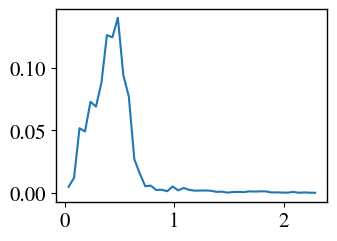

In [12]:
sc = 'sc1bd4'
path_temp='/gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/cocoa_photoz/'
nzsf = f'{path_temp}roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5'
nzs = h5py.File(nzsf,'r')
zbins = np.array(nzs['zbinsc'])
Nsim=0
arr = nzs[f'bin0'][0, :]
plt.plot(zbins,arr)

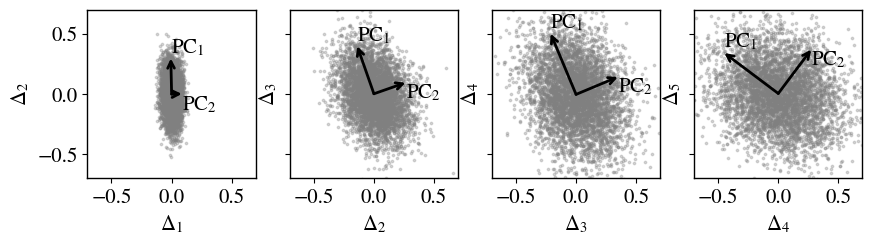

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

pairs = [(0,1),(1,2),(2,3),(3,4)]
# fig, ax = plt.subplots(figsize=(5,5))
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(10, 10),
                       sharex=True, sharey=True,
                       gridspec_kw={'wspace':0.2, 'hspace':0.0})

sc_temp='sc1bd4'
C_full = np.loadtxt(f"./cocoa_photoz/roman_nz_realizations/{sc_temp}/Cn_{sc_temp}.txt")
for k,ij in enumerate(pairs):
    i=ij[0]
    j=ij[1]
    C = C_full[np.ix_([i,j],[i,j])]
    mean = np.zeros(C.shape[0])
    samples = np.random.multivariate_normal(mean, C, size=5000)

    x = samples[:, 0]
    y = samples[:, 1]

    eigvals, eigvecs = np.linalg.eigh(C)  # ascending eigenvalues

    # top two PCs
    pc1 = eigvecs[:, -1]
    pc2 = eigvecs[:, -2]

    mu_2d = np.mean(samples[:, :2], axis=0)

    scale1 = 2.0 * np.sqrt(eigvals[-1])
    scale2 = 2.0 * np.sqrt(eigvals[-2])

    # line endpoints (center +/- scale * direction)
    pc1_pos = mu_2d + scale1 * pc1
    pc1_neg = mu_2d - scale1 * pc1
    pc2_pos = mu_2d + scale2 * pc2
    pc2_neg = mu_2d - scale2 * pc2

    pc1_line = np.vstack([pc1_neg, pc1_pos])
    pc2_line = np.vstack([pc2_neg, pc2_pos])

    ax[k].scatter(x, y, s=3, alpha=0.3, color='gray')
    # ax.plot(pc1_line[:,0], pc1_line[:,1], linewidth=2, color='red', label=r"$\mathrm{PC}_1$")
    # ax.plot(pc2_line[:,0], pc2_line[:,1], linewidth=2, color='purple', label=r"$\mathrm{PC}_2$")

    # Arrows exactly from mean to positive endpoint
    arr1 = FancyArrowPatch(posA=mu_2d, posB=pc1_pos,
                        arrowstyle='->', linewidth=2, color='black',
                        mutation_scale=12, shrinkA=0.0, shrinkB=0.0)

    arr2 = FancyArrowPatch(posA=mu_2d, posB=pc2_neg,
                        arrowstyle='->', linewidth=2, color='black',
                        mutation_scale=12, shrinkA=0.0, shrinkB=0.0)

    ax[k].add_patch(arr1)
    ax[k].add_patch(arr2)

    # Optional: label slightly beyond arrow tip
    ax[k].text(pc1_pos[0]*1.01, pc1_pos[1]*1.01, r'$\mathrm{PC}_1$', color='black', ha='left', va='bottom')
    ax[k].text(pc2_neg[0]*1.01, pc2_neg[1]*1.01, r'$\mathrm{PC}_2$', color='black', ha='left', va='top')

    # ax.legend(loc='best', fontsize=10)
    ax[k].set_xlim(-.7, .7)
    ax[k].set_ylim(-.7, .7)
    ax[k].set_xlabel(fr"$\Delta_{{{i+1}}}$")
    ax[k].set_ylabel(fr"$\Delta_{{{j+1}}}$")
    ax[k].set_aspect('equal', 'box')   # keep aspect ratio equal
# plt.savefig('pc_exaple.pdf')

# Survey class and methods

In [13]:
class SURVEY:
    def __init__(self,survey,use_r=None):
        self.survey = survey
        self.use_r = use_r

    # Global parameters
    def nz_params(self):
        if self.survey == 'des':
            Nz = 299 #len(z)
            Nt = 4
        elif self.survey == 'roman':   
            Nz = 46 #len(z)
            Nt = 9
        return Nz,Nt

    # Auxiliary functions
    def get_nzs(self):
        Nz,Nt = self.nz_params()
        if self.survey == 'des':
            nz = f'{path}/roman_nz_realizations/Fisher_matrix/Tz_realizations_WZ_bq_pile3_0d01.npy' # shared by Boyan Yin
            nz = np.load(nz)             ## shape = (10095, 4, 300) = (Ns, Nt, Nz) = (# of simulations, # of tomo bins, # of redshift)
            nz = nz[:,:,1:]              ## shape = (10095, 4, 299) | (first :) => all 10095 simulations, (second :) => all 4 tomo bins, (third ,1:) => all redshift bins except the first where nz is 0.0.
            Ns = np.shape(nz)[0]         ## Number of simulations: 10095
            nz = nz.reshape(Ns, Nt * Nz) ## shape = (10095, 1196) = (Ns, Nt*Nz)
            min_z   = 0.01
            max_z   = 3
            delta_z = (max_z - min_z) / Nz
            zbins   = np.arange(min_z,max_z+delta_z,delta_z)
            z  = zbins[:-1]+(zbins[1]-zbins[0])/2.
            return z, nz

        elif self.survey == 'roman':
            sc = 'sc1bd4'
            nz = h5py.File(f'{path}/roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5','r') # shared by Boyan Yin
            z = np.array(nz['zbinsc'])
            return z, nz

    def roman_nbar(self):    
        nbar = f'{path}/n_nbar_ndiff_covndiff/nbar_sc1b_d4.nz'
        return nbar

    def cov_of_ndiff(self):
        Nz,Nt = self.nz_params()
        z,nz = self.get_nzs()

        if self.survey == 'roman':
            # Never use r=10^6 on login node.
            if self.use_r != None and self.use_r>0:
                #np.random.seed(42)
                #sims_indexes = np.random.randint(1, 10**6 + 1, size=self.use_r)
                # tot = len(sims_indexes)
                sims_indexes = list(range(self.use_r))

                rows = []
                print(f"Total # of realizations r = {self.use_r}\nNormalizing nz for r:")
                for jj, j in enumerate(sims_indexes):
                    row = []
                    for i in range(Nt):
                        norm = np.trapz(y=nz[f'bin{i}'][j], x=z)
                        normalized = nz[f'bin{i}'][j] / norm
                        row.append(normalized)
                    #row shape after appending all bins: (Nt,Nz)
                    print(jj, end=' ')
                    rows.append(np.hstack(row))
                #rows shape after appending all realizations: (tot,Nt*Nz)
                nz = np.vstack(rows) # (tot,Nt*Nz)
                nbar = np.mean(nz,axis=0)
                ndiff = nz - nbar
                Cn = np.einsum('ij,ik->jk',ndiff,ndiff) / (ndiff.shape[0]-1) # equivalent to Cn = ndiff.T @ ndiff / sample size - 1
            else:
                # Use Cn from all 10^6
                Cn = np.load(f'{path}/n_nbar_ndiff_covndiff/cov_ndiff_sc1b_d4.npy') #TODO: path changed    
                ndiff = None # Because we can't load (414,1M) data here
        elif self.survey == 'des':
            ### nzs for DES already are normalized
            ### set parameter below to True if you want to check
            check_des_nz_normalization = False
            if check_des_nz_normalization:
                rows = []
                for j in range(10095):
                    row = []
                    for i in range(Nt):
                        start, end = Nz*i, Nz*(i+1)
                        norm = np.trapz(y=nz[j,start:end], x=z)
                        normalized = nz[j,start:end] / norm
                        row.append(normalized)
                    rows.append(np.hstack(row))
                nz = np.vstack(rows)

            nbar = np.mean(nz,axis=0)
            ndiff = nz - nbar
            Cn = np.einsum('ij,ik->jk',ndiff,ndiff) / (ndiff.shape[0]-1) # equivalent to Cn = ndiff.T @ ndiff / sample size - 1
        self.Cn = Cn
        self.ndiff = ndiff    
        return self.Cn, self.ndiff
    
    # Unweighted PCA    
    def pcs(self,method='eig'):
        Nz,Nt = self.nz_params()
        Nd = Nz*Nt
        if method == 'eig':
            eig_vals, eig_vecs = np.linalg.eig(self.Cn)
            eigvals, eigvecs = np.linalg.eig(self.Cn)
        elif method == 'eigh':
            eigvals, eigvecs = np.linalg.eigh(self.Cn)
        elif method == 'svd':    
            U, S, VT = np.linalg.svd(self.Cn)
            eigvecs, eigvals = U,S
        elif method == 'sklearn':
            pca = PCA()
            pca.fit(self.Cn)
            eigvecs, eigvals = pca.components_, pca.singular_values_
            explained_variance = pca.explained_variance_
            explained_variance_ratio = pca.explained_variance_ratio_
        ######
        if method != 'sklearn':
            eigvals = np.real(eigvals)
            eigvecs = np.real(eigvecs)
            idx     = np.argsort(eigvals)[::-1] # 1. Get indices to sort eigenvalues in descending order
            eigvals = eigvals[idx]              # 2. Sort eigenvalues (largest to smallest)
            eigvals = np.maximum(0,eigvals)     # 3. Clamp any small negative eigenvalues to 0 (often due to numerical errors)
            eigvecs = eigvecs[:, idx]           # 4. Reorder columns of eigenvectors to match sorted eigenvalues
            return eigvecs, eigvals
        elif method == 'sklearn':
            return eigvecs.T, eigvals, explained_variance,explained_variance_ratio
    
    def forward_pca(self, params_values,nbar_path,pcs_path,npcs_nz):
        nbar = np.genfromtxt(nbar_path)
        U = np.genfromtxt(pcs_path)[:,:npcs_nz]
        s = nbar[:,1:].shape
        z = nbar[:,0]
        # Model: n(z) = <n>(z) + α_1*PC_1(z) + α_2*PC_2(z) + ... + α_n*PC_n(z)
        if npcs_nz > 0:
            alphas = np.array([params_values.get("roman_alpha_"+str(i+1)) for i in range(npcs_nz)])
            correction = (alphas * U).sum(axis=1)
    
            nz_model = nbar[:,1:].T.flatten() + correction
            nz_model = nz_model.reshape(s[::-1]).T
            nz_model = np.column_stack((z,nz_model))
            return nz_model
        else:
            return nbar

    # Credit: Gary M. Bernstein
    def nearestPD(self,A):
        """Find the nearest positive-definite matrix to input
        A Python/Numpy port of John D'Errico's `nearestSPD` MATLAB code [1], which
        credits [2].
        [1] https://www.mathworks.com/matlabcentral/fileexchange/42885-nearestspd
        [2] N.J. Higham, "Computing a nearest symmetric positive semidefinite
        matrix" (1988): https://doi.org/10.1016/0024-3795(88)90223-6
        """
        B = (A + A.T) / 2
        _, s, V = np.linalg.svd(B)
        H = np.dot(V.T, np.dot(np.diag(s), V))
        A2 = (B + H) / 2
        A3 = (A2 + A2.T) / 2
        if self.isPD(A3):
            return A3
        spacing = np.spacing(np.linalg.norm(A))
        I = np.eye(A.shape[0])
        k = 1
        while not self.isPD(A3):
            mineig = np.min(np.real(np.linalg.eigvals(A3)))
            A3 += I * (-mineig * k**2 + spacing)
            k += 1
        return A3

    def isPD(self,B):
        """Returns true when input is positive-definite, via Cholesky"""
        try:
            _ = np.linalg.cholesky(B)
            return True
        except np.linalg.LinAlgError:
            return False              
    
    def getModes(self,D, Cn, chisq_threshold=0):
        '''Calculate the compression matrix from n to u and the
        modes U that multiply each U.  
        Parameters:
        `D`:      The matrix J^T C_c^{-1} J, where C_c is the covariance
                matrix of the observables c, and J is the Jacobian dc/dn,
                shape=(N,N)
        `Cn`:     Covariance matrix of the n(z) parameter vector n, shape=(N,N)
        `chisq_threshold`:  Your desired upper bound for the mean error in chisq
                resulting from the compression.
        Returns:
        `X`:      The compression matrix, u = X @ n, shape=(nModes,N).  The
                covariance matrix of the u's will be the identity.
        `U`:      The decoding matrix, n' = U @ u, shape=(N,nModes)
        `dchisq`: The mean chisq shift generated by each mode, shape=(nModes)
        `resid`:  Mean amount of chisq shift caused by compression.

        You can safely use fewer than `nModes` of the returned X and U if you 
        think the discarded `dchisq` values are small enough.'''

        thr = 1e-25     # Dynamic range threshold for eigenvalues

        # Symmetrize and sqrt D
        D = 0.5*(D + D.T)
        Dval, Dvec = np.linalg.eigh(D)
        # Any negatives are numerical problems
        Dval = np.maximum(0., Dval)

        # And Cn
        Cnval, Cnvec = np.linalg.eigh(Cn)
        Cnval = np.maximum(0., Cnval)

        # Build the keystone matrix and its SVD
        M = np.einsum('i,ji,jk,k->ik',np.sqrt(Cnval), Cnvec, Dvec, np.sqrt(Dval))
        Um,s,Vmt = np.linalg.svd(M)

        # Sort SV's and throw away unwanted ones
        order = np.argsort(s*s)  # increasing order
        kill = np.count_nonzero(np.cumsum(s[order]**2) < chisq_threshold)
                                            
        resid = np.sum((s[order[:kill]]**2))

        keep = np.flip(order[kill:])  # Decreasing influence order
        Um = Um[:,keep]
        Vm = Vmt.T[:,keep]
        s = s[keep]

        # Build the encoder
        tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)
        X = np.einsum('ij,i,ki->jk',Um, tmp, Cnvec)  # X is (M,N)
        # And the decoder
        tmp = np.where(Dval>thr*np.max(Dval), 1/np.sqrt(Dval), 0.)
        U = np.einsum('ji,i,ik,k->jk',Dvec, tmp, Vm,s) # Vm s
        
        return X, U, s*s, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M
    
    ###############################
    ############ CoCoA ############
    ###############################
    

# Redsfhit distribution & lensing efficiency kernel   
Equation 15 of arXiv:2105.13543  
$
W(z) =\frac{3H_0^2\Omega_m}{2c^2}\frac{\chi}{a(\chi)} \left[\int_\chi^{\chi_H} n(\chi')\frac{d\chi'}{dz}dz - \chi\int_\chi^{\chi_H}\frac{n(\chi')}{\chi'}\frac{d\chi'}{dz}dz\right] = \frac{3H_0^2\Omega_m}{2c^2}\frac{\chi}{a(\chi)} \left[W_1(\chi) - \chi W_2(\chi)\right]
$

/tmp/ipykernel_1742943/3532597994.py:31: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Wi_1 = lambda z: quad(int_Wi_1_interp, z, z_tab[-1])[0]
/tmp/ipykernel_1742943/3532597994.py:32: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges. 

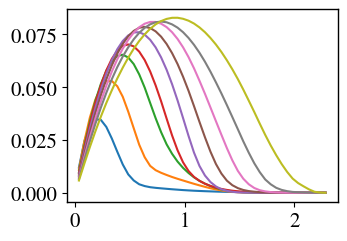

In [35]:
import camb.constants
from scipy.interpolate import interp1d
from scipy.integrate import quad

pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
results = camb.get_background(pars)
nbar = np.loadtxt("cocoa_photoz/roman_nz_realizations/sc1bd4/nbar_sc1bd4.nz")

z_tab = nbar[:,0]
const_factor = 3 * 0.5 * pars.H0**2 * pars.omegam / (camb.constants.c*1e-3)**2

# for t in [1,2,3,4,5,6,7,8,9]:

def Wi(z_tab,nzi_tab):
    """
    z_tab: tabulated redshifts
    nzi_tab: tabulated redshift distribution at bin i
    """
    chi = results.comoving_radial_distance(z_tab)

    dchidz = np.gradient(chi,z_tab)

    int_Wi_1 = nzi_tab * dchidz
    int_Wi_2 = nzi_tab * dchidz / chi
    int_Wi_1_interp = interp1d(z_tab, int_Wi_1)
    int_Wi_2_interp = interp1d(z_tab, int_Wi_2)
    pre_fac = chi*(1+z_tab)
    pre_fac_interp = interp1d(z_tab, pre_fac, kind='cubic', bounds_error=False, fill_value='extrapolate')

    Wi_1 = lambda z: quad(int_Wi_1_interp, z, z_tab[-1])[0]
    Wi_2 = lambda z: quad(int_Wi_2_interp, z, z_tab[-1])[0]
    Wi_temp = lambda z: const_factor*pre_fac_interp(z)*(Wi_1(z) - results.comoving_radial_distance(z)*Wi_2(z))
    return np.array([Wi_temp(zi) for zi in z_tab],dtype=np.float64)

for i in range(1,10):
    plt.plot(z_tab,Wi(z_tab,nbar[:,i]))


(1, 46, 9)
(46,)
0

/tmp/ipykernel_1742943/3532597994.py:31: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Wi_1 = lambda z: quad(int_Wi_1_interp, z, z_tab[-1])[0]
/tmp/ipykernel_1742943/3532597994.py:32: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges. 

12345678

/tmp/ipykernel_1742943/56819664.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


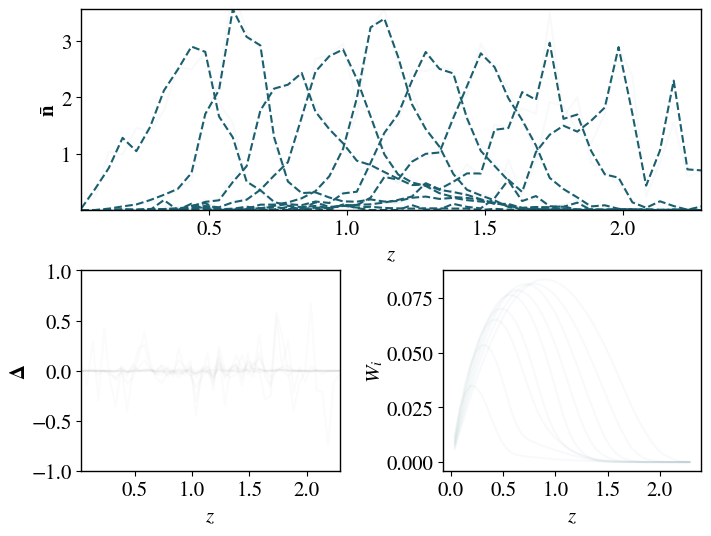

In [68]:
sc = 'sc1bd4'
nz = h5py.File(f'{cocoa_path}/cocoa_photoz/roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5','r')
nz_mean = np.genfromtxt(f'{cocoa_path}/cocoa_photoz/roman_nz_realizations/{sc}/nbar_sc1bd4.nz')
z  = np.array(nz['zbinsc'])
Nt = 9
Nz = 46
nz_tomos=[]
Nsim = 1
for r in range(Nsim):
    nz_tomos.append([np.column_stack(nz[f'bin{i}'][r]/np.trapz(y=nz[f'bin{i}'][r],x=z))[0] for i in range(9)])

nz_tomos=np.array(nz_tomos) # shape (Nsim,Nt,Nz)
nz_tomos=np.transpose(nz_tomos, (0, 2, 1)) # shape (Nsim,Nz,Nt)
print(nz_tomos.shape)
print(nz_tomos[0,:,0].shape)

# plt.figure()
# fig = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=False,figsize=(8,3),
#                         gridspec_kw={'wspace':0.2, 'hspace':0.0,'height_ratios': [2, 1]})

fig = plt.figure(figsize=(8, 6))

gs = fig.add_gridspec(2, 2, wspace=0.4, hspace=0.3)

# Left column: two separate subplots
axes1 = fig.add_subplot(gs[0, :])  # top-left
axes2 = fig.add_subplot(gs[1, 0])  # bottom-left
axes3 = fig.add_subplot(gs[1, 1])  # all rows, column 1

for t in range(Nt):
    print(t,end='')
    for s in range(Nsim):
        axes1.plot(z,nz_tomos[s,:,t],c='#1b5f6f',alpha=.03)
        axes3.plot(z,Wi(z,nz_tomos[s,:,t]),c='#1b5f6f',alpha=.03)

for i in range(9): 
    axes1.plot(z,nz_mean[:,i+1],c='#1b5f6f',ls='--')

for r in range(Nsim):
    for i in range(9):
        axes2.plot(z,nz_tomos[r,:,i]-nz_mean[:,i+1],c='gray',alpha=.03)


axes1.set_ylabel(r'$\bar{\mathbf{n}}$', labelpad=1)
axes2.set_ylabel(r'${\mathbf{\Delta}}$', labelpad=1)
axes3.set_ylabel(r'$W_i$', labelpad=1)
axes1.set_xlabel(r'$z$')
axes2.set_xlabel(r'$z$')
axes3.set_xlabel(r'$z$')
axes1.set_yticks([1,2,3]);
axes1.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0]);
axes2.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0]);
axes3.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0]);
axes1.set_xlim(np.min(z),np.max(z));
axes2.set_xlim(np.min(z),np.max(z));
axes2.set_xlim(np.min(z),np.max(z));
axes1.set_ylim(0,np.max(nz_mean))
axes2.set_ylim(-1,+1)
axes2.set_yticks([-1,-0.5, 0,0.5,1])
# fig.align_ylabels(axes1)
# axes[1,0].grid(False)
plt.tight_layout()
plt.savefig('redshift_delta_sc1bd4_v2.pdf');

['0.428 &', '0.682 &', '0.908 &', '0.996 &', '1.147 &', '1.298 &', '1.464 &', '1.636 &', '1.902 &']
['0.429 &', '0.683 &', '0.908 &', '0.996 &', '1.147 &', '1.299 &', '1.464 &', '1.643 &', '1.913 &']
['0.432 &', '0.682 &', '0.905 &', '0.995 &', '1.154 &', '1.302 &', '1.466 &', '1.644 &', '1.884 &']
['0.427 &', '0.687 &', '0.909 &', '0.996 &', '1.148 &', '1.299 &', '1.462 &', '1.625 &', '1.837 &']


Text(0.5, 0, '$z$')

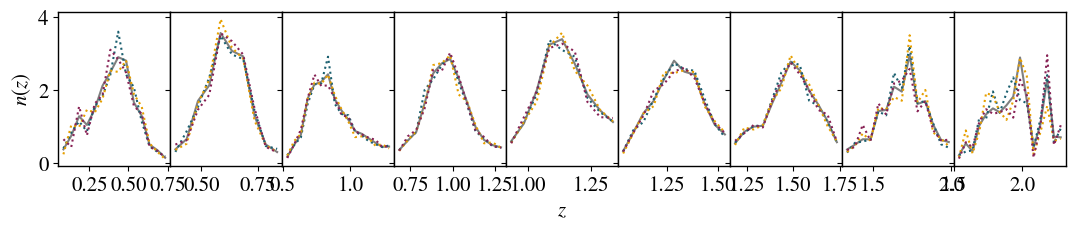

In [276]:
# Plotting the mean nz, for: the least extreme (r=3233), intermediate (r=0) and most extreme (r=869) scenarios
mean_bar = np.genfromtxt(f"{cocoa_path}/projects/roman_real/data/sc1bd4/nbar_sc1bd4.nz")
least_extreme_nz = np.genfromtxt(f"{cocoa_path}/projects/roman_real/data/sc1bd4/nz_fid_sc1bd4r3233.nz")
intermediate_nz = np.genfromtxt(f"{cocoa_path}/projects/roman_real/data/sc1bd4/nz_fid_sc1bd4r0.nz")
most_extreme_nz = np.genfromtxt(f"{cocoa_path}/projects/roman_real/data/sc1bd4/nz_fid_sc1bd4r869.nz")

all_nzs = [mean_bar,least_extreme_nz,intermediate_nz,most_extreme_nz]

def mean_distr(nz_distr):
    z = nz_distr[:,0]
    nz_tomos = nz_distr[:,1:]
    mean_distr_per_tomo = [np.trapz(y=z*nz_tomos[:,i],x=z)/np.trapz(y=nz_tomos[:,i],x=z) for i in range(9)]
    # print(mean_distr_per_tomo)
    print(["{:.3f} &".format(x) for x in mean_distr_per_tomo])
    return None
for r in all_nzs:
    mean_distr(r)

fig, ax = plt.subplots(nrows=1, ncols=9, sharex=False, sharey=True,figsize=(13, 2),
                        gridspec_kw={'wspace':0, 'hspace':0})

# By these plots we can NOT infer anything.
z=mean_bar[:,0]
ij = [(1,15),(7,17),(10,26),(13,26),(18,27),(20,31),(23,35),(26,40),(30,46)]
for ijs,tomo in list(zip(ij,range(1,10))):
    i = ijs[0]
    j = ijs[1]
    ax[tomo-1].plot(z[i:j],mean_bar[i:j,tomo],color='gray',ls='-')
    ax[tomo-1].plot(z[i:j],least_extreme_nz[i:j,tomo],color='#1b5f6f',ls=':')
    ax[tomo-1].plot(z[i:j],intermediate_nz[i:j,tomo],color='#E69F00',ls=':')
    ax[tomo-1].plot(z[i:j],most_extreme_nz[i:j,tomo],color='#882255',ls=':')
ax[0].set_ylabel(r"$n(z)$")
ax[4].set_xlabel(r"$z$")

/tmp/ipykernel_180324/885608958.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


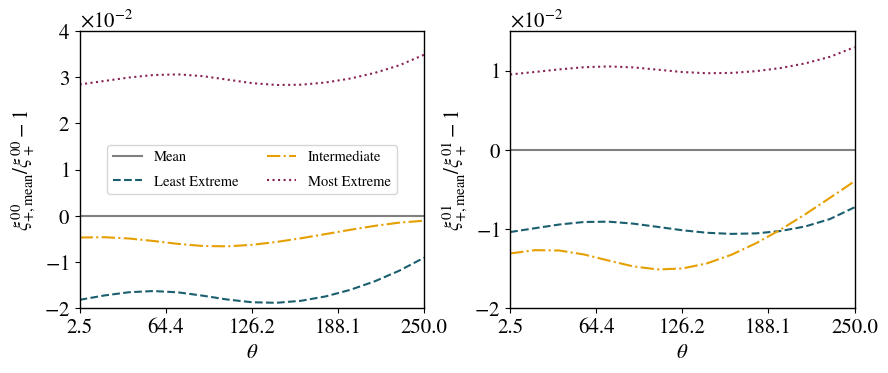

In [ ]:
# Plotting the xi_+-, for: the least extreme (r=3233), intermediate (r=0) and most extreme (r=869) scenarios

mean_xi = np.genfromtxt(f"{cocoa_path}/projects/roman_real/data/sc1bd4/Model_sc1bd4_Fiducial_sc1bd4_nbar.modelvector",usecols=(1))
least_extreme_xi = np.genfromtxt(f"{cocoa_path}/projects/roman_real/data/sc1bd4/Model_sc1bd4_Fiducial_sc1bd4r3233.modelvector",usecols=(1))
intermediate_xi = np.genfromtxt(f"{cocoa_path}/projects/roman_real/data/sc1bd4/Model_sc1bd4_Fiducial_sc1bd4r0.modelvector",usecols=(1))
most_extreme_xi = np.genfromtxt(f"{cocoa_path}/projects/roman_real/data/sc1bd4/Model_sc1bd4_Fiducial_sc1bd4r869.modelvector",usecols=(1))
theta = np.linspace(2.5,250,15)

# fig, ax = plt.subplots(figsize=(4.6, 3))
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False,figsize=(10, 3.6),
                        gridspec_kw={'wspace':0.25, 'hspace':0})

k = 0
for k in [0,1]:
    ax[k].plot(theta,mean_xi[15*k:15*(k+1)]/mean_xi[15*k:15*(k+1)]-1,color="gray",label='Mean')
    ax[k].plot(theta,mean_xi[15*k:15*(k+1)]/least_extreme_xi[15*k:15*(k+1)]-1,color="#1b5f6f",label='Least Extreme',ls='--')
    ax[k].plot(theta,mean_xi[15*k:15*(k+1)]/intermediate_xi[15*k:15*(k+1)]-1,color="#E69F00",label='Intermediate',ls='-.')
    ax[k].plot(theta,mean_xi[15*k:15*(k+1)]/most_extreme_xi[15*k:15*(k+1)]-1,color="#882255",label='Most Extreme',ls=':')
ax[0].set_xlabel(r"$\theta$")
ax[1].set_xlabel(r"$\theta$")
ax[0].set_ylabel(r"$\xi_{+,\mathrm{mean}}^{00} / \xi_+^{00}-1$")
ax[1].set_ylabel(r"$\xi_{+,\mathrm{mean}}^{01} / \xi_+^{01}-1$")
ax[0].legend(
    ncol=2,
    fontsize=10.5,
    loc='center',
    # bbox_to_anchor=(0.578, 0.65),
    bbox_transform=plt.gcf().transFigure  # anchor to figure instead of axes
)
ax[0].set_xticks([2.5 ,  64.375,  126.25,  188.125,  250])
ax[1].set_xticks([2.5 ,  64.375,  126.25,  188.125,  250])
ax[0].set_xlim(2.5,250)
ax[1].set_xlim(2.5,250)
ax[0].set_ylim(-0.02,0.04)
ax[1].set_ylim(-0.02,0.015)

import matplotlib.ticker as mtick
for a in ax:
    a.yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
    a.ticklabel_format(axis='y', style='sci', scilimits=(-2,2))

plt.tight_layout()
# plt.savefig("least_intermediate_most_extreme_xi.pdf")

# Unweighted PCA

## Roman case  

### Test 1 - Fix one PC (e.g. PC_1) and plot its slices across the tomographic bins:  
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The principal components are the same, except for a possible sign flip.  
$\text{PC}^1 = \Big[[\text{PC}^1_{1},\text{PC}^1_{2},\cdots,\text{PC}^1_{46}],[\text{PC}^1_{47},\text{PC}^1_{48},\cdots,\text{PC}^1_{92}],6\times[\cdots],[\text{PC}^1_{412},\text{PC}^1_{413},\cdots,\text{PC}^1_{414}]\Big]$

In [4]:
roman_obj = SURVEY('roman',use_r=None)
Nz,Nt = roman_obj.nz_params()
z,nz = roman_obj.get_nzs()
nbar_file = roman_obj.roman_nbar()

Cn, ndiff = roman_obj.cov_of_ndiff() # must call before pcs

eig_vecs, eig_vals = roman_obj.pcs('eig')
eih_vecs, eih_vals = roman_obj.pcs('eigh')
svd_vecs, svd_vals = roman_obj.pcs('svd')
# np.savetxt('U.txt',eih_vecs) # Jul 18 using on MCMC

skl_vecs, skl_vals,\
explained_variance, explained_variance_ratio = roman_obj.pcs('sklearn')

/tmp/ipykernel_291877/3046020584.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right',borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

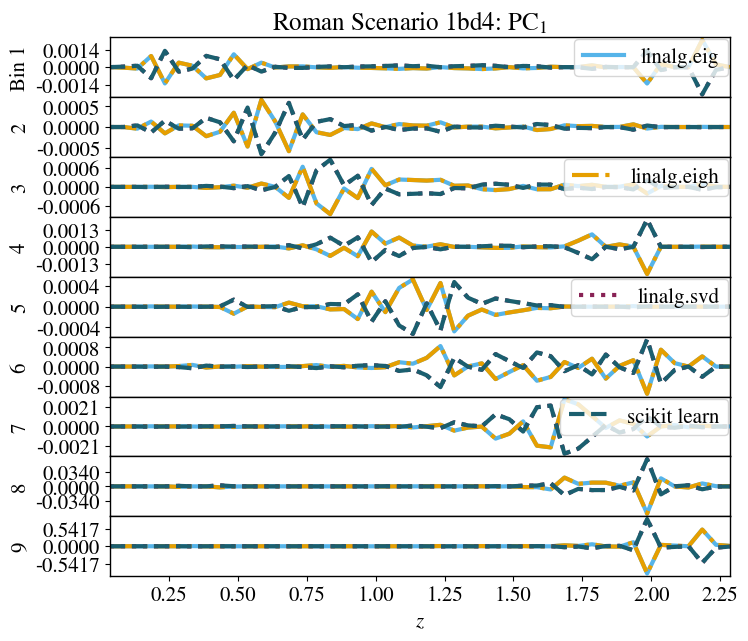

In [75]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0

colors=['#56B4E9',"#E69F00","#882255","#1b5f6f"]

for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2.5
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    ax.plot(z, eig_vecs[start:end, pci],c=colors[0],lw=3, ls='-' , label='linalg.eig' if k==0 else None)
    ax.plot(z, eih_vecs[start:end, pci],c=colors[1],lw=3, ls='-.', label='linalg.eigh' if k==2 else None)
    ax.plot(z, svd_vecs[start:end, pci],c=colors[2],lw=3, ls=':', label='linalg.svd' if k==4 else None)
    ax.plot(z, skl_vecs[start:end, pci],c=colors[3],lw=3, ls='--' , label='scikit learn' if k==6 else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

unused_legs = [1,3,5,7,8]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario 1bd4: PC$_{{{pci+1}}}$", y=0.92);

### Test 2 - Pick up the first three PCs and plot their slices across the tomographic bins

/tmp/ipykernel_291877/3356386639.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

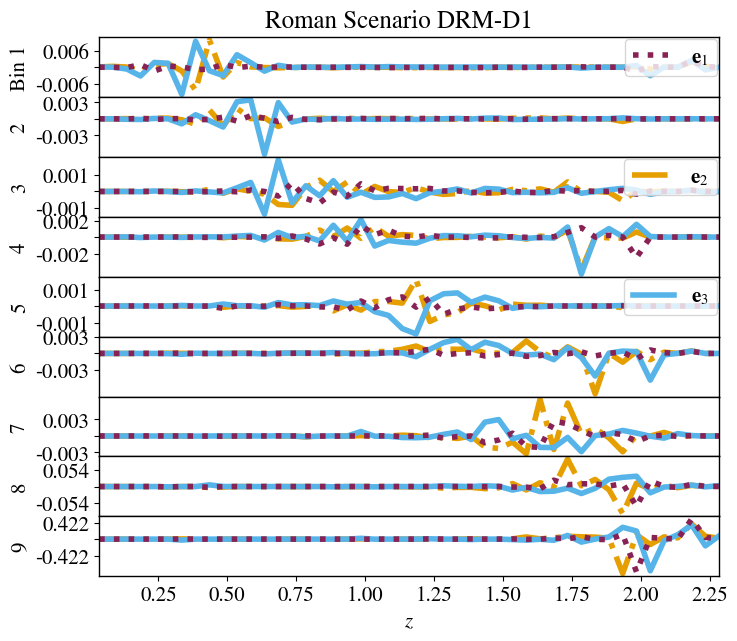

In [77]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})

pcis = [0,1,2]

colors=['#882255',"#E69F00","#56B4E9","#1b5f6f"]

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
formatter.set_scientific(True)
tick_label_formatter = FuncFormatter(lambda y, _: f"{y:.0f}") 

for k, ax in enumerate(axes):  # k = tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    e1 = eig_vecs[start:end, pcis[0]]
    e2 = eig_vecs[start:end, pcis[1]]
    e3 = eig_vecs[start:end, pcis[2]]

    max_y = np.max([np.max(e1), np.max(e2), np.max(e3)])
    min_y = np.min([np.min(e1), np.min(e2), np.min(e3)])
    d_y = (max_y - min_y) / 3.3
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_visible(k == 0)

    def format_ticks(y, _):
        if np.isclose(y, 0.0):
            return ''
        else:
            return f'{y:.3f}'
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))

    ks = [0, 2, 4]
    ax.plot(z, e2, c=colors[1], lw=4, ls='-.', label=r'$\mathbf{e}$'+rf'$_{{{pcis[1]+1}}}$' if k==ks[1] else None)
    ax.plot(z, e3, c=colors[2], lw=4, ls='-', label=r'$\mathbf{e}$'+rf'$_{{{pcis[2]+1}}}$' if k==ks[2] else None)
    ax.plot(z, e1, c=colors[0], lw=4, ls=':', label=r'$\mathbf{e}$'+rf'$_{{{pcis[0]+1}}}$' if k==ks[0] else None)

    ax.set_ylabel(f'Bin {k+1}' if k == 0 else f'{k+1}')
    ax.legend(loc='upper right', borderaxespad=.1)

unused_legs = [x for x in range(9) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario DRM-D1", y=0.92);
# plt.savefig("PCs123_DRMD1_unweighted.pdf")

### Test 3 - Plot the eigenvalues
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The eigenvalues/singular values are the same.

Text(0.5, 0.98, 'Roman Scenario 1bd4')

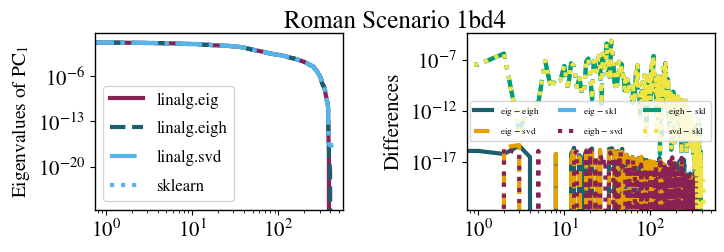

In [9]:
Ms = list(range(Nz*Nt))
colors=["#882255","#1b5f6f",'#56B4E9',"#56B4E9"]
fig, axes = plt.subplots(1, 2, figsize=(8, 2.3), sharex=True,gridspec_kw={'wspace':.5, 'hspace':1.0})

axes[0].plot(Ms,eig_vals ,c=colors[0],lw=3, ls='-' ,label='linalg.eig')
axes[0].plot(Ms,eih_vals,c=colors[1],lw=3, ls='--',label='linalg.eigh')
axes[0].plot(Ms,svd_vals ,c=colors[2],lw=3, ls='-.',label='linalg.svd')
axes[0].plot(Ms,skl_vals ,c=colors[3],lw=3, ls=':' ,label='sklearn')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_ylabel(rf'Eigenvalues of PC$_1$',fontsize=14)
axes[0].legend(loc='best',fontsize=12)

axes[1].loglog(Ms,eig_vals-eih_vals,c=colors1[0],lw=3, ls='-' ,label=r'eig $-$ eigh')
axes[1].loglog(Ms,eig_vals-svd_vals, c=colors1[1],lw=3, ls='--',label=r'eig $-$ svd')
axes[1].loglog(Ms,eig_vals-skl_vals, c=colors1[2],lw=3, ls='-.',label=r'eig $-$ skl')

axes[1].loglog(Ms,eih_vals-svd_vals,c=colors1[3],lw=3, ls=':' ,label=r'eigh $-$ svd')
axes[1].loglog(Ms,eih_vals-skl_vals,c=colors1[4],lw=3, ls='-.',label=r'eigh $-$ skl')

axes[1].loglog(Ms,svd_vals-skl_vals, c=colors1[5],lw=3, ls=':',label=r'svd $-$ skl')
axes[1].legend(loc='center',fontsize=6.6,ncol=3)
axes[1].set_ylabel(rf'Differences')
fig.suptitle('Roman Scenario 1bd4')

### Test 4 - Comparing methods to get the PCs: `pcs` vs `getModes`  
The method `pcs` compute the PCs with the standard unweighted PCA. The method `getModes` compute the PCs weighted by the Fisher matrix (see 2506.00758).  
However, if we force $F=I$, then both methods possoes the same eigenvalue, while the eigenvector differ by a factor $\Lambda_n^{1/2}P_M$. Here we show how:  
1. The eigenvalues are the same:  
In Eq. 15 of 2506.00758, if $F=I$, then $G = \Lambda_n = V_G\Lambda_G V_G^T$. However, $\Lambda_n=\text{diag}[\lambda_1^n,\cdots,\lambda_N^n]$ thus $\Lambda_G=\Lambda_n$ and $V_G = I$.
2. The eigenvectors differ by a scaling factor of $\Lambda_n^{1/2}$:  
The decoding matrix (eq 19/20 in 2506.00758) is $D = V_n^T\Lambda_n^{1/2}V_GP_M$. We have $V_G = I$, then $D = V_n^T\Lambda_n^{1/2}P_M$. In particular, if $M=N$, then $P_M = I$ and $D = V_n^T\Lambda_n^{1/2}$.

In [10]:
D = np.identity(Cn.shape[0])

if not roman_obj.isPD(D):
    print('fixing cov')
    D=roman_obj.nearestPD(D)

X, U, ss, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M = roman_obj.getModes(D,Cn,chisq_threshold=0);

/tmp/ipykernel_1881659/924595602.py:225: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)


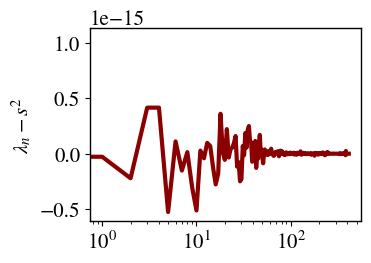

In [11]:
plt.plot(range(len(eig_vals)), eig_vals-ss,ls='-',c='darkred',lw=3)
plt.xscale('log')
plt.ylabel(r'$\lambda_n-s^2$');

/tmp/ipykernel_1881659/1062677139.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right',borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

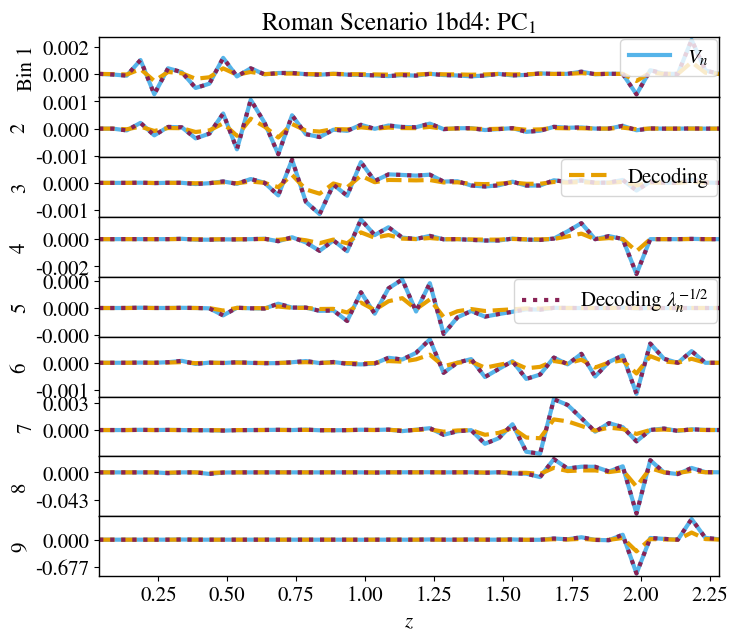

In [12]:
idx = np.argsort(Cnval)[::-1]
decoding_matrix  = Cnvec[:,idx] @ np.diag(Cnval[idx]) # Eq 19/20 in 2506.00758 when M = N and Fisher = Identity
decoding_matrix2 = Cnvec[:,idx] # @ np.diag(Cnval[idx])

plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0
ks = [0,2,4]
for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    ax.plot(z, eih_vecs[start:end, pci],c='#56B4E9',lw=3, ls='-' , label=r'$V_n$' if k==ks[0] else None)
    ax.plot(z, decoding_matrix[start:end, pci],c='#E69F00',lw=3, ls='--', label='Decoding' if k==ks[1] else None)
    ax.plot(z, decoding_matrix2[start:end, pci],c='#882255',lw=3, ls=':', label=r'Decoding $\lambda_n^{-1/2}$' if k==ks[2] else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

unused_legs = [x for x in range(Nt) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario 1bd4: PC$_{{{pci+1}}}$", y=0.92);

### Test 5 - sanity check 1: $\lim_{\# \text{PC}\rightarrow\max{\# \text{PC}}} \hat{n}(z)\rightarrow n_\text{fid}(z)$  
The projection of the difference matrix, $\mathbf{\Delta}=\mathbf{n}-\bar{\mathbf{n}}$, onto the PC basis is $\alpha_i\equiv\langle\mathbf{\Delta},\mathbf{PC}_i\rangle$. Therefore, any realization of the redshift distribution $n^r(z)$ can be approximate by $n^r(z)\approx\hat{n}^r(z) \equiv \bar{n}(z)+\sum_{i=1}^{M\leq N}\alpha_i^r\mathbf{PC}_i(z)$ where $\alpha_i^r$ is the projection of the realization $\mathbf{\Delta}^r$ onto the PC basis, i.e. $\alpha_i^r\equiv\langle\mathbf{\Delta}^r,\mathbf{PC}_i\rangle$ or it can be seem as the $r$ th element of the sample $\alpha_i\equiv\langle\mathbf{\Delta},\mathbf{PC}_i\rangle$. The approximation becomes perfect, i.e. $\hat{n}^r(z)=n^r(z)~\forall~z$, when $M=N$, or if we tolerate a threshold $|\hat{n}^r(z)-n^r(z)|<\epsilon~\forall~z$ .

/tmp/ipykernel_1881659/2951064648.py:44: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(z[1:],n[1:]/nhat[1:]-1,color=color,ls='-')


<Figure size 350x250 with 0 Axes>

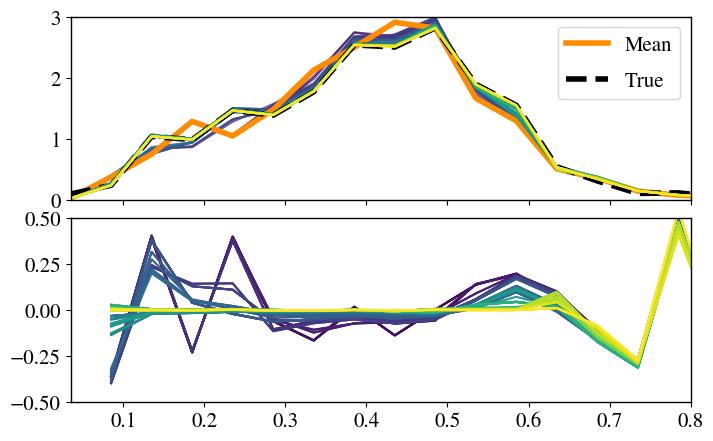

In [13]:
plt.figure()

params_values = {}
nbar_path = '/gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/projects/roman_real/data/sc1bd4/nbar_sc1bd4.nz'
pcs_path = '/gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/projects/roman_real/data/sc1bd4/U.txt'

n2 = np.genfromtxt('/gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/projects/roman_real/data/sc1bd4/nz_sc1bd4r0.nz')
nbar = np.genfromtxt(nbar_file)[:,1]
nbar2 = np.genfromtxt(nbar_path)[:,1]
norm_nbar = np.trapz(y=nbar,x=z)

nbar /= norm_nbar
n = nz['bin0'][0]
norm_n = np.trapz(y=n,x=z)
n /= norm_n

ndiff = n - nbar

fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, sharey=False,figsize=(8, 5),
                        gridspec_kw={'wspace':0.0, 'hspace':0.1})

values_for_coloring = []
for i in range(100):
    values_for_coloring.append(i) # Assign a value for coloring each curve

cmap = plt.cm.viridis # You can choose other colormaps like 'plasma', 'inferno', 'magma', 'cividis', 'hot', etc.
norm = plt.Normalize(vmin=min(values_for_coloring), vmax=max(values_for_coloring))

npcs = list(range(100))#[0,1,2,3,4,5,10,15,20,25,30,35,40,50,60,100]

for ii, npc in enumerate(npcs):
    nhat = np.zeros(46)
    for i in range(npc):
        alpi = np.dot(ndiff,eih_vecs[:46,i]) #eih_vals
        # print(f'      roman_alpha_{i+1}: {alpi}')
        params_values.update({f"roman_alpha_{i+1}": alpi})
        nhat += alpi*eih_vecs[:46,i]

    nhat = nbar + nhat

    nhat2 = roman_obj.forward_pca(params_values=params_values,nbar_path=nbar_path,pcs_path=pcs_path,npcs_nz=npc)
    color = cmap(norm(values_for_coloring[ii]))    
    axes[0].plot(z,nhat,color=color,ls='-',alpha=.5)
    axes[1].plot(z[1:],n[1:]/nhat[1:]-1,color=color,ls='-')
    if npc==40:
        axes[0].plot(z,nbar,'darkorange',label='Mean',lw=4)
        axes[0].plot(z,n,'k',label='True',lw=4,ls='--')

axes[0].set_xlim(np.min(z),.8);
axes[0].set_ylim(0,3);
axes[1].set_xlim(np.min(z),.8);
lim = .5
axes[1].set_ylim(-lim,+lim);
axes[0].legend(loc='best')

### Test 6 - sanity check 2: $\lim_{\# \text{PC}\rightarrow\max{\# \text{PC}}} \chi^2[\hat{n}(z)]\rightarrow 0$  
The likelihood is given by $L\propto\exp \left[-\frac{1}{2}\left(\mathbf{D}-\mathbf{M}\right)^\mathrm{T}\mathbf{C}^{-1}\left(\mathbf{D}-\mathbf{M}\right)\right]$ where $\mathbf{D}$ is the (observational or synthetic) data vector, $\mathbf{M}$ is the theoretical vector, and $\mathbf{C}$ is the covariance matrix.

In [14]:
# Load the yaml as Python dict
info_txt = f'{path}/yamls/roman_pca/modelvector_generator.yaml'
with open(info_txt) as f:
    info = yaml_load(f)

# # # Adjust the paths for theory and likelihood codes
del info["theory"]["camb"]["path"]
del info["output"]
info["likelihood"]["roman_real.roman_real_cosmic_shear"]["path"] = f'{cocoa_path}/external_modules/data/roman_real/sc1bd4'
info["packages_path"] = camb_path

In [15]:
# Get the model in interactive mode using Cobaya `model` wrapper
model = get_model(info)


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.
[model] *WARNING* Ignored blocks/options: ['sampler']
[camb] `camb` module loaded successfully from /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb
[roman_real.roman_real_cosmic_shear] use_baryon_pca = False


#### Test 6.a - Simple Cobaya example:  
Cobaya `model` evaluation for Roman cosmic shear at fiducial cosmological parameters.

In [16]:
###########################################################
# [ref] https://cobaya.readthedocs.io/en/latest/models.html
###########################################################

random_point = model.prior.sample(ignore_external=True)[0] # `0` is the name of the combination of 1D priors specified in the `params` block see Note 2 of [ref]
sampled_params_names = model.parameterization.sampled_params()
random_point_dict = dict(zip(sampled_params_names,random_point))
print("Our random point is:", random_point_dict)
print("The log-priors are:", model.logpriors(random_point_dict,as_dict=True))
print(
    "The log-likelihoods and derived parameters are:",
    model.loglikes(random_point_dict,as_dict=True))
print("The log-posterior is:", model.logpost(random_point_dict))
print("")
print("All the previous information at once!",model.logposterior(random_point_dict, as_dict=True))

Our random point is: {'As_1e9': 2.5913397965973646, 'ns': 0.8748640006223969, 'H0': 65.33621784972095, 'omegab': 0.054991663916037666, 'omegam': 0.5860771393005624, 'roman_alpha_1': 0.0015097881991648768, 'roman_alpha_2': 0.6209009941062165, 'roman_alpha_3': -0.9652555763514276, 'roman_alpha_4': -0.9622833095777844, 'roman_alpha_5': 0.24691736605981207, 'roman_alpha_6': -3.001103077854955, 'roman_alpha_7': 0.004978933942769665, 'roman_alpha_8': 0.757485842769853, 'roman_alpha_9': 0.43373617394066705, 'roman_alpha_10': 0.22008369307907638, 'roman_DZ_S1': 0.005732385395974095, 'roman_DZ_S2': -0.0021835282143455458, 'roman_DZ_S3': -0.009590680379297488, 'roman_DZ_S4': 0.00532370688924899, 'roman_DZ_S5': -0.0030233754972163887, 'roman_DZ_S6': 0.002698756765024117, 'roman_DZ_S7': 0.002119064540635866, 'roman_DZ_S8': -0.0007098227226921743, 'roman_DZ_S9': -0.0007382647332548191, 'roman_M1': -0.00026009544370091424, 'roman_M2': -0.002952809558184362, 'roman_M3': -0.007542915950490764, 'roman_

In [17]:
# Note 1 of [ref]
print("The posterior is evaluated only at *sampled* parameters!")
print("List of sampled parameters:",list(sampled_params_names))

The posterior is evaluated only at *sampled* parameters!
List of sampled parameters: ['As_1e9', 'ns', 'H0', 'omegab', 'omegam', 'roman_alpha_1', 'roman_alpha_2', 'roman_alpha_3', 'roman_alpha_4', 'roman_alpha_5', 'roman_alpha_6', 'roman_alpha_7', 'roman_alpha_8', 'roman_alpha_9', 'roman_alpha_10', 'roman_DZ_S1', 'roman_DZ_S2', 'roman_DZ_S3', 'roman_DZ_S4', 'roman_DZ_S5', 'roman_DZ_S6', 'roman_DZ_S7', 'roman_DZ_S8', 'roman_DZ_S9', 'roman_M1', 'roman_M2', 'roman_M3', 'roman_M4', 'roman_M5', 'roman_M6', 'roman_M7', 'roman_M8', 'roman_M9', 'roman_A1_1', 'roman_A1_2']


In [12]:
# # Note 5 of [ref]
# os.environ["OMP_PROC_BIND"] = "close"
# os.environ["OMP_NUM_THREADS"] = "8"
# model.dump_timing()

In [18]:
point = random_point_dict # Parameters values are no longer random. We choose a specific point by overriding them.
point.update(info["sampler"]["evaluate"]["override"]) 
logposterior = model.logposterior(point, as_dict=True)
print(logposterior,end='')

{'logpost': 59.55615234610001, 'logpriors': {'0': 72.8307672936117}, 'loglikes': {'roman_real.roman_real_cosmic_shear': -13.274614947511687}, 'derived': {'As': 2.1e-09, 'wa': 0.0, 'omegabh2': 0.018127929599999995, 'omegach2': 0.11718640399491413, 'omegal': 0.6999208591093972, 'omegamh2': 0.13595947199999994, 'sigma8': 0.8276996582848258, 's8h5': 1.0087898926052372, 's8omegamp5': 0.4533497736819168, 's8omegamp25': 0.6125662843807401, 'age': 13.997581616960147, 'rdrag': 152.88038492684717, 'yheused': 0.2438239352852982, 'omegan2': 0.000644866570625114, 'omegan': 0.001422923819441828}}

#### Test 6.b - Cobaya `model` evaluation vs 50 of PCs: $n(z)=\bar{n}(z)+\sum_{i=1}^{50}\alpha_ie_i$

In [6]:
npcs_tot=414
npcs_used=5
params_values={}

nbar_path = f'{cocoa_path}/projects/roman_real/data/sc1bd4/nbar_sc1bd4.nz'
pcs_path = f'{cocoa_path}/projects/roman_real/data/sc1bd4/U.txt'
nr0_path = f'{cocoa_path}/projects/roman_real/data/sc1bd4/nz_sc1bd4r0.nz'

nbar = np.genfromtxt(nbar_path)
nr0 = np.genfromtxt(nr0_path)
z = nr0[:,0]

ndiff = nr0[:,1:] - nbar[:,1:] # (46,9)

In [ ]:
# To example_weighted.yaml
for i in range(npcs_tot):
    template = f"""  roman_alpha_{i+1}:
    prior:
      dist: norm
      loc: 0.0
      scale: 1.0
    ref:
      dist: norm
      loc: 0.0
      scale: 1.0
    proposal: 1.0
    latex: \\alpha_{{{i+1}}}"""
    print(template)

  roman_alpha_1:
    prior:
      dist: norm
      loc: 0.0
      scale: 1.0
    ref:
      dist: norm
      loc: 0.0
      scale: 1.0
    proposal: 1.0
    latex: \alpha_{1}
  roman_alpha_2:
    prior:
      dist: norm
      loc: 0.0
      scale: 1.0
    ref:
      dist: norm
      loc: 0.0
      scale: 1.0
    proposal: 1.0
    latex: \alpha_{2}
  roman_alpha_3:
    prior:
      dist: norm
      loc: 0.0
      scale: 1.0
    ref:
      dist: norm
      loc: 0.0
      scale: 1.0
    proposal: 1.0
    latex: \alpha_{3}
  roman_alpha_4:
    prior:
      dist: norm
      loc: 0.0
      scale: 1.0
    ref:
      dist: norm
      loc: 0.0
      scale: 1.0
    proposal: 1.0
    latex: \alpha_{4}
  roman_alpha_5:
    prior:
      dist: norm
      loc: 0.0
      scale: 1.0
    ref:
      dist: norm
      loc: 0.0
      scale: 1.0
    proposal: 1.0
    latex: \alpha_{5}
  roman_alpha_6:
    prior:
      dist: norm
      loc: 0.0
      scale: 1.0
    ref:
      dist: norm
      loc: 0.0
      s

In [8]:
# To roman_real_params_source.yaml
for i in range(npcs_tot):
    template=f"""  roman_alpha_{i+1}:
    value: 0.0
    latex: \\alpha_{{{i+1}}}"""
    print(template)

  roman_alpha_1:
    value: 0.0
    latex: \alpha_{1}
  roman_alpha_2:
    value: 0.0
    latex: \alpha_{2}
  roman_alpha_3:
    value: 0.0
    latex: \alpha_{3}
  roman_alpha_4:
    value: 0.0
    latex: \alpha_{4}
  roman_alpha_5:
    value: 0.0
    latex: \alpha_{5}
  roman_alpha_6:
    value: 0.0
    latex: \alpha_{6}
  roman_alpha_7:
    value: 0.0
    latex: \alpha_{7}
  roman_alpha_8:
    value: 0.0
    latex: \alpha_{8}
  roman_alpha_9:
    value: 0.0
    latex: \alpha_{9}
  roman_alpha_10:
    value: 0.0
    latex: \alpha_{10}
  roman_alpha_11:
    value: 0.0
    latex: \alpha_{11}
  roman_alpha_12:
    value: 0.0
    latex: \alpha_{12}
  roman_alpha_13:
    value: 0.0
    latex: \alpha_{13}
  roman_alpha_14:
    value: 0.0
    latex: \alpha_{14}
  roman_alpha_15:
    value: 0.0
    latex: \alpha_{15}
  roman_alpha_16:
    value: 0.0
    latex: \alpha_{16}
  roman_alpha_17:
    value: 0.0
    latex: \alpha_{17}
  roman_alpha_18:
    value: 0.0
    latex: \alpha_{18}
  roman_al

In [7]:
# Components from projection. 
# To examples_weighted.yaml
for i in range(npcs_tot):
    alpi = np.dot(ndiff.T.flatten(),eih_vecs[:,i])
    print(f'      roman_alpha_{i+1}: {alpi}')
    params_values.update({f"roman_alpha_{i+1}": alpi})

      roman_alpha_1: -0.3279481143061275
      roman_alpha_2: 0.19529961405513133
      roman_alpha_3: -0.8377603234551243
      roman_alpha_4: 0.2757960192752586
      roman_alpha_5: 0.2133957250349448
      roman_alpha_6: 0.3159448890181971
      roman_alpha_7: -0.10774912279486318
      roman_alpha_8: 0.2214639831873735
      roman_alpha_9: 0.1086536868373383
      roman_alpha_10: -0.21116600829831994
      roman_alpha_11: 0.7135801936439325
      roman_alpha_12: -0.27262937286164496
      roman_alpha_13: 0.5457018527765328
      roman_alpha_14: 0.37746101002354565
      roman_alpha_15: -0.4687798150833383
      roman_alpha_16: 0.11803375881704567
      roman_alpha_17: 0.10813364730150057
      roman_alpha_18: -0.2978251391657273
      roman_alpha_19: 0.19540327239344132
      roman_alpha_20: 0.1740008604510842
      roman_alpha_21: 0.2872521697867583
      roman_alpha_22: -0.12623393695666352
      roman_alpha_23: -0.20422565128711165
      roman_alpha_24: -0.4782238294510371
     

In [20]:
# Load the yaml as Python dict
# del info_txt, info, point
info_txt = f'{path}/yamls/roman_pca/example_unweighted.yaml'
with open(info_txt) as f:
    info = yaml_load(f)

# Adjust the paths for theory (camb) and likelihood (roman) codes
del info["theory"]["camb"]["path"]
info["packages_path"] = camb_path
info["likelihood"]["roman_real.roman_real_cosmic_shear"]["path"] = f'{cocoa_path}/external_modules/data/roman_real/sc1bd4'

loglikes = []

for i in range(npcs_used):
    info["likelihood"]["roman_real.roman_real_cosmic_shear"]["npcs_nz"] = i
    info["likelihood"]["roman_real.roman_real_cosmic_shear"]["print_datavector_file"] = \
          f"./datavector_vs_npcs/dv_sc1bd4r0_fidP18_{i}pc.modelvector"
    print(f"# of PCs: {info['likelihood']['roman_real.roman_real_cosmic_shear']['npcs_nz']}\n",end='')
    model = get_model(info)
    varied_points = {} # The yaml "example_unweighted.yaml" do not contain any varied parameter! 
    loglikes_i = model.loglikes(varied_points,as_dict=False,return_derived=False)[0]
    print(f"χ²: {-2*loglikes_i}")
    loglikes.append(loglikes_i)

# of PCs: 0
[model] *WARNING* Ignored blocks/options: ['output', 'sampler']
[camb] `camb` module loaded successfully from /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb
[roman_real.roman_real_cosmic_shear] use_baryon_pca = False
χ²: 11.353485431721635
# of PCs: 1
[model] *WARNING* Ignored blocks/options: ['output', 'sampler']
[camb] `camb` module loaded successfully from /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb
[roman_real.roman_real_cosmic_shear] use_baryon_pca = False
χ²: 11.21666717477266
# of PCs: 2
[model] *WARNING* Ignored blocks/options: ['output', 'sampler']
[camb] `camb` module loaded successfully from /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb
[roman_real.roman_real_cosmic_shear] use_baryon_pca = False
χ²: 11.303893829632525
# of PCs: 3
[model] *WARNING* Ignored blocks/options: ['output', 'sampler']
[camb] `camb` module loaded successfully from 

In [24]:
for i,chi2 in enumerate(-2*np.array(loglikes)):
    print(i,chi2)

0 11.353485431721634
1 11.216667174772661
2 11.303893829632527
3 13.882375226347357
4 13.569309356652466
5 13.496793485173624
6 13.536204654091504
7 12.107801268492095
8 12.112488458706224
9 11.527141830667556
10 11.694488829846316
11 8.183184988583731
12 8.748103367581678
13 10.156407766455429
14 8.827537970805107
15 9.002001031114483
16 8.005899985865735
17 8.109296060746512
18 8.140263111212823
19 7.565003607197699
20 7.370732397972386
21 6.594434652730695
22 7.178937266488255
23 7.011178376447497
24 6.665779269015397
25 6.752601079574598
26 6.7298274246889545
27 6.710822294580563
28 4.609743776770738
29 4.793574548978274
30 5.059196355338512
31 8.788085316566184
32 27.915280723858487
33 29.74188152637426
34 27.532874046474518
35 26.403582301090644
36 18.345186308090348
37 21.069173094811724
38 20.328505132631324
39 23.12498601229666
40 17.69553804587285
41 6.728653635959337
42 5.070373270523783
43 5.026613409522764
44 5.178748564485901
45 5.156894608549453
46 5.5593614361550445
47 

In [25]:
# chi2_{k} = sum_i[n^{k}(z_i) - nbar(z_i)]^2
nzr0 = np.zeros((Nz,Nt))
for i in range(Nt):
    nzr0[:,i] = nz[f'bin{i}'][0]/np.trapz(y=nz[f'bin{i}'][0],x=z)
    
nbar = np.genfromtxt(nbar_path)[:,1:]
chi2_total=[]
chi2_per_bin=[]
for npc in range(npcs_used):
    nhat = roman_obj.forward_pca(params_values=params_values,nbar_path=nbar_path,pcs_path=pcs_path,npcs_nz=npc)[:,1:]
    chi2_total.append(np.sum((nhat - nzr0)**2))
    chi2_per_bin.append(np.sum((nhat-nzr0)**2,axis=0))
print(list(zip(range(npcs_used),chi2_total)),end='')
x = np.array(chi2_per_bin)

[(0, 4.593608792879852), (1, 4.486058827202909), (2, 4.447916887952824), (3, 3.74607452839719), (4, 3.6700110841491123), (5, 3.624473348685921), (6, 3.5246521757891998), (7, 3.5130423023261383), (8, 3.463996006476921), (9, 3.4521903828135745), (10, 3.4075992997529303), (11, 2.8984026069920166), (12, 2.824075832045083), (13, 2.526285319921342), (14, 2.3838085058333474), (15, 2.164053990803778), (16, 2.1501220225832975), (17, 2.138429136904572), (18, 2.0497293233854874), (19, 2.011546884523422), (20, 1.9812705850857049), (21, 1.898756776038504), (22, 1.8828217691989253), (23, 1.84111365255528), (24, 1.6124156215004657), (25, 1.6045241231826992), (26, 1.6043000610944678), (27, 1.6040246139988734), (28, 1.4802139755249641), (29, 1.4488739368270744), (30, 1.405986111221233), (31, 1.123559413661916), (32, 0.8807943643864907), (33, 0.8068621629528495), (34, 0.7666747091434255), (35, 0.7548675752939303), (36, 0.6991179497110374), (37, 0.6171734962291444), (38, 0.5936202637811657), (39, 0.57841

log(likes):    [-5.676742715860817, -5.608333587386331, -5.651946914816263, -6.941187613173678, -6.784654678326233, -6.748396742586812, -6.768102327045752, -6.053900634246047, -6.056244229353112, -5.763570915333778, -5.847244414923158, -4.091592494291866, -4.374051683790839, -5.078203883227714, -4.4137689854025535, -4.501000515557242, -4.002949992932868, -4.054648030373256, -4.0701315556064115, -3.7825018035988496, -3.685366198986193, -3.2972173263653475, -3.5894686332441275, -3.5055891882237487, -3.3328896345076986, -3.376300539787299, -3.3649137123444772, -3.3554111472902814, -2.304871888385369, -2.396787274489137, -2.529598177669256, -4.394042658283092, -13.957640361929244, -14.87094076318713, -13.766437023237259, -13.201791150545322, -9.172593154045174, -10.534586547405862, -10.164252566315662, -11.56249300614833, -8.847769022936426, -3.3643268179796686, -2.5351866352618915, -2.513306704761382, -2.5893742822429506, -2.5784473042747265, -2.7796807180775223, -2.813084899602833, -2.89

/tmp/ipykernel_1881659/4033824645.py:47: RuntimeWarning: invalid value encountered in divide
  axes[1,0].plot(z,nzr0/nbar-1)
/tmp/ipykernel_1881659/4033824645.py:50: RuntimeWarning: invalid value encountered in divide
  axes[1,1].plot(z,nzr0/nhat[:,1:]-1);


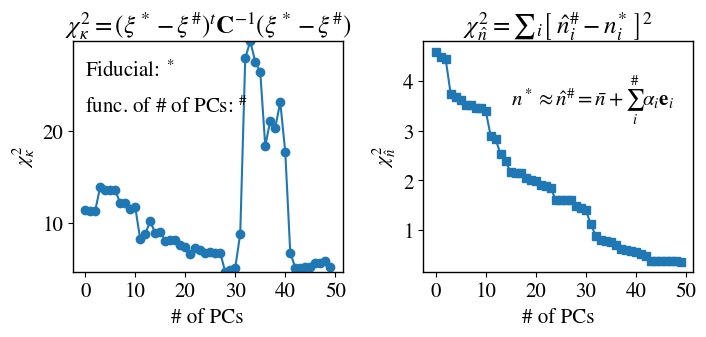

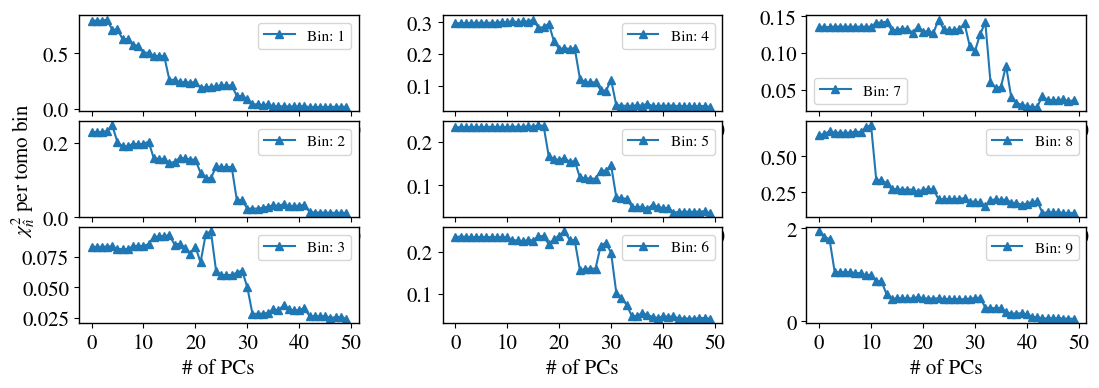

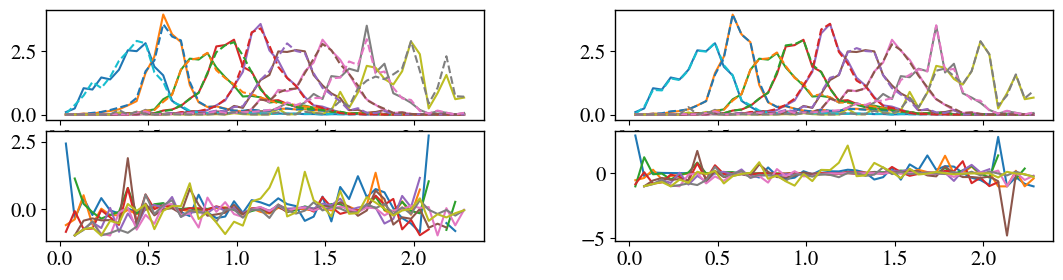

In [26]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False,figsize=(8, 3),
                        gridspec_kw={'wspace':0.3, 'hspace':0.1})

skip = 10

chi2_roman_cosmic_shear = -2*np.array(loglikes)
print('log(likes):   ',loglikes)
print('-2xlog(likes):',list(chi2_roman_cosmic_shear))

print(np.max(chi2_roman_cosmic_shear),list(chi2_roman_cosmic_shear).index(np.max(chi2_roman_cosmic_shear)))

axes[0].plot(list(range(len(loglikes))),chi2_roman_cosmic_shear,marker='o')
axes[0].set_xticks(range(0,npcs_used + 1, skip));
axes[0].set_ylim(np.min(chi2_roman_cosmic_shear)-.02,np.max(chi2_roman_cosmic_shear)+.02)
axes[0].set_xlabel('# of PCs')
axes[0].set_ylabel(r'$\chi^2_{\kappa}$');
axes[0].set_title(r'$\chi^2_{\kappa} = (\xi^*-\xi^\#)^t\mathbf{C}^{-1}(\xi^*-\xi^\#)$');
axes[0].annotate(r'Fiducial: ${}^*$',xy=(0,26));
axes[0].annotate(r'func. of # of PCs: ${}^\#$',xy=(0,22));

axes[1].plot(list(range(len(loglikes))),chi2_total,marker='s')
axes[1].set_xticks(range(0,npcs_used + 1, skip));
axes[1].set_xlabel('# of PCs')
axes[1].set_ylabel(r'$\chi^2_\hat{n}$');
axes[1].set_title(r'$\chi^2_\hat{n} = \sum{}_i\left[~\hat{n}_i^\#-n_i^{*}~\right]^2$');
axes[1].annotate(r'$n^*\approx\hat{n}^\#=\bar{n}+\sum_i^\#\alpha_i\mathbf{e}_i$',xy=(15,3.5));

fig, axes = plt.subplots(nrows=3, ncols=3, sharex=False, sharey=False,figsize=(13, 4),
                        gridspec_kw={'wspace':0.3, 'hspace':0.1})


rows_cols = [(row,col) for col in range(3) for row in range(3)]
for i,(row,col) in enumerate(rows_cols):
    axes[row,col].plot(list(range(len(loglikes))),x[:,i],label=f'Bin: {i+1}',marker='^')
    axes[row,col].set_xticks(range(0,npcs_used + 1, skip));
    axes[row,col].legend(loc='best',fontsize=11,ncols=3)
axes[2,0].set_xlabel('# of PCs')
axes[2,1].set_xlabel('# of PCs')
axes[2,2].set_xlabel('# of PCs')
axes[1,0].set_ylabel(r'$\chi^2_\hat{n}$ per tomo bin');

fig, axes = plt.subplots(nrows=2, ncols=2, sharex=False, sharey=False,figsize=(13, 3),
                        gridspec_kw={'wspace':0.3, 'hspace':0.1})
nhat = roman_obj.forward_pca(params_values=params_values,nbar_path=nbar_path,pcs_path=pcs_path,npcs_nz=33)
axes[0,0].plot(z,nzr0)
axes[0,0].plot(z,nbar,ls='--')
axes[1,0].plot(z,nzr0/nbar-1)
axes[0,1].plot(z,nzr0)
axes[0,1].plot(z,nhat[:,1:],ls='--')
axes[1,1].plot(z,nzr0/nhat[:,1:]-1);

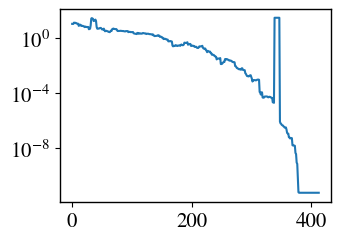

In [21]:
chis2 = np.genfromtxt(f"{cocoa_path}/datavector_vs_npcs/chi2_vs_npcs.txt",usecols=(1))
plt.plot(range(len(chis2)),chis2)
plt.yscale("log")

#### Test 6.c - Cobaya `model` evaluation for full PCs: $n(z)=\bar{n}(z)+\sum_{i=1}^{414}\alpha_ie_i$

In [27]:
npcs_tot=Nt*Nz
params_values={}

nbar_path = f'{cocoa_path}/projects/roman_real/data/sc1bd4/nbar_sc1bd4.nz'
pcs_path = f'{cocoa_path}/projects/roman_real/data/sc1bd4/U.txt'
nr0_path = f'{cocoa_path}/projects/roman_real/data/sc1bd4/nz_sc1bd4r0.nz'

nbar = np.genfromtxt(nbar_path)
nr0 = np.genfromtxt(nr0_path)
z = nr0[:,0]
ndiff = nr0[:,1:].T.flatten() - nbar[:,1:].T.flatten()
# ndiff2 = nr0[:,1:] - nbar[:,1:]

In [28]:
for i in range(npcs_tot):
    alpi = np.dot(ndiff,eih_vecs[:,i]) #eih_vals
    # print(f'      roman_alpha_{i+1}: {alpi}')
    params_values.update({f"roman_alpha_{i+1}": alpi})

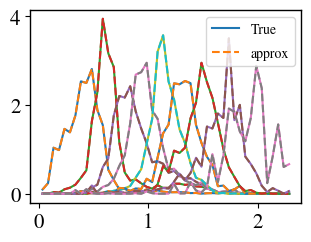

In [29]:
nhat = roman_obj.forward_pca(params_values=params_values,nbar_path=nbar_path,pcs_path=pcs_path,npcs_nz=npcs_tot)

for i in range(1,10):
    plt.plot(z,nr0[:,i],ls='-',label='True' if i==1 else '')
    plt.plot(z,nhat[:,i],ls='--',label='approx' if i==1 else '')
plt.legend(loc='best',fontsize=10)

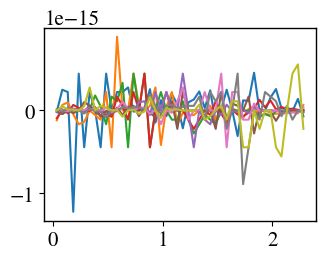

In [30]:
for i in range(1,10):
    plt.plot(z,nr0[:,i]-nhat[:,i])

### Test 7 - Simulations sc1bd4 that differ the most significantly from the average $\bar{n}$

#### Test 7.a - Plot the realizations from sc1bd4 that differ the most significantly from the averate $\bar{n}$

In [31]:
bigd = np.genfromtxt(f"{path}/codes/biggest_norms2_final.txt",dtype=int) # biggest norm2 or biggest distance
print(f'total {bigd[0]}, per tomo bin {bigd[1:]}')

total 997946, per tomo bin [870731 174820 991213 645431 131103 808898 682038 472580  92550]


Text(0, 0.5, '$n(z)$')

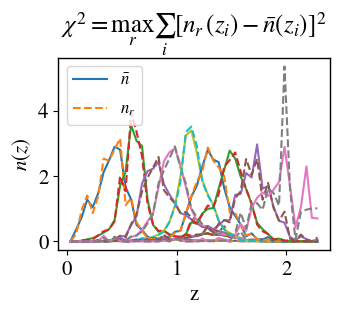

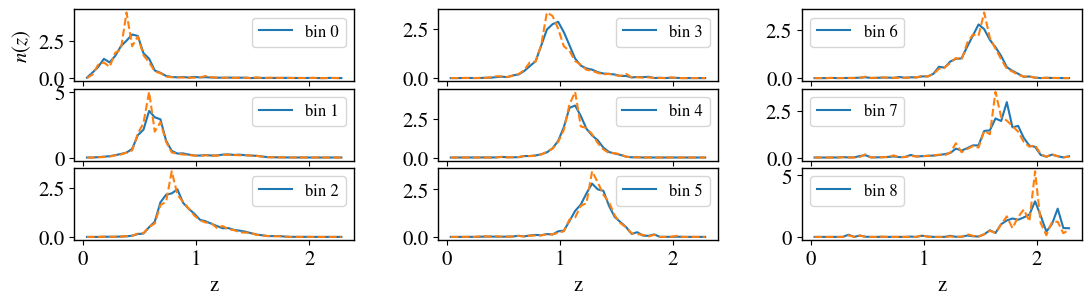

In [32]:
for i in range(9):
    plt.plot(z,nbar[:,i+1], label=r'$\bar{n}$' if i ==0 else '')
    plt.plot(z,nz[f'bin{i}'][bigd[0]]/np.trapz(nz[f'bin{i}'][bigd[0]],z),ls='--',label=r'$n_r$' if i ==0 else '')
plt.title(r'$\chi^2=\max_r\sum_i[n_r(z_i)-\bar{n}(z_i)]^2$')
plt.xlabel(r'z')
plt.ylabel(r'$n(z)$')
plt.legend(loc='upper left',fontsize=12)

rows_cols = [(row, col) for col in range(3) for row in range(3)]
fig, axes = plt.subplots(nrows=3, ncols=3, sharex=True, sharey=False,figsize=(13, 3),
                        gridspec_kw={'wspace':0.3, 'hspace':0.1})
for i,row_col in enumerate(rows_cols):
    row,col=row_col[0],row_col[1]
    axes[row,col].plot(z,nbar[:,i+1],label=f'bin {i}')
    axes[row,col].plot(z,nz[f'bin{i}'][bigd[i+1]]/np.trapz(nz[f'bin{i}'][bigd[i+1]],z),ls='--')
    axes[row,col].legend(loc='best',fontsize=12)
[axes[2,col].set_xlabel('z') for col in range(3)]
axes[0,0].set_ylabel(r'$n(z)$')

#### Generates and save the following files to run the MCMCs:  
(1) - .nz  
(2) - .dataset   
(3) - .mask  
(4) - .modelvector  
(5) - .yaml

In [32]:
## Saves the fiducial .nz
for k in bigd:
    nz_bigdk=[]
    print(k,'',end='')
    for i in range(Nt):
        nz_bigdk.append(nz[f'bin{i}'][k]/np.trapz(y=nz[f'bin{i}'][k],x=z))
    nz_bigdk.insert(0,z)
    nz_bigdk = np.array(nz_bigdk).T
    np.savetxt(f'{cocoa_path}/projects/roman_real/data/sc1bd4/nz_sc1bd4r{k}.nz',nz_bigdk)

## Saves the .datasets using the fiducial .nz for each realizations r = 997946, 870731, 174820, 991213, 645431, 131103, 808898, 682038, 472580, 92550 
path_sc1bd4 = f'{cocoa_path}/projects/roman_real/data/sc1bd4'
template = f'{path_sc1bd4}/sc1bd4.dataset'
for k in bigd:
    with open(template,'r') as f:
        lines = f.readlines()
    new_lines = []
    with open(f'{path_sc1bd4}/sc1bd4_r{k}_fidRR.dataset','w') as g:
        for line in lines:
            if line.strip().startswith('data_file'):
                new_line = f'data_file = sc1bd4_r{k}_fidRR.modelvector\n'
                g.writelines(new_line)
            elif line.strip().startswith('mask_file'):    
                new_line = f'mask_file = mask_sc1bd4r{k}.mask\n'
                g.writelines(new_line)
            elif line.strip().startswith('nz_lens_file'):    
                new_line = f'nz_lens_file = nz_sc1bd4r{k}.nz\n'
                g.writelines(new_line)
            elif line.strip().startswith('nz_source_file'):    
                new_line = f'nz_source_file = nz_sc1bd4r{k}.nz\n'
                g.writelines(new_line)
            else:
                g.writelines(line)

## Saves the .dataset using nbar and .modelvector(nz_fid) 
path_sc1bd4 = f'{cocoa_path}/projects/roman_real/data/sc1bd4'
template = f'{path_sc1bd4}/sc1bd4.dataset'
for k in bigd:
    with open(template,'r') as f:
        lines = f.readlines()
    new_lines = []
    with open(f'{path_sc1bd4}/sc1bd4_nbar_r{k}_fidRR.dataset','w') as g:
        for line in lines:
            if line.strip().startswith('data_file'):
                new_line = f'data_file = sc1bd4_r{k}_fidRR.modelvector\n'
                g.writelines(new_line)
            elif line.strip().startswith('mask_file'):    
                new_line = f'mask_file = mask_sc1bd4r{k}.mask\n'
                g.writelines(new_line)
            elif line.strip().startswith('nz_lens_file'):    
                new_line = f'nz_lens_file = nbar_sc1bd4.nz\n'
                g.writelines(new_line)
            elif line.strip().startswith('nz_source_file'):    
                new_line = f'nz_source_file = nbar_sc1bd4.nz\n'
                g.writelines(new_line)
            else:
                g.writelines(line)

997946 870731 174820 991213 645431 131103 808898 682038 472580 92550 

In [74]:
## Generate the .mask file into a file
import importlib
import calculate_mask_generator as cmg
importlib.reload(cmg)
cmg.scs=list(bigd)
cmg.main()

------------------------
0 997946
------------------------
zavg: [0.4217722722845398, 0.6844206409297392, 0.9185036043832613, 1.0061050837648071, 1.1494380448661814, 1.2984838082519359, 1.4636146060360558, 1.6417353105843202, 1.9095967322093845] (9,)
theta: [  2.97200132   4.04000899   5.49181204   7.4653298   10.14804377
  13.79480815  18.75206062  25.49073345  34.65099142  47.10304664
  64.02982748  87.03935519 118.31750374 160.83565486 218.63297531
   0.        ] (16,)
ang_cut(zavg[j]): 6.438877021833909
ang_cut(zavg[j]): 5.04359136782969
ang_cut(zavg[j]): 4.557795271304776
ang_cut(zavg[j]): 4.453064303895888
ang_cut(zavg[j]): 4.335566724391394
ang_cut(zavg[j]): 4.263462912670062
ang_cut(zavg[j]): 4.224427957255905
ang_cut(zavg[j]): 4.215864835572157
ang_cut(zavg[j]): 4.247208008001294
MASK SAVED @: /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/projects/roman_real/data/sc1bd4/mask_sc1bd4r997946.mask
------------------------
1 870731
------------------------
zavg: [0.426072745405760

In [30]:
## Write the .modelvector in a file

# First steps - generate the wrong .modelvector (we need this to run CoCoA)
proxy_dv_file = f'{cocoa_path}/projects/roman_real/data/sc1bd4/proxy.modelvector'
proxy_dv = np.genfromtxt(proxy_dv_file)
[np.savetxt(f'{path_sc1bd4}/sc1bd4_r{k}_fidRR.modelvector',proxy_dv, fmt='%d %.8e') for k in bigd];

# Second step - run CoCoA with the right .dataset but with the wrong .modelvector generated above, then use `print_datavector_file` to override the wrong .modelvector with the correct .modelvector
# For this second step, we first...
# Take any yaml file as template...

yaml_template = f'{path}/yamls/roman_pca/modelvector_generator.yaml'
with open(yaml_template) as f:
    info = yaml_load(f)

# Adjust the paths for theory and likelihood codes and ensure the modeling is turned off and set print datavector to True...
del info["theory"]["camb"]["path"]
info["likelihood"]["roman_real.roman_real_cosmic_shear"]["path"] = f'{cocoa_path}/external_modules/data/roman_real/sc1bd4'
info["packages_path"] = camb_path
info["likelihood"]["roman_real.roman_real_cosmic_shear"]["external_nz_modeling"] = 0
info["likelihood"]["roman_real.roman_real_cosmic_shear"]["print_datavector"] = True

# Run CoCoA with...
for l,k in enumerate(bigd):
    # the right .dataset (w/ the right .nz) but with the wrong .modelvector...
    info["likelihood"]["roman_real.roman_real_cosmic_shear"]["data_file"] = f'{path_sc1bd4}/sc1bd4_r{k}_fidRR.dataset'
    # tells CoCoA where to save (in this case, override) the theoretical .modelvector...
    info["likelihood"]["roman_real.roman_real_cosmic_shear"]["print_datavector_file"] = f'{path_sc1bd4}/sc1bd4_r{k}_fidRR.modelvector'
    print(f"[{l}] - REALIZATION INDEX: {k}")
    print("data_file used:", info["likelihood"]["roman_real.roman_real_cosmic_shear"]["data_file"])
    
    # Run CoCoA and OVERRIDE the modelvector!
    model = get_model(info)
    random_point = model.prior.sample(ignore_external=True)[0] # `0` is the name of the combination of 1D priors specified in the `params` block see Note 2 of [ref]
    sampled_params_names = model.parameterization.sampled_params()
    random_point_dict = dict(zip(sampled_params_names,random_point))

    point = random_point_dict # Parameters values are no longer random. We choose a specific point by overriding them.
    point.update(info["sampler"]["evaluate"]["override"]) 
    loglike =model.loglikes(point,as_dict=False,return_derived=False)[0] 
    
    print("-"*50)
    print(f"loglike: {loglike}, χ²: {-2*loglike}")
    print("-"*50)

print()
print('='*50)
print('SANITY CHECK STARTING...')
print('='*50)
print()

info["likelihood"]["roman_real.roman_real_cosmic_shear"]["print_datavector"] = False
# NOW THE SANITY CHECK... Run CoCoA with...
for l,k in enumerate(bigd):
    # the right .dataset (w/ the right .nz) AND THE RIGHT .modelvector...
    info["likelihood"]["roman_real.roman_real_cosmic_shear"]["data_file"] = f'{path_sc1bd4}/sc1bd4_r{k}_fidRR.dataset'
    print(f"[{l}] - REALIZATION INDEX: {k}")
    print("data_file used:", info["likelihood"]["roman_real.roman_real_cosmic_shear"]["data_file"])
    
    # Run CoCoA!
    model = get_model(info)
    random_point = model.prior.sample(ignore_external=True)[0] # `0` is the name of the combination of 1D priors specified in the `params` block see Note 2 of [ref]
    sampled_params_names = model.parameterization.sampled_params()
    random_point_dict = dict(zip(sampled_params_names,random_point))

    point = random_point_dict # Parameters values are no longer random. We choose a specific point by overriding them.
    point.update(info["sampler"]["evaluate"]["override"]) 
    loglike =model.loglikes(point,as_dict=False,return_derived=False)[0] 
    
    print("-"*50)
    print(f"loglike: {loglike}, χ²: {-2*loglike}")
    print("-"*50)

[0] - REALIZATION INDEX: 997946
data_file used: /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/projects/roman_real/data/sc1bd4/sc1bd4_r997946_fidRR.dataset
[model] *WARNING* Ignored blocks/options: ['output', 'sampler']
[camb] `camb` module loaded successfully from /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb
[roman_real.roman_real_cosmic_shear] use_baryon_pca = False
--------------------------------------------------
loglike: -26.45767015894456, χ²: 52.91534031788912
--------------------------------------------------
[1] - REALIZATION INDEX: 870731
data_file used: /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/projects/roman_real/data/sc1bd4/sc1bd4_r870731_fidRR.dataset
[model] *WARNING* Ignored blocks/options: ['output', 'sampler']
[camb] `camb` module loaded successfully from /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb
[roman_real.roman_real_cosmic_shear] use_baryon_pca = False
-------------------

In [ ]:
## Write the MCMC[bigd[index]].yaml files
yaml_template = f'{path}/yamls/roman_pca/MCMC0.yaml'
with open(yaml_template, 'r') as f:
    lines = f.readlines()

indexs = list(range(36, 46))

print("### will use the realization nz and its own fid DV")
for k, kk in zip(indexs, bigd):
    print(f'Created MCMC{k} with .dataset for realization {kk}')
    with open(f'{path}/yamls/roman_pca/MCMC{k}.yaml', 'w') as g:
        for line in lines:
            if line.strip().startswith('output'):
                g.writelines(f'output: ./cocoa_photoz/results/chains/roman_pca/MCMC{k}\n')
            elif line.strip().startswith('data_file'):
                g.writelines(f'    data_file: sc1bd4_r{kk}_fidRR.dataset\n')    
            elif line.strip().startswith('external_nz_modeling'):
                g.writelines('    external_nz_modeling: 0\n') # ensure the nz modeling is turned off   
            elif line.strip().startswith('npcs_nz'):
                g.writelines('    npcs_nz: 0\n') # ensure to set # of PCs to 0, so it will use the nbar
            elif line.strip().startswith('pcs_file'):
                g.writelines('    pcs_file: null\n') # set PC file to '' since we don't want to use it at all
            else:
                g.writelines(line)

print("\n### will use the nbar and the fid DV from MCMCs 36..45")
indexs2 = list(range(46,56))
for k, kk in zip(indexs2, bigd):
    print(f'Created MCMC{k} with .dataset for realization {kk}')
    with open(f'{path}/yamls/roman_pca/MCMC{k}.yaml', 'w') as h:
        for line in lines:
            if line.strip().startswith('output'):
                h.writelines(f'output: ./cocoa_photoz/results/chains/roman_pca/MCMC{k}\n')
            elif line.strip().startswith('data_file'):
                h.writelines(f'    data_file: sc1bd4_nbar_r{kk}_fidRR.dataset\n')    
            elif line.strip().startswith('external_nz_modeling'):
                h.writelines('    external_nz_modeling: 0\n') # ensure the nz modeling is turned off   
            elif line.strip().startswith('npcs_nz'):
                h.writelines('    npcs_nz: 0\n') # ensure to set # of PCs to 0, so it will use the nbar
            elif line.strip().startswith('pcs_file'):
                h.writelines('    pcs_file: null\n') # set PC file to '' since we don't want to use it at all
            else:
                h.writelines(line)

### nz_external_modeling: 0 (will use the realization nz and its own fid DV)
Created MCMC36 with .dataset for realization 997946
Created MCMC37 with .dataset for realization 870731
Created MCMC38 with .dataset for realization 174820
Created MCMC39 with .dataset for realization 991213
Created MCMC40 with .dataset for realization 645431
Created MCMC41 with .dataset for realization 131103
Created MCMC42 with .dataset for realization 808898
Created MCMC43 with .dataset for realization 682038
Created MCMC44 with .dataset for realization 472580
Created MCMC45 with .dataset for realization 92550

### nz_external_modeling: 1 (will use the nbar and the fid DV from MCMCs 36..45)
Created MCMC46 with .dataset for realization 997946
Created MCMC47 with .dataset for realization 870731
Created MCMC48 with .dataset for realization 174820
Created MCMC49 with .dataset for realization 991213
Created MCMC50 with .dataset for realization 645431
Created MCMC51 with .dataset for realization 131103
Created MC

### Test 8 - $\alpha$'s distribution  
The PCs amplitudes $\alpha_i$'s are the projection of the original basis onto PCs: $\alpha_i^{r} =\langle\mathbf{\Delta}^{r},\mathbf{U}_i\rangle = \sum_{t=1}^{N_\text{tomo}}\sum_{k=1}^{N_z}\mathbf{\Delta}^{r}_t(z_k)\cdot \mathbf{U}_i^t(z_k)$  
OBS: Sometimes we use U to denote the PCs. $r$ is the nz realization, i.e., $r=1,\cdots,10^6$.

In [14]:
# Here we need ndiff so we set use_r to 500 << 10^6
# ==================
# UNWEIGHTED PCA
# ==================
roman_obj = SURVEY('roman',use_r=1000)
Nz,Nt = roman_obj.nz_params()
z,nz = roman_obj.get_nzs()

Cn, ndiff = roman_obj.cov_of_ndiff()

eih_vecs, eigh_vals = roman_obj.pcs('eigh')

Total # of realizations r = 1000
Normalizing nz for r:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263

In [15]:
alphas = ndiff @ eih_vecs

print('alphas.shape:',alphas.shape)

nEig = np.shape(alphas)[1]
print('nEig: ', nEig)

names = ["projected_alpha%s" %i for i in range(nEig)]
labels = [rf"\alpha_{{{i+1}}}" for i in range(nEig)]

chains = MCSamples(samples=alphas,names=names,labels=labels)

alphas.shape: (1000, 414)
nEig:  414
Removed no burn in


Removed no burn in


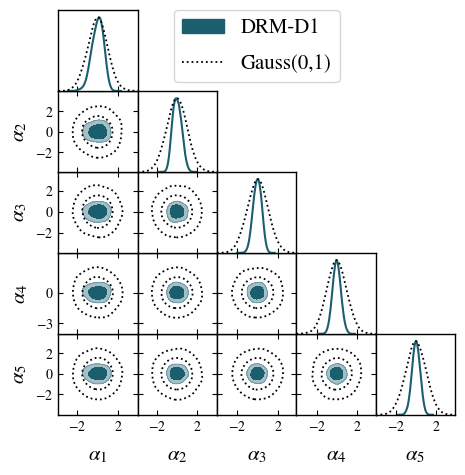

In [ ]:
ndim = 5
nsamp = 10000
random_state = np.random.default_rng(10)
A = random_state.random((ndim, ndim))
cov = np.identity(5)

samps = random_state.multivariate_normal([0] * ndim, cov, size=nsamp)
names = ["projected_alpha%s" % i for i in range(ndim)]
labels = [rf"\alpha_{{{i}}}" for i in range(ndim)]
samples = MCSamples(samples=samps, names=names, labels=labels)

g = plots.get_subplot_plotter(subplot_size=1)
g.settings.title_limit_fontsize = 13
g.settings.legend_fontsize = 20
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 15
g.triangle_plot([chains,samples],
                ["projected_alpha%s" %i for i in range(5)],
                legend_labels=["DRM-D1","Gauss(0,1)"],
                contour_colors=["#1b5f6f","black"],
                contour_ls=['-',':'],
                contour_lws=[1.5,1.3],
                filled=[True,False],
                line_args=[{"ls": "-", "color": "#1b5f6f",'lw':1.5},
                           {"ls": ":", "color": "black",'lw':1.3}],
                )
# plt.savefig("alphas_distributions_unweighted.pdf")

In [107]:
# ==================
# WEIGHTED PCA TODO: PUT THIS IN THE WEIGHTED PCA PART
# ==================
test = np.load(f"{cocoa_path}/cocoa_photoz/roman_nz_realizations/sc1bd4/alphas_distri_E@ndiff.T_sc1bd4.npy")
test_partial = test[:,:10000].T

Removed no burn in
Removed no burn in


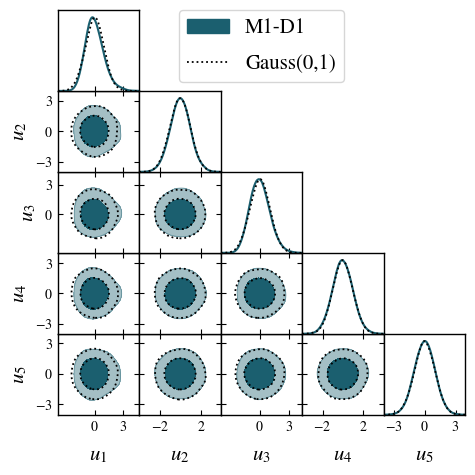

In [111]:
# ==================
# WEIGHTED PCA TODO: PUT THIS IN THE WEIGHTED PCA PART
# ==================
nEig=414
names = ["projected_alpha%s" %i for i in range(nEig)]
labels = [rf"u_{{{i+1}}}" for i in range(nEig)]

chains = MCSamples(samples=test_partial,names=names,labels=labels)

ndim = 5
nsamp = 10000
random_state = np.random.default_rng(10)
A = random_state.random((ndim, ndim))
cov = np.identity(5)

samps = random_state.multivariate_normal([0] * ndim, cov, size=nsamp)
names = ["projected_alpha%s" % i for i in range(ndim)]
labels = [rf"u_{{{i}}}" for i in range(ndim)]
samples = MCSamples(samples=samps, names=names, labels=labels)

g = plots.get_subplot_plotter(subplot_size=1)
g.settings.title_limit_fontsize = 13
g.settings.legend_fontsize = 20
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 15

g.triangle_plot([chains,samples],
                ["projected_alpha%s" %i for i in range(5)],
                legend_labels=["M1-D1","Gauss(0,1)"],
                contour_colors=["#1b5f6f","black"],
                contour_ls=['-',':'],
                contour_lws=[1.5,1.3],
                filled=[True,False],
                line_args=[{"ls": "-", "color": "#1b5f6f",'lw':1.5},
                           {"ls": ":", "color": "black",'lw':1.3}],
                )
plt.savefig("alphas_distributions.pdf")

# Weighted PCA

## Test 9 - Jacobian and the Fisher matrix   
See eq 6 in 2506.00758: $F = \left[{\partial \hat{c}}/{\partial n}\right]^TC^{-1}\left[{\partial \hat{c}}/{\partial n}\right]\equiv J^TC^{-1}J$  
Roman specific case:  
$N_\text{tomo}=9$, $N_z=46$ $\Rightarrow N_\text{tomo}\times N_z=414$  
$\text{dv}\equiv[\xi_+, \xi_-, \gamma_t, w]\rightarrow[675,675,1215,135]$   
$\dim(\text{dv})=2700$    
$\dim(J)=(414, 2700)$  
$\dim(C^{-1})=(2700, 2700)$  
$\dim(F) = [~\cdot~]_{2700,414}~[~\cdot~]_{2700,2700}~[~\cdot~]_{414, 2700}=[~\cdot~]_{}$

In [14]:
roman_obj = SURVEY('roman',use_r=None)
Nz,Nt = roman_obj.nz_params()
z,nz = roman_obj.get_nzs()
nbar_file = roman_obj.roman_nbar()

Cn, ndiff = roman_obj.cov_of_ndiff() # must call before pcs

eig_vecs, eig_vals = roman_obj.pcs('eig')
eih_vecs, eih_vals = roman_obj.pcs('eigh')
svd_vecs, svd_vals = roman_obj.pcs('svd')
# np.savetxt('U.txt',eih_vecs) # Jul 18 using on MCMC

skl_vecs, skl_vals,\
explained_variance, explained_variance_ratio = roman_obj.pcs('sklearn')

In [15]:
stencil_5pt = f'{cocoa_path}/jacobian_outs/stencil_5pt'
stencil_5pt_log = f'{cocoa_path}/jacobian_outs/stencil_5pt_log'
# stencil_5pt_new = f'{cocoa_path}/jacobian_outs/stencil_5pt_new'
stencil_5pt_new = f'{cocoa_path}/jacobian_outs/stencil_5pt_sc1bd4'

Text(0.5, 1.0, '$\\mathbf{C}^{-1}_{\\xi_\\pm}$')

<Figure size 600x600 with 0 Axes>

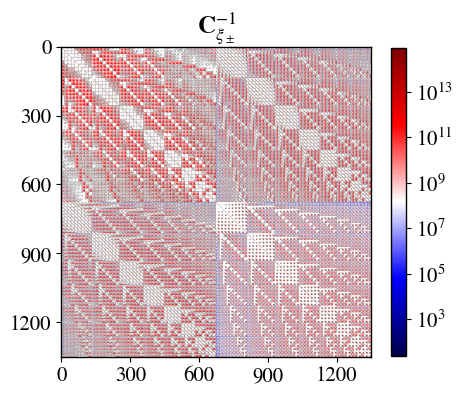

In [22]:
plt.figure(figsize=(6, 6)) 
inv_cov = np.genfromtxt(f'{stencil_5pt}/inv_cov.txt')
inv_cov_xipm = inv_cov[:1350,:1350]

fig, ax = plt.subplots(figsize=(5,5))

vmax = np.max([abs(np.min(inv_cov_xipm)),abs(np.max(inv_cov_xipm))])
import matplotlib.colors as mcolors
# im = ax.imshow(inv_cov_xipm, cmap='seismic',vmin=-1e5,vmax=1e5)
im = ax.imshow(inv_cov_xipm, cmap='seismic',norm=mcolors.LogNorm())

# Set ticks on both axes
ticks = np.arange(0, inv_cov_xipm.shape[0], 300)  # Assumes D is square; adjust interval as needed
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_aspect('equal')
plt.colorbar(im,ax=ax,shrink=0.8);
ax.set_title(r'$\mathbf{C}^{-1}_{\xi_\pm}$')

# plt.savefig("masked_inv_cov_xipm.pdf")

In [16]:
step_sizes = np.logspace(-10, 0, 251)

for i in range(len(step_sizes)):
    s=step_sizes[i]
    print(f'{s:e}, ',end='')

1.000000e-10, 1.096478e-10, 1.202264e-10, 1.318257e-10, 1.445440e-10, 1.584893e-10, 1.737801e-10, 1.905461e-10, 2.089296e-10, 2.290868e-10, 2.511886e-10, 2.754229e-10, 3.019952e-10, 3.311311e-10, 3.630781e-10, 3.981072e-10, 4.365158e-10, 4.786301e-10, 5.248075e-10, 5.754399e-10, 6.309573e-10, 6.918310e-10, 7.585776e-10, 8.317638e-10, 9.120108e-10, 1.000000e-09, 1.096478e-09, 1.202264e-09, 1.318257e-09, 1.445440e-09, 1.584893e-09, 1.737801e-09, 1.905461e-09, 2.089296e-09, 2.290868e-09, 2.511886e-09, 2.754229e-09, 3.019952e-09, 3.311311e-09, 3.630781e-09, 3.981072e-09, 4.365158e-09, 4.786301e-09, 5.248075e-09, 5.754399e-09, 6.309573e-09, 6.918310e-09, 7.585776e-09, 8.317638e-09, 9.120108e-09, 1.000000e-08, 1.096478e-08, 1.202264e-08, 1.318257e-08, 1.445440e-08, 1.584893e-08, 1.737801e-08, 1.905461e-08, 2.089296e-08, 2.290868e-08, 2.511886e-08, 2.754229e-08, 3.019952e-08, 3.311311e-08, 3.630781e-08, 3.981072e-08, 4.365158e-08, 4.786301e-08, 5.248075e-08, 5.754399e-08, 6.309573e-08, 6.9183

In [24]:
deriv_stencil_5pt_all=[]
deriv_stencil_5pt_log_all=[]
deriv_stencil_5pt_new_all=[]
load_jacobians = 2
print(f"Loading {len(step_sizes)} Jacobian matrices:")
for i in range(len(step_sizes)):
    match load_jacobians:
        case 0:
            deriv_i=np.genfromtxt(f'{stencil_5pt}/deriv_ξpm_{step_sizes[i]:e}.txt')
            deriv_stencil_5pt_all.append(deriv_i)
        case 1:
            deriv_i_log=np.genfromtxt(f'{stencil_5pt_log}/deriv_ξpm_{step_sizes[i]:e}.txt')
            deriv_stencil_5pt_log_all.append(deriv_i_log)
        case 2:
            deriv_i_new=np.genfromtxt(f'{stencil_5pt_new}/jacobian_{step_sizes[i]:e}.txt')
            deriv_stencil_5pt_new_all.append(deriv_i_new)
    print(f"{i}, ", end="")

##---------##
match load_jacobians:
    case 0:
        deriv_stencil_5pt_all=np.array(deriv_stencil_5pt_all)
        deriv_stencil_5pt_all_reshaped=deriv_stencil_5pt_all.reshape(deriv_stencil_5pt_all.shape[0],deriv_stencil_5pt_all.shape[1]*deriv_stencil_5pt_all.shape[2])
    case 1:
        deriv_stencil_5pt_log_all=np.array(deriv_stencil_5pt_log_all)
        deriv_stencil_5pt_log_all_reshaped=deriv_stencil_5pt_log_all.reshape(deriv_stencil_5pt_log_all.shape[0],deriv_stencil_5pt_log_all.shape[1]*deriv_stencil_5pt_log_all.shape[2])
    case 2:
        deriv_stencil_5pt_new_all=np.array(deriv_stencil_5pt_new_all)
        deriv_stencil_5pt_new_all_reshaped=deriv_stencil_5pt_new_all.reshape(deriv_stencil_5pt_new_all.shape[0],deriv_stencil_5pt_new_all.shape[1]*deriv_stencil_5pt_new_all.shape[2])

Loading 251 Jacobian matrices:
0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215,

In [17]:
deriv_stencil_5pt_all=[]
deriv_stencil_5pt_log_all=[]
deriv_stencil_5pt_new_all=[]
load_jacobians = 1
print(f"Loading {len(step_sizes)} Jacobian matrices:")
for i in range(len(step_sizes)):
    match load_jacobians:
        case 0:
            deriv_i=np.genfromtxt(f'{stencil_5pt}/deriv_ξpm_{step_sizes[i]:e}.txt')
            deriv_stencil_5pt_all.append(deriv_i)
        case 1:
            deriv_i_log=np.genfromtxt(f'{stencil_5pt_log}/deriv_ξpm_{step_sizes[i]:e}.txt')
            deriv_stencil_5pt_log_all.append(deriv_i_log)
        case 2:
            deriv_i_new=np.genfromtxt(f'{stencil_5pt_new}/jacobian_{step_sizes[i]:e}.txt')
            deriv_stencil_5pt_new_all.append(deriv_i_new)
    print(f"{i}, ", end="")

##---------##
match load_jacobians:
    case 0:
        deriv_stencil_5pt_all=np.array(deriv_stencil_5pt_all)
        deriv_stencil_5pt_all_reshaped=deriv_stencil_5pt_all.reshape(deriv_stencil_5pt_all.shape[0],deriv_stencil_5pt_all.shape[1]*deriv_stencil_5pt_all.shape[2])
    case 1:
        deriv_stencil_5pt_log_all=np.array(deriv_stencil_5pt_log_all)
        deriv_stencil_5pt_log_all_reshaped=deriv_stencil_5pt_log_all.reshape(deriv_stencil_5pt_log_all.shape[0],deriv_stencil_5pt_log_all.shape[1]*deriv_stencil_5pt_log_all.shape[2])
    case 2:
        deriv_stencil_5pt_new_all=np.array(deriv_stencil_5pt_new_all)
        deriv_stencil_5pt_new_all_reshaped=deriv_stencil_5pt_new_all.reshape(deriv_stencil_5pt_new_all.shape[0],deriv_stencil_5pt_new_all.shape[1]*deriv_stencil_5pt_new_all.shape[2])

Loading 251 Jacobian matrices:
0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215,

In [25]:
deriv_stencil_5pt_new_all.shape

(251, 2700, 414)

Jacobian matrix for step_size = 1e-03


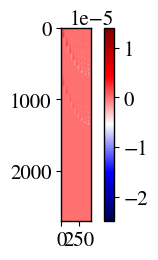

In [26]:
print("Jacobian matrix for step_size = 1e-03")
deriv_stencil_5pt=np.genfromtxt(f'{stencil_5pt_new}/jacobian_1.000000e-03.txt')
plt.imshow(deriv_stencil_5pt, cmap='seismic')
plt.colorbar();

Jacobian matrix for step_size = 1e-03


Text(0, 0.5, '$\\longleftarrow~\\text{redshift}~k;~\\text{bin}~t$')

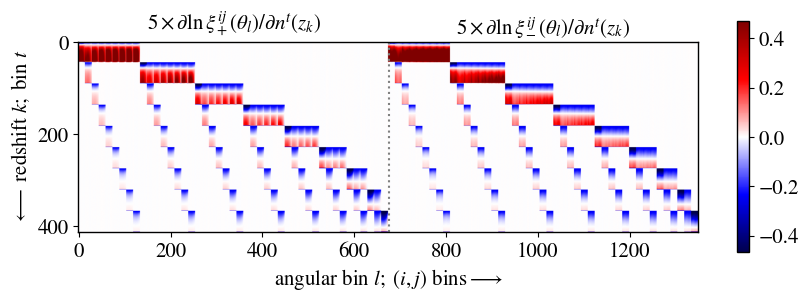

In [27]:
print("Jacobian matrix for step_size = 1e-03")

fig, ax = plt.subplots(figsize=(10, 15))

# plt.figure(figsize=(10, 11))
deriv_stencil_5pt=np.genfromtxt(f'{stencil_5pt_log}/deriv_ξpm_1.000000e-03.txt')

vmax = max(abs(np.max(deriv_stencil_5pt)), abs(np.min(deriv_stencil_5pt))) 
im = ax.imshow(deriv_stencil_5pt*5, cmap='seismic',vmin=-vmax,vmax=vmax)
cbar = fig.colorbar(im,ax=ax,shrink=0.2);

ax.text(675/2, -5, r"$5\times\partial\ln\xi_+^{ij}(\theta_l)/\partial n^t(z_k)$", ha='center', va='bottom', fontsize=15)
ax.text((675 + 1349)/2, -5, r"$5\times\partial\ln\xi_-^{ij}(\theta_l)/\partial n^t(z_k)$", ha='center', va='bottom', fontsize=15)

ax.axvline(x=675, color='gray', linestyle=':') 
ax.set_xlabel(r"$\text{angular bin}~l;~(i,j)~\text{bins}\longrightarrow$")
ax.set_ylabel(r"$\longleftarrow~\text{redshift}~k;~\text{bin}~t$")
# plt.savefig("jacobian_log.pdf")

Jacobian matrix for step_size = 1e-03
(414, 1350)


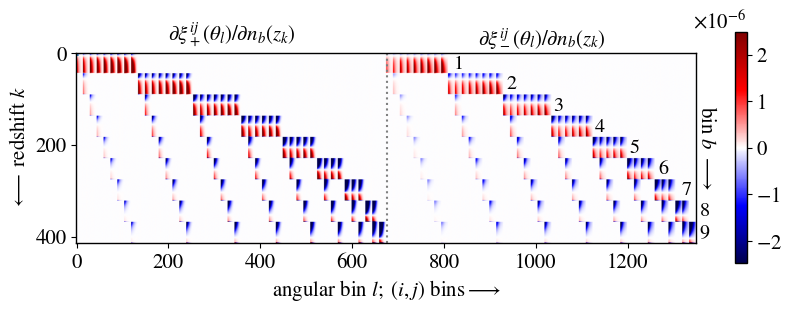

In [59]:
print("Jacobian matrix for step_size = 1e-03")

fig, ax = plt.subplots(figsize=(10, 15))
ax.plot([0, 1, 2], [0, 1, 4])

# plt.figure(figsize=(10, 11))
deriv_stencil_5pt=np.genfromtxt(f'{stencil_5pt_new}/jacobian_1.000000e-03.txt')[:1350,:].T
print(deriv_stencil_5pt.shape)

scale=1e-1
vmax = max(abs(np.max(deriv_stencil_5pt)), abs(np.min(deriv_stencil_5pt))) 
im = ax.imshow(deriv_stencil_5pt, cmap='seismic',vmin=-vmax*scale,vmax=vmax*scale)
# cbar = fig.colorbar(im,ax=ax,shrink=0.2);

## colorbar tweaks
from matplotlib.ticker import ScalarFormatter

cbar = fig.colorbar(im, ax=ax, shrink=0.2)
cbar.formatter = ScalarFormatter(useMathText=True)
cbar.formatter.set_powerlimits((-2, 2))  # controls when to switch to scientific notation
cbar.update_ticks()
## colorbar tweaks

ax.text(675/2, -5, r"$\partial\xi_+^{ij}(\theta_l)/\partial n_b(z_k)$", ha='center', va='bottom', fontsize=15)
ax.text((675 + 1349)/2, -5, r"$\partial\xi_-^{ij}(\theta_l)/\partial n_b(z_k)$", ha='center', va='bottom', fontsize=15)

ax.axvline(x=675, color='gray', linestyle=':') 
ax.set_xlabel(r"$\text{angular bin}~l;~(i,j)~\text{bins}\longrightarrow$")
ax.set_ylabel(r"$\longleftarrow~\text{redshift}~k$")

ax.text(1., 0.5, r"$\mathrm{bin}~b~\longrightarrow$", transform=ax.transAxes,
        rotation=270, va='center', ha='left')

nblocks = 9
nrows = deriv_stencil_5pt.shape[0]

x_base = 819
x_step = 122   # how much to shift each next label
drop = [6.5,6.5,6.5,6.5,6.5,6.5,6.5,6.5,6.87]
for k in range(nblocks):
    y_center = (k + 0.5) * (nrows / nblocks)
    ax.text(x_base + k * (x_step-k*drop[k]), y_center, rf"${{{k+1}}}$",
            rotation=0, va='center', ha='left', fontsize=14.5)
plt.savefig("jacobian.pdf")

In [30]:
# print("Mean of the Jacobian matrices across the step sizes")
# deriv_stencil_5pt_all_mean = np.mean(deriv_stencil_5pt_all,axis=0)
# plt.imshow(deriv_stencil_5pt_all_mean, cmap='seismic')
# plt.colorbar(shrink=0.3);

In [39]:
# print("Mean of the Jacobian matrices across the step sizes")
# deriv_stencil_5pt_all_mean = np.mean(deriv_stencil_5pt_log_all,axis=0)
# plt.imshow(deriv_stencil_5pt_all_mean, cmap='jet')
# plt.colorbar(shrink=0.3);

In [33]:
print("Example: Mean of a n-dimensional numpy array\n")
test = np.array(([[1,2,3],[4,5,6]],[[7,8,9],[10,11,12]],[[13,14,15],[16,17,18]]))
print(test,"\n")
print(test.reshape(3,2*3))
np.mean(test,axis=0)

Example: Mean of a n-dimensional numpy array

[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]

 [[13 14 15]
  [16 17 18]]] 

[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]
 [13 14 15 16 17 18]]


array([[ 7.,  8.,  9.],
       [10., 11., 12.]])

In [35]:
print(test.reshape(3,2*3))
print(np.mean(test.reshape(3,2*3),axis=1))
print(test[0].flatten(),np.mean(test[0].flatten()))
print(test[1].flatten(),np.mean(test[1].flatten()))
print(test[2].flatten(),np.mean(test[2].flatten()))
# test2=deriv_stencil_5pt_all.reshape(251,414*1350)
# test2=np.mean(test2,axis=1)
# print(test2.shape)

[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]
 [13 14 15 16 17 18]]
[ 3.5  9.5 15.5]
[1 2 3 4 5 6] 3.5
[ 7  8  9 10 11 12] 9.5
[13 14 15 16 17 18] 15.5


Text(0, 0.5, 'Derivative values: $\\partial\\xi/\\partial n(z)$')

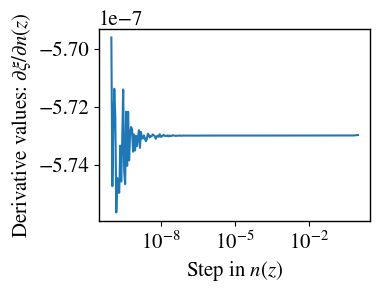

In [36]:
row=18 # the n(z) at some tomographic bin. ANY VALUE BTW 0 AND 413. TOTAL POINTS: 46 * 9 = 414
col=2 # the θ binning. ANY VALUE BTW 0 AND 1349. TOTAL POINTS: 675 + 675 = 1350
jacob_values=[]
for ith_JM in range(len(step_sizes)): # For the ith Jacobian matrix corresponding to the ith step_size...
    jacob_values.append(deriv_stencil_5pt_new_all[ith_JM,row,col]) # ...select its row `row` and column `col`
plt.semilogx(step_sizes,jacob_values)
plt.xlabel(r"Step in $n(z)$")
plt.ylabel(r"Derivative values: $\partial\xi/\partial n(z)$")

In [44]:
deriv_stencil_5pt_log_all

array([], dtype=float64)

In [61]:
theta_min = 2.5
theta_max = 250
n_theta = 15
np.linspace(theta_min,theta_max,n_theta)

array([  2.5       ,  20.17857143,  37.85714286,  55.53571429,
        73.21428571,  90.89285714, 108.57142857, 126.25      ,
       143.92857143, 161.60714286, 179.28571429, 196.96428571,
       214.64285714, 232.32142857, 250.        ])

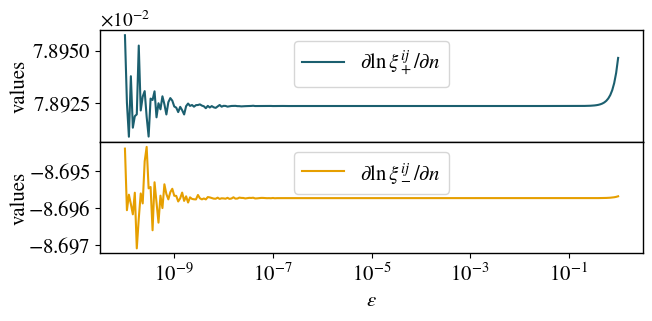

In [60]:
row=18 # the n(z) at some tomographic bin. ANY VALUE BTW 0 AND 413. TOTAL POINTS: 46 * 9 = 414
col=2 # the θ binning. ANY VALUE BTW 0 AND 1349. TOTAL POINTS: 675 + 675 = 1350
jacob_values=[]
jacob_values2=[]
deriv_stencil_5pt_log_all=np.array(deriv_stencil_5pt_log_all)

# Info start
print(step_sizes.shape)
print(deriv_stencil_5pt_log_all.shape)
print(15*45)
print(z[18])
# Info ends

from matplotlib.ticker import ScalarFormatter


fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, sharey=False,figsize=(7,2.9),
                        gridspec_kw={'wspace':0, 'hspace':0.0})

for ith_JM in range(len(step_sizes)): # For the ith Jacobian matrix corresponding to the ith step_size...
    jacob_values.append(deriv_stencil_5pt_log_all[ith_JM,row,col]) # ...select its row `row` and column `col`
    jacob_values2.append(deriv_stencil_5pt_log_all[ith_JM,2,674+4]) # ...select its row `row` and column `col`
axes[0].semilogx(step_sizes,jacob_values,label=r"$\partial\ln\xi^{ij}_+/\partial n$",color=colors1[0])
axes[1].semilogx(step_sizes,jacob_values2,label=r"$\partial\ln\xi^{ij}_-/\partial n$",color=colors1[1])
axes[1].set_xlabel(r"$\epsilon$")
axes[0].set_ylabel('values')
axes[1].set_ylabel('values')

# Apply scientific tick formatting
for ax in axes:
    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((0, 0))  # Always show ×10^n
    ax.yaxis.set_major_formatter(sf)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

# Force offset text visibility (this only applies to one axis automatically)
axes[0].yaxis.get_offset_text().set_visible(True)
axes[1].yaxis.get_offset_text().set_visible(False)
axes[0].yaxis.offsetText.set_position((0, 1.02))  # move it just above y-axis
axes[0].yaxis.offsetText.set_fontsize(10)
axes[0].yaxis.offsetText.set_fontsize(14)  # or any size you like
axes[0].yaxis.set_label_coords(-0.13, 0.5)
axes[1].yaxis.set_label_coords(-0.13, 0.5)
axes[0].legend(loc='upper center')
axes[1].legend(loc='upper center')
plt.savefig("derivative.pdf")

<Figure size 350x250 with 0 Axes>

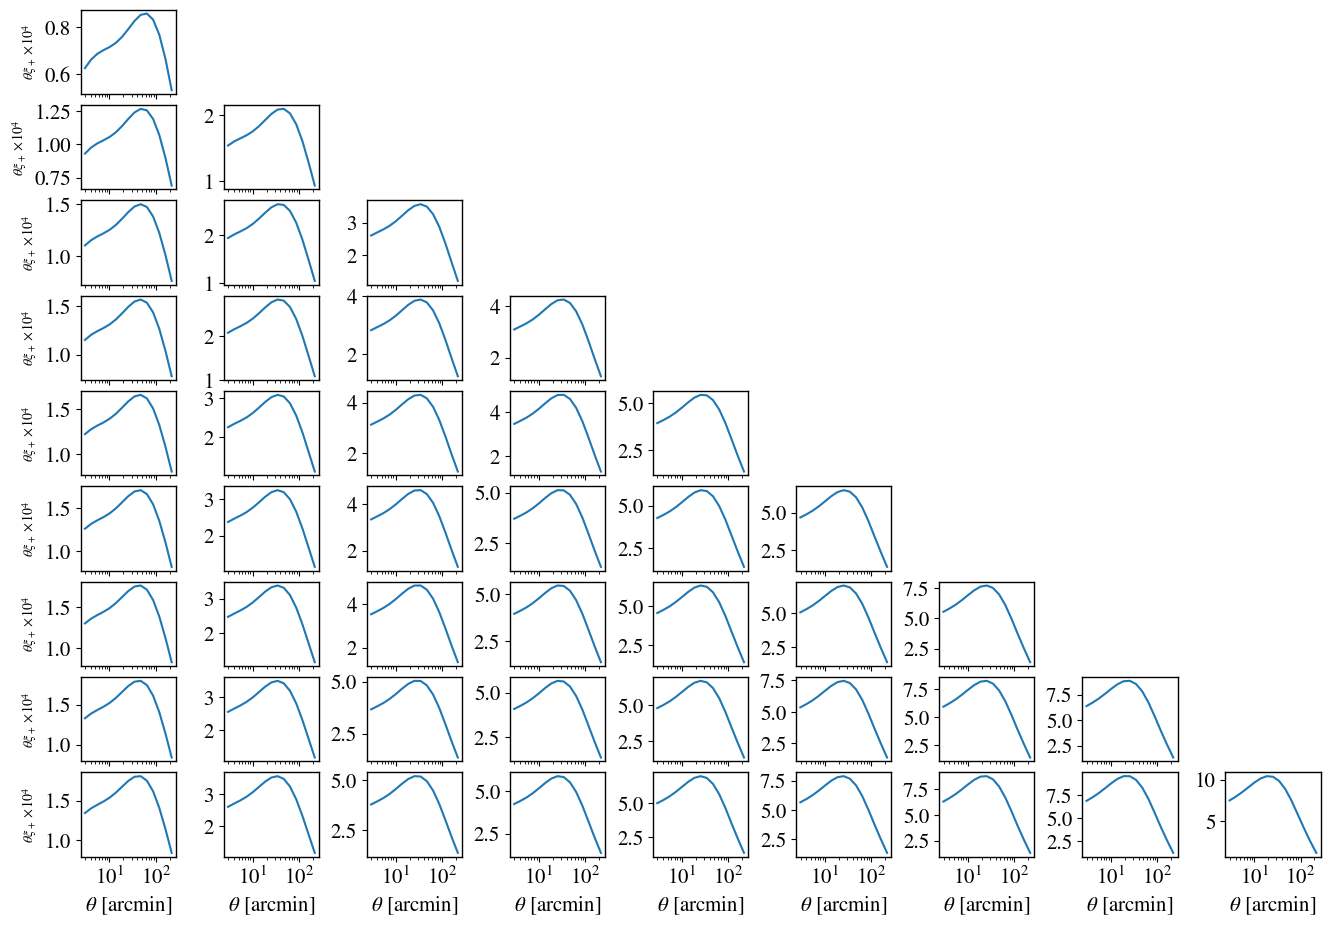

In [20]:
"""
COMPARE WITH INPUT [42] IN https://github.com/CosmoLike/cocoa_lsst_y1/blob/main/EXAMPLE_EVALUATE1.ipynb
"""
plt.figure()
fig, axes = plt.subplots(nrows=9, ncols=9, sharex=True, sharey=False,figsize=(16, 11),
                        gridspec_kw={'wspace':0.5, 'hspace':0.13})
for i in range(Nt):
    for j in range(Nt):
        if i < j:  # This condition identifies the upper triangle (excluding the diagonal)
            axes[i, j].axis('off')

tomo_bins = [(i,j) for i in range(Nt) for j in range(Nt) if j>=i] # Tomo bin combinations
xip_fid=np.genfromtxt(f'{cocoa_path}/jacobian_outs/stencil_5pt/ξp_fid.txt')
thetas=np.genfromtxt(f'{cocoa_path}/jacobian_outs/stencil_5pt/thetas.txt')

for l,(i,j) in enumerate(tomo_bins):
    axes[j,i].semilogx(thetas,thetas*xip_fid[len(thetas)*l:len(thetas)*(l+1)]*10**4)
    if i==0:
        axes[j,i].set_ylabel(r'$\theta\xi_+\times10^4$',fontsize=10)
    if j==8:
        axes[j,i].set_xlabel(r'$\theta$ [arcmin]')


<Figure size 350x250 with 0 Axes>

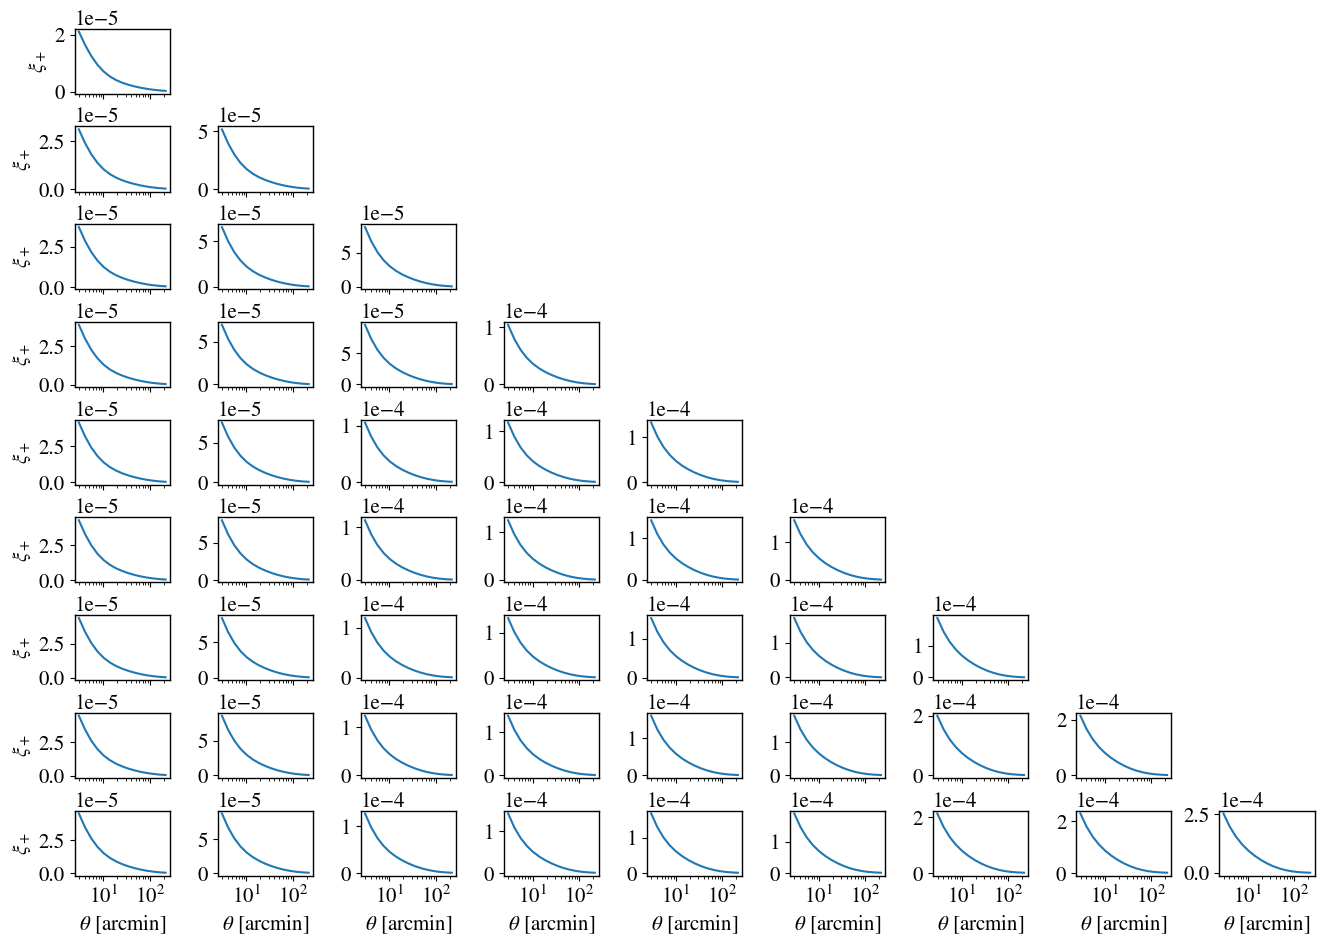

In [21]:
"""
THE ACTUALL FUNCTION AND ITS MAGNITUDE
"""
plt.figure()
fig, axes = plt.subplots(nrows=9, ncols=9, sharex=True, sharey=False,figsize=(16, 11),
                        gridspec_kw={'wspace':0.5, 'hspace':0.5})
for i in range(Nt):
    for j in range(Nt):
        if i < j:  # This condition identifies the upper triangle (excluding the diagonal)
            axes[i, j].axis('off')

for l,(i,j) in enumerate(tomo_bins):
    axes[j,i].semilogx(thetas,xip_fid[len(thetas)*l:len(thetas)*(l+1)])
    if i==0:
        axes[j,i].set_ylabel(r'$\xi_+$')
    if j==8:
        axes[j,i].set_xlabel(r'$\theta$ [arcmin]')
    axes[j, i].ticklabel_format(axis='y', style='scientific', scilimits=(0, 0)) #    

<Figure size 350x250 with 0 Axes>

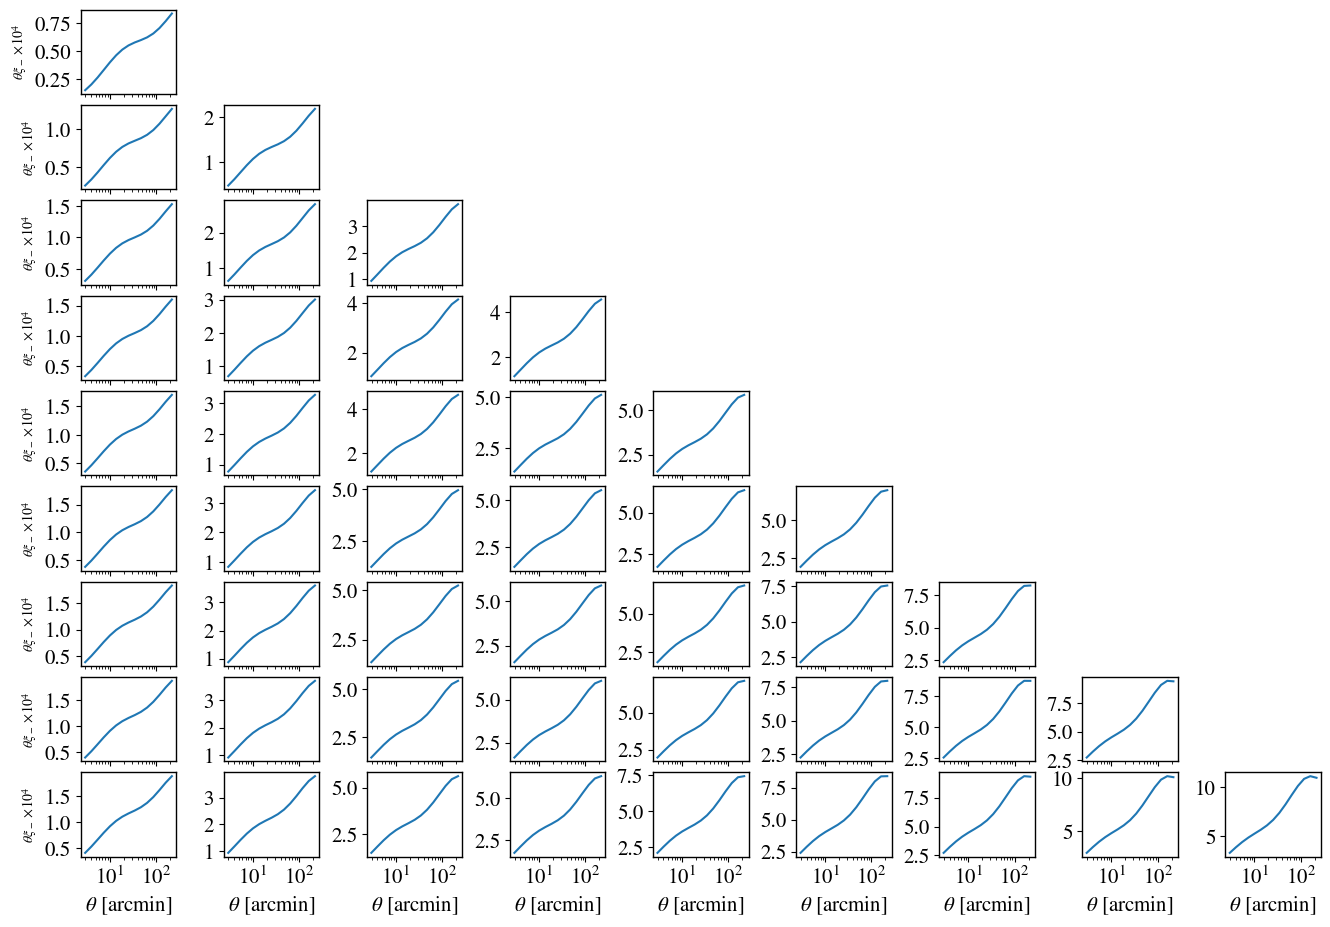

In [22]:
"""
COMPARE WITH INPUT [43] IN https://github.com/CosmoLike/cocoa_lsst_y1/blob/main/EXAMPLE_EVALUATE1.ipynb
"""
plt.figure()
fig, axes = plt.subplots(nrows=9, ncols=9, sharex=True, sharey=False,figsize=(16, 11),
                        gridspec_kw={'wspace':0.5, 'hspace':0.13})
for i in range(Nt):
    for j in range(Nt):
        if i < j:  # This condition identifies the upper triangle (excluding the diagonal)
            axes[i, j].axis('off')
tomo_bins = [(i,j) for i in range(Nt) for j in range(Nt) if j>=i] # Tomo bin combinations
xim_fid=np.genfromtxt(f'{cocoa_path}/jacobian_outs/stencil_5pt/ξm_fid.txt')
thetas=np.genfromtxt(f'{cocoa_path}/jacobian_outs/stencil_5pt/thetas.txt')

for l,(i,j) in enumerate(tomo_bins):
    axes[j,i].semilogx(thetas,thetas*xim_fid[len(thetas)*l:len(thetas)*(l+1)]*10**4)
    # axes[j,i].semilogx(thetas,xim_fid[len(thetas)*l:len(thetas)*(l+1)])
    if i==0:
        axes[j,i].set_ylabel(r'$\theta\xi_-\times10^4$',fontsize=10)
        # axes[j,i].set_ylabel(r'$\xi_-\times$')
    if j==8:
        axes[j,i].set_xlabel(r'$\theta$ [arcmin]')


<Figure size 350x250 with 0 Axes>

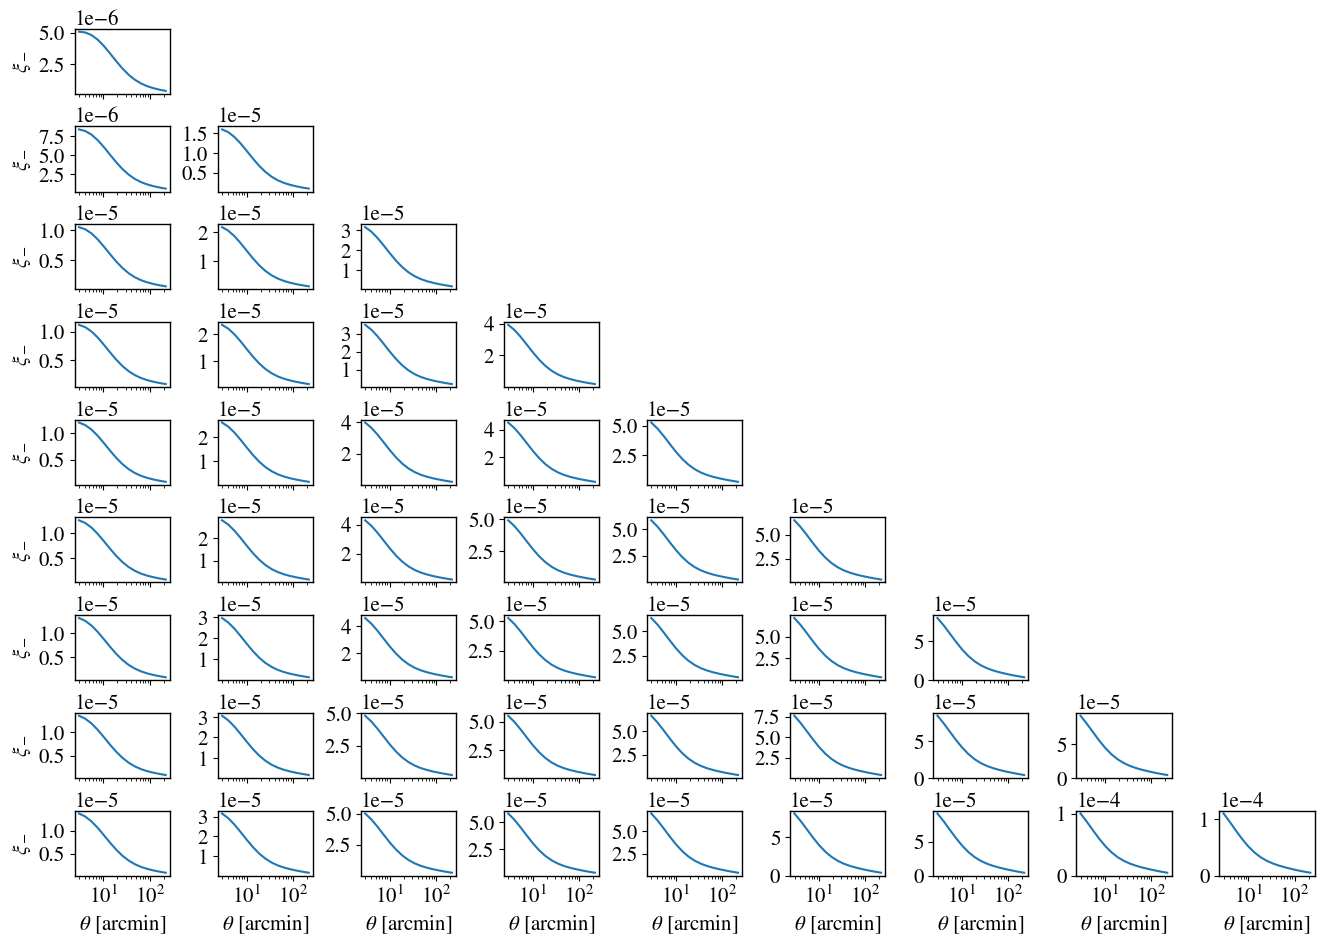

In [23]:
"""
THE ACTUALL FUNCTION AND ITS TYPICAL MAGNITUDE
"""
plt.figure()
fig, axes = plt.subplots(nrows=9, ncols=9, sharex=True, sharey=False,figsize=(16, 11),
                        gridspec_kw={'wspace':0.5, 'hspace':0.5})
for i in range(Nt):
    for j in range(Nt):
        if i < j:  # This condition identifies the upper triangle (excluding the diagonal)
            axes[i, j].axis('off')

for l,(i,j) in enumerate(tomo_bins):
    axes[j,i].semilogx(thetas,xim_fid[len(thetas)*l:len(thetas)*(l+1)])
    if i==0:
        axes[j,i].set_ylabel(r'$\xi_-$')
    if j==8:
        axes[j,i].set_xlabel(r'$\theta$ [arcmin]')
    axes[j, i].ticklabel_format(axis='y', style='scientific', scilimits=(0, 0)) #   

<Figure size 350x250 with 0 Axes>

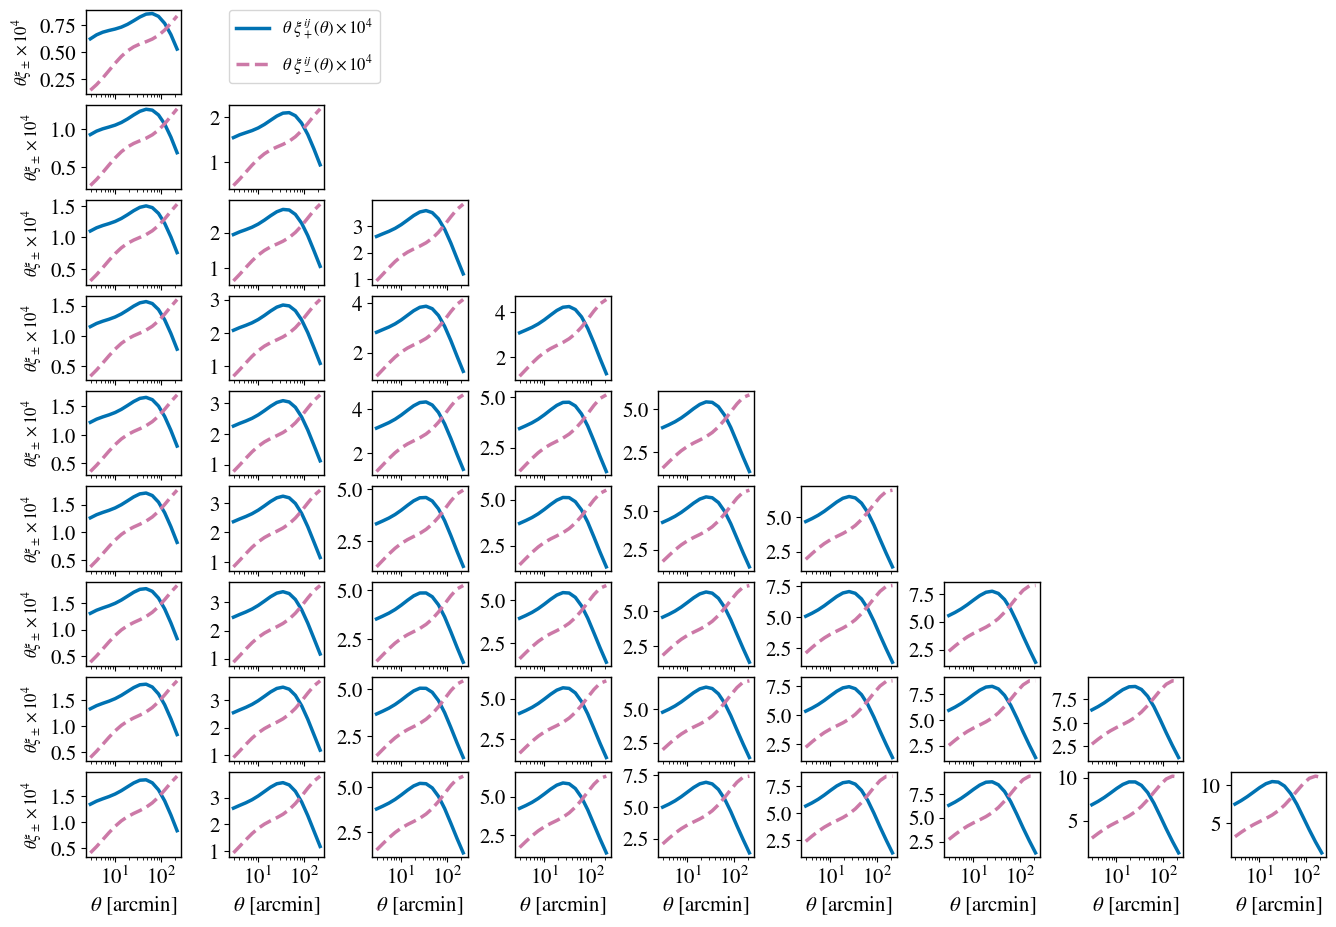

In [24]:
"""
COMPARE WITH INPUT [42] IN https://github.com/CosmoLike/cocoa_lsst_y1/blob/main/EXAMPLE_EVALUATE1.ipynb
"""
plt.figure()
fig, axes = plt.subplots(nrows=9, ncols=9, sharex=True, sharey=False,figsize=(16, 11),
                        gridspec_kw={'wspace':0.5, 'hspace':0.13})
for i in range(Nt):
    for j in range(Nt):
        if i < j:  # This condition identifies the upper triangle (excluding the diagonal)
            axes[i, j].axis('off')

tomo_bins = [(i,j) for i in range(Nt) for j in range(Nt) if j>=i] # Tomo bin combinations

label_xip=r'$\theta~\xi_+^{ij}(\theta)\times10^{4}$'
label_xim=r'$\theta~\xi_-^{ij}(\theta)\times10^{4}$'
color_xip='#0072B2'
color_xim='#CC79A7'
lw_xip=2.5
lw_xim=2.5
ls_xip='-'
ls_xim='--'

for l,(i,j) in enumerate(tomo_bins):
    if i==0 and j==0:
        axes[j,i].semilogx(thetas,thetas*xip_fid[len(thetas)*l:len(thetas)*(l+1)]*10**4,label=label_xip,color=color_xip,lw=lw_xip,ls=ls_xip)
        axes[j,i].semilogx(thetas,thetas*xim_fid[len(thetas)*l:len(thetas)*(l+1)]*10**4,label=label_xim,color=color_xim,lw=lw_xim,ls=ls_xim)
        axes[j, i].legend(
        loc='upper left',
        bbox_to_anchor=(1.5, 1),  # (x, y) in axes coordinates
        borderaxespad=0.,
        fontsize=12)
    else:
        axes[j,i].semilogx(thetas,thetas*xip_fid[len(thetas)*l:len(thetas)*(l+1)]*10**4,color=color_xip,lw=lw_xip,ls=ls_xip)
        axes[j,i].semilogx(thetas,thetas*xim_fid[len(thetas)*l:len(thetas)*(l+1)]*10**4,color=color_xim,lw=lw_xim,ls=ls_xim)
    if i==0:
        axes[j,i].set_ylabel(r'$\theta\xi_\pm\times10^4$',fontsize=12)
    if j==8:
        axes[j,i].set_xlabel(r'$\theta$ [arcmin]')
# plt.savefig('scaled_xip_and_xim.pdf')

<Figure size 350x250 with 0 Axes>

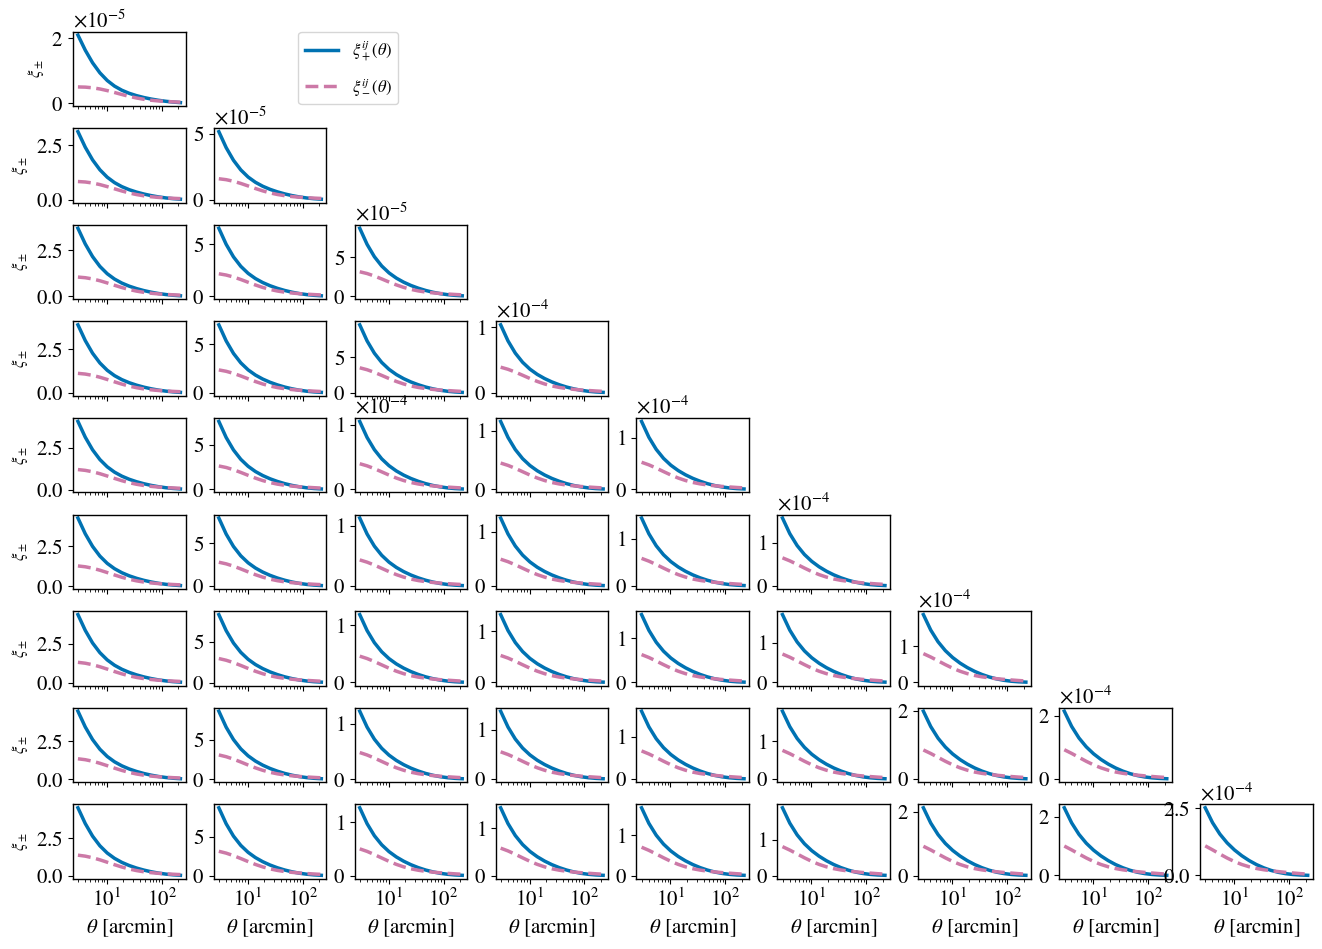

In [25]:
"""
COMPARE WITH INPUT [42] IN https://github.com/CosmoLike/cocoa_lsst_y1/blob/main/EXAMPLE_EVALUATE1.ipynb
"""
plt.figure()
fig, axes = plt.subplots(nrows=9, ncols=9, sharex=True, sharey=False,figsize=(16, 11),
                        gridspec_kw={'wspace':0.25, 'hspace':0.30})
for i in range(Nt):
    for j in range(Nt):
        if i < j:  # This condition identifies the upper triangle (excluding the diagonal)
            axes[i, j].axis('off')

tomo_bins = [(i,j) for i in range(Nt) for j in range(Nt) if j>=i] # Tomo bin combinations

label_xip=r'$\xi_+^{ij}(\theta)$'
label_xim=r'$\xi_-^{ij}(\theta)$'
color_xip='#0072B2'
color_xim='#CC79A7'
lw_xip=2.5
lw_xim=2.5
ls_xip='-'
ls_xim='--'

for l,(i,j) in enumerate(tomo_bins):
    if i==0 and j==0:
        axes[j,i].semilogx(thetas,xip_fid[len(thetas)*l:len(thetas)*(l+1)],label=label_xip,color=color_xip,lw=lw_xip,ls=ls_xip)
        axes[j,i].semilogx(thetas,xim_fid[len(thetas)*l:len(thetas)*(l+1)],label=label_xim,color=color_xim,lw=lw_xim,ls=ls_xim)
        axes[j, i].legend(
        loc='upper left',
        bbox_to_anchor=(2.0, 1),  # (x, y) in axes coordinates
        borderaxespad=0.,
        fontsize=12)
    else:
        axes[j,i].semilogx(thetas,xip_fid[len(thetas)*l:len(thetas)*(l+1)],color=color_xip,lw=lw_xip,ls=ls_xip)
        axes[j,i].semilogx(thetas,xim_fid[len(thetas)*l:len(thetas)*(l+1)],color=color_xim,lw=lw_xim,ls=ls_xim)
    if i==0:
        axes[j,i].set_ylabel(r'$\xi_\pm$',fontsize=12)
    if j==8:
        axes[j,i].set_xlabel(r'$\theta$ [arcmin]')

for i in range(Nt):
    for j in range(Nt):
        if j >= i:
            ax = axes[j, i]
            formatter = ScalarFormatter(useMathText=True)
            formatter.set_powerlimits((0, 0))  # always use scientific notation
            ax.yaxis.set_major_formatter(formatter)
            ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
            ax.yaxis.get_offset_text().set_visible(True)

for row in range(1,9):
    axes[row,0].yaxis.get_offset_text().set_visible(False)
for row in range(2,9):
    axes[row,1].yaxis.get_offset_text().set_visible(False)
axes[3,2].yaxis.get_offset_text().set_visible(False)

for row in range(5,9):
    axes[row,2].yaxis.get_offset_text().set_visible(False)

for row in range(4,9):
    axes[row,3].yaxis.get_offset_text().set_visible(False)
for row in range(5,9):
    axes[row,4].yaxis.get_offset_text().set_visible(False)
for row in range(6,9):
    axes[row,5].yaxis.get_offset_text().set_visible(False)
for row in range(7,9):
    axes[row,6].yaxis.get_offset_text().set_visible(False)
for row in range(8,9):
    axes[row,7].yaxis.get_offset_text().set_visible(False)

# plt.savefig('xip_and_xim.pdf')

<Figure size 350x250 with 0 Axes>

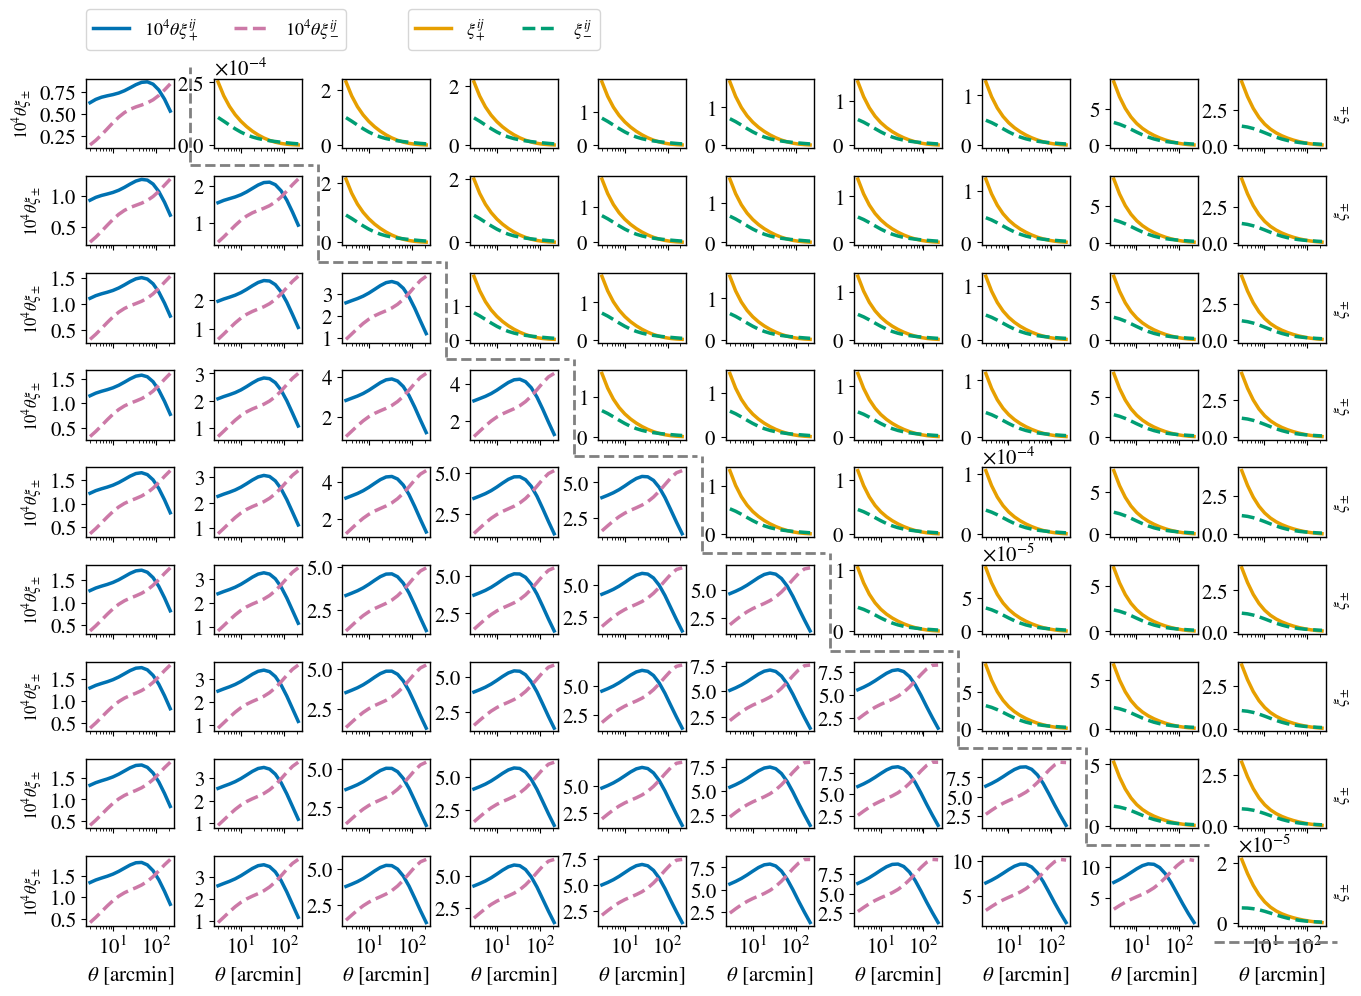

In [29]:
"""
COMPARE WITH INPUT [42] IN https://github.com/CosmoLike/cocoa_lsst_y1/blob/main/EXAMPLE_EVALUATE1.ipynb
"""
plt.figure()
fig, axes = plt.subplots(nrows=9, ncols=10, sharex=True, sharey=False,figsize=(16, 11),
                        gridspec_kw={'wspace':0.45, 'hspace':0.4})

tomo_bins_lower = [(i,j) for j in range(10) for i in range(9) if i >=j] # Tomo bin combinations 
tomo_bins_upper = [(i,j) for j in range(10)[::-1] for i in range(9)[::-1] if j>i] # Tomo bin combinations 

label_xip=r'$10^4\theta\xi_+^{ij}$'
label_xim=r'$10^4\theta\xi_-^{ij}$'
label_xip_upper=r'$\xi_+^{ij}$'
label_xim_upper=r'$\xi_-^{ij}$'
color_xip_lower='#0072B2'
color_xim_lower='#CC79A7'
color_xip_upper='#E69F00'
color_xim_upper='#009E73'
lw_xip=2.5
lw_xim=2.5
ls_xip='-'
ls_xim='--'

###########################
##  LOWER TRIANGLE PLOT ###
###########################
for l,(i,j) in enumerate(tomo_bins_lower):
    if i==0 and j==0:
        axes[i,j].semilogx(thetas,thetas*xip_fid[len(thetas)*l:len(thetas)*(l+1)]*10**4,label=label_xip,color=color_xip_lower,lw=lw_xip,ls=ls_xip)
        axes[i,j].semilogx(thetas,thetas*xim_fid[len(thetas)*l:len(thetas)*(l+1)]*10**4,label=label_xim,color=color_xim_lower,lw=lw_xim,ls=ls_xim)
        axes[i,j].legend(
        loc='upper left',
        bbox_to_anchor=(0, 2.),  # (x, y) in axes coordinates
        borderaxespad=0.,
        fontsize=13,
        ncols=2)
    else:
        axes[i,j].semilogx(thetas,thetas*xip_fid[len(thetas)*l:len(thetas)*(l+1)]*10**4,color=color_xip_lower,lw=lw_xip,ls=ls_xip)
        axes[i,j].semilogx(thetas,thetas*xim_fid[len(thetas)*l:len(thetas)*(l+1)]*10**4,color=color_xim_lower,lw=lw_xim,ls=ls_xim)
    if j==0:
        axes[i,j].set_ylabel(r'$10^4\theta\xi_\pm$',fontsize=12)
    if i==8:
        axes[i,j].set_xlabel(r'$\theta$ [arcmin]')

###########################
##  UPPER TRIANGLE PLOT ###
###########################
for l,(i,j) in enumerate(tomo_bins_upper):
    if i==0 and j==1:
        axes[i,j].semilogx(thetas,xip_fid[len(thetas)*l:len(thetas)*(l+1)],label=label_xip_upper,color=color_xip_upper,lw=lw_xip,ls=ls_xip)
        axes[i,j].semilogx(thetas,xim_fid[len(thetas)*l:len(thetas)*(l+1)],label=label_xim_upper,color=color_xim_upper,lw=lw_xim,ls=ls_xim)
        axes[i,j].legend(
        loc='upper left',
        bbox_to_anchor=(2.2, 2.),  # (x, y) in axes coordinates
        borderaxespad=0.,
        fontsize=13,
        ncols=2)
    else:
        axes[i,j].semilogx(thetas,xip_fid[len(thetas)*l:len(thetas)*(l+1)],color=color_xip_upper,lw=lw_xip,ls=ls_xip)
        axes[i,j].semilogx(thetas,xim_fid[len(thetas)*l:len(thetas)*(l+1)],color=color_xim_upper,lw=lw_xim,ls=ls_xim)
    if j==9:
        axes[i,j].set_ylabel(r'$\xi_\pm$',fontsize=13)
        axes[i,j].yaxis.set_label_position("right") 
    if j==9 and i == 8:
        axes[i,j].set_xlabel(r'$\theta$ [arcmin]')

for (i,j) in tomo_bins_upper:
    ax = axes[i,j]
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))  # always use scientific notation
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_visible(True)


for row in range(0,8):
    axes[row,9].yaxis.get_offset_text().set_visible(False)
for row in range(0,9):
    axes[row,8].yaxis.get_offset_text().set_visible(False)
axes[6,7].yaxis.get_offset_text().set_visible(False)
for row in range(0,4):
    axes[row,7].yaxis.get_offset_text().set_visible(False)
for row in range(0,4):
    axes[row,7].yaxis.get_offset_text().set_visible(False)
for row in range(0,6):
    axes[row,6].yaxis.get_offset_text().set_visible(False)
for row in range(0,5):
    axes[row,5].yaxis.get_offset_text().set_visible(False)
for row in range(0,4):
    axes[row,4].yaxis.get_offset_text().set_visible(False)
for row in range(0,3):
    axes[row,3].yaxis.get_offset_text().set_visible(False)
for row in range(0,2):
    axes[row,2].yaxis.get_offset_text().set_visible(False)

from matplotlib.lines import Line2D

# after you've created `fig, axes` and plotted everything...

for k in range(9):
    if k < 9 and k < 10:
        ax = axes[k, k]
        pos = ax.get_position()

        # horizontal line (between subplot [k,k] and [k,k+1])
        if k < 9:  # not the last column
            ax_right = axes[k, k+1].get_position()
            line = Line2D([pos.x1+0.01, ax_right.x0+0.062], [pos.y0-0.015, pos.y0-0.015],
                          transform=fig.transFigure, color="gray", lw=2,ls='--')
            fig.add_artist(line)

        # vertical line (to the right side of subplot [k,k])
        if k < 8:  # not the last row
            ax_below = axes[k+1, k].get_position()
            line = Line2D([pos.x1+0.01, pos.x1+0.01], [pos.y0-.013, ax_below.y1+0.099],
                          transform=fig.transFigure, color="gray", lw=2,ls='--')
            fig.add_artist(line)

# plt.savefig('xip_and_xim_comparison.pdf')

In [80]:
def fisher_outs(step_sizes='1.000000e-03',relative_path='stencil_5pt',weights=True,save_fisher=False):
    if weights:
        deriv_ξpm  = np.genfromtxt(f'{cocoa_path}/jacobian_outs/{relative_path}/deriv_ξpm_{step_sizes}.txt')
        fisher_ξpm = deriv_ξpm@inv_cov[:deriv_ξpm.shape[1],:deriv_ξpm.shape[1]]@deriv_ξpm.T
    if not weights:
        fisher_ξpm = np.identity(Cn.shape[0])

    if not roman_obj.isPD(fisher_ξpm):
        print('fixing cov')
        F=roman_obj.nearestPD(fisher_ξpm)
    else:
        F=fisher_ξpm    

    chisq_threshold=0
    
    E, D, ss, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M = roman_obj.getModes(F, Cn, chisq_threshold=chisq_threshold)

    if weights:
        fisher_outs_dict = {"deriv_ξpm":deriv_ξpm, "fisher_ξpm":fisher_ξpm,
                            "F":F, "ss":ss, "resid":resid, "D":D, "Cnval":Cnval,
                            "Cnvec":Cnvec}
    if not weights:    
        fisher_outs_dict = {"fisher_ξpm":fisher_ξpm, "F":F, "ss":ss, "resid":resid, "D":D, "Cnval":Cnval,"Cnvec":Cnvec}
    if save_fisher:
        np.savetxt(f'{cocoa_path}/jacobian_outs/{relative_path}/D_weighted_{step_sizes}.txt',D)

    return fisher_outs_dict

In [81]:
fisher_results = fisher_outs('1.000000e-03','stencil_5pt',weights=True)

fixing cov


/tmp/ipykernel_2348652/3776551322.py:225: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)


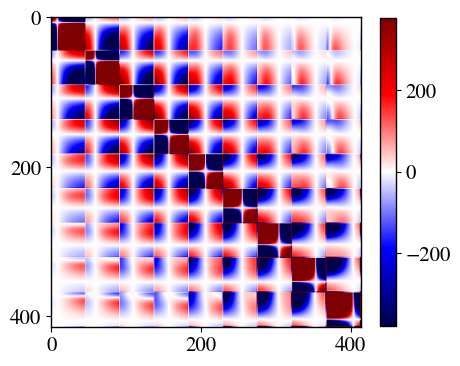

In [82]:
fig, ax = plt.subplots(figsize=(5,5))

F = fisher_results["F"]

vmax = np.max([abs(np.min(F)),abs(np.max(F))])

im = ax.imshow(F*50, cmap='seismic',vmin=-vmax,vmax=vmax)

# Set ticks on both axes
ticks = np.arange(0, F.shape[0], 200)  # Assumes D is square; adjust interval as needed
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_aspect('equal')

plt.colorbar(im,ax=ax,shrink=0.8);

# plt.savefig('fisher_matrix_1e-3.pdf')

/tmp/ipykernel_2348652/2151810112.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

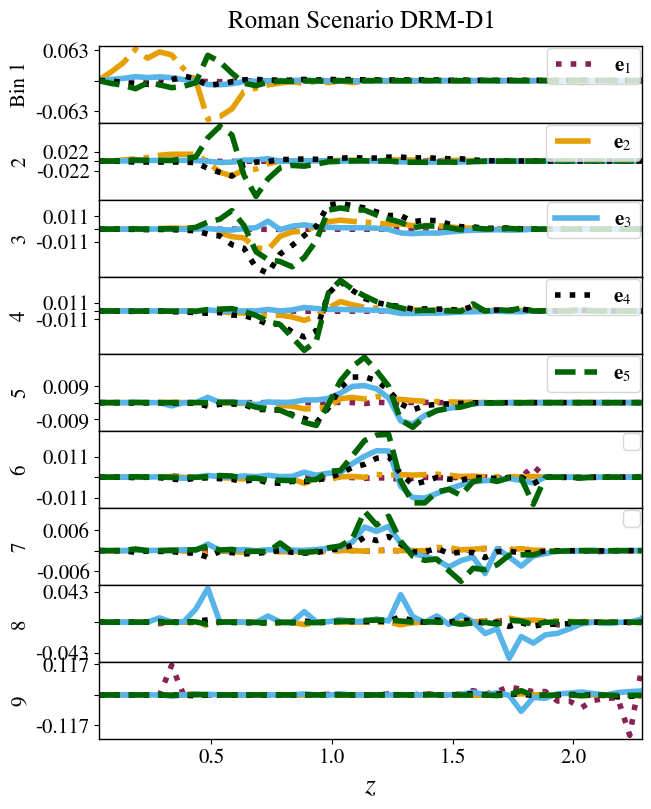

In [95]:
plt.figure()

D_vecs = fisher_results["D"] # decoding matrix

fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(7, 9),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})

pcis = [0,1,2,3,4]

colors=['#882255',"#E69F00","#56B4E9","#1b5f6f"]

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
formatter.set_scientific(True)
tick_label_formatter = FuncFormatter(lambda y, _: f"{y:.0f}") 

for k, ax in enumerate(axes):  # k = tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    e1 = D_vecs[start:end, pcis[0]]
    e2 = D_vecs[start:end, pcis[1]]
    e3 = D_vecs[start:end, pcis[2]]
    e4 = D_vecs[start:end,3]
    e5 = D_vecs[start:end,4]

    max_y = np.max([np.max(e1), np.max(e2), np.max(e3)])
    min_y = np.min([np.min(e1), np.min(e2), np.min(e3)])
    d_y = (max_y - min_y) / 2.3
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_visible(k == 0)

    def format_ticks(y, _):
        if np.isclose(y, 0.0):
            return ''
        else:
            return f'{y:.3f}'
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))

    ks = [0,1,2,3,4,5,6]
    ax.plot(z, e1, c=colors[0], lw=4, ls=':', label=r'$\mathbf{e}$'+rf'$_{{{pcis[0]+1}}}$' if k==ks[0] else None)
    ax.plot(z, e2, c=colors[1], lw=4, ls='-.', label=r'$\mathbf{e}$'+rf'$_{{{pcis[1]+1}}}$' if k==ks[1] else None)
    ax.plot(z, e3, c=colors[2], lw=4, ls='-', label=r'$\mathbf{e}$'+rf'$_{{{pcis[2]+1}}}$' if k==ks[2] else None)
    ax.plot(z, e4, c="k", lw=4, ls=':', label=r'$\mathbf{e}$'+rf'$_{{{pcis[3]+1}}}$' if k==ks[3] else None)
    ax.plot(z, e5, c="darkgreen", lw=4, ls='--', label=r'$\mathbf{e}$'+rf'$_{{{pcis[4]+1}}}$' if k==ks[4] else None)

    ax.set_ylabel(f'Bin {k+1}' if k == 0 else f'{k+1}')
    ax.legend(loc='upper right', borderaxespad=.1)

unused_legs = [x for x in range(9) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$',fontsize=20)
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario DRM-D1", y=0.92);
# plt.savefig("PCs123_DRMD1_weighted.pdf")

-2.816508311298538e-12
-1.0009963344326245e-11
4.679645559946266e-12
2.3780296308506532e-12
-5.698646849544575e-12
-4.023626050397855e-14
-6.373124684239118e-14
-1.593438041561611e-14
-1.140527830598842e-14
-5.579911532826998e-14
-7.826584432629735e-16
6.892984718166045e-15
1.0836058612906374e-13
6.025263838208006e-15
9.660749576614197e-17
6.49043958917283e-19
-7.112146022938623e-16
3.07532506269503e-15
8.50164597466889e-15
1.0190765620281999e-14
1.3142732616187175e-14
-5.825235313648008e-14
-2.3838664874563376e-14
3.351972291312094e-14
3.062925347380174e-14
-1.892220104562914e-14
5.969899867421663e-13
-6.590211944137048e-14
-1.5843454206996427e-12
-2.4784410634914877e-12
-1.4176756990558204e-11
-1.3431519785278567e-11
-1.278022687678515e-10
2.6653142887189674e-10
4.1350874429441076e-08
3.1652714979233873e-07
-1.982617090289223e-06
5.277001699482281e-07
-1.5847371357398214e-06
-4.32786405774651e-06
-4.5165949445862e-06
-5.724593420182271e-06
3.0985897683504654e-06
1.6847676121427898e-0

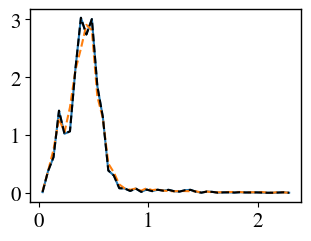

In [84]:
nbar_path     = f'{cocoa_path}/projects/roman_real/data/sc1bd4/nbar_sc1bd4.nz'
nz_fid_path   = f'{cocoa_path}/projects/roman_real/data/sc1bd4/nz_sc1bd4r991213.nz'
nz_fid     = np.genfromtxt(nz_fid_path)
nbar       = np.genfromtxt(nbar_path)
z          = nz_fid[:,0]
ndiff      = nz_fid[:,1:] - nbar[:,1:] 
npcs_used  = 414

params_values = {}
Dvec  = fisher_results["D"] # decoding matrix
Cnvec = fisher_results["Cnvec"] # eigvecs of the covariance matrix of the nzs
Cnval = fisher_results["Cnval"] # eigvecs of the covariance matrix of the nzs

Vec = Cnvec

for i in range(npcs_used):
    alpi = np.dot(ndiff.T.flatten(),Vec[:,i])
    print(alpi)
    params_values.update({f"roman_alpha_{i+1}": alpi})

alphas = np.array([params_values.get("roman_alpha_"+str(i+1)) for i in range(npcs_used)])
correction = (alphas * Vec).sum(axis=1)

s = nbar[:,1:].shape
z = nbar[:,0]
nz_model = nbar[:,1:].T.flatten() + correction
nz_model = nz_model.reshape(s[::-1]).T
nz_model = np.column_stack((z,nz_model))
plt.plot(z,nz_model[:,1])
plt.plot(z,nbar[:,1],ls="--")
plt.plot(z,nz_fid[:,1],ls="--",c="k")

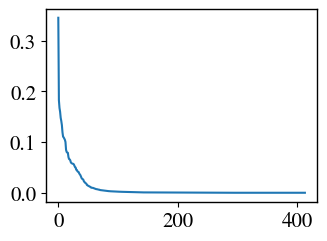

In [87]:
plt.plot(range(len(Cnval)),Cnval[::-1])

fixing cov


/tmp/ipykernel_1033866/3776551322.py:225: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)


fixing cov
fixing cov
fixing cov
fixing cov

--------------------------------------------------
Weighted (F≠I): ∑λ_i^G: 25.32711411802536
Unweighted (F=I): ∑λ_i^G: 3.9872498787671913
∑λ_i: 3.987249878767192


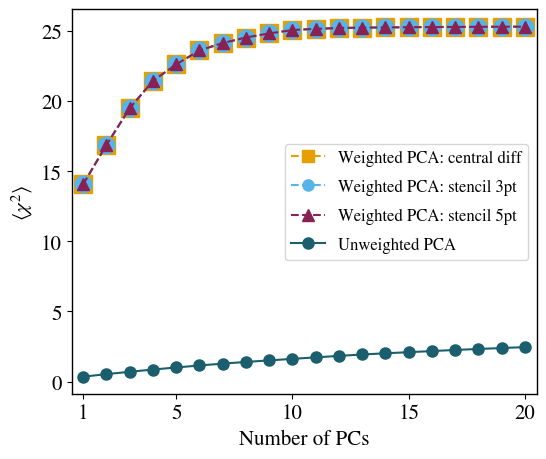

In [34]:
plt.subplots(figsize=(6,5))

maskers = ['s','o','^','*']
many=20
ms=8
colors=['#E69F00',"#56B4E9","#882255","#1b5f6f"]

ss_central_diff = fisher_outs('0.0001','central_diff',weights=True)["ss"]
ss_stencil_3pt = fisher_outs('0.0001','stencil_3pt',weights=True)["ss"]
ss_stencil_5pt = fisher_outs('1.000000e-03','stencil_5pt',weights=True)["ss"]
ss_unw = fisher_outs('1.000000e-03','stencil_5pt',weights=False)["ss"]

x_range = np.arange(1, len(ss_stencil_5pt)+1)[:many]
# x_range = np.arange(len(ss_stencil_5pt))[:many]

plt.plot(x_range,np.cumsum(ss_central_diff)[:many],marker=maskers[0],markersize=ms+5,color=colors[0],ls='--',label=f'Weighted PCA: central diff') 
plt.plot(x_range,np.cumsum(ss_stencil_3pt)[:many],marker=maskers[1],markersize=ms+4,color=colors[1],ls='--',label=f'Weighted PCA: stencil 3pt') 
plt.plot(x_range,np.cumsum(ss_stencil_5pt)[:many],marker=maskers[2],markersize=ms,color=colors[2],ls='--',label=f'Weighted PCA: stencil 5pt') 

plt.plot(x_range,np.cumsum(ss_unw)[:many],marker='o',color=colors[3],markersize=ms,label="Unweighted PCA")

# plt.yscale('log')
plt.xlim(np.min(x_range) - 0.5, np.max(x_range) + 0.5)

from matplotlib.lines import Line2D

# Get current axis and its legend handles/labels
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
plt.xticks([1, 5, 10, 15, 20])

# Rebuild proxy handles with adjusted markersizes just for legend
proxy_handles = []
for h, label in zip(handles, labels):
    if label in ["Weighted PCA: central diff", "Weighted PCA: stencil 3pt"]:
        msize = ms  # override marker size in legend
    else:
        msize = h.get_markersize()  # keep original size

    proxy = Line2D(
        [0], [0],
        label=label,
        linestyle=h.get_linestyle(),
        color=h.get_color(),
        marker=h.get_marker(),
        markersize=msize,
    )
    proxy_handles.append(proxy)

# Final legend with proxies
ax.legend(handles=proxy_handles, labels=labels, loc='best', fontsize=12)

plt.xlabel("Number of PCs")
plt.ylabel(r"$\langle\chi^2\rangle$");

####################################################
####################################################
ss_w   = fisher_outs(weights=True)["ss"]
ss_unw = fisher_outs(weights=False)["ss"]

Cnval_w   = fisher_outs(weights=True)["Cnval"]
Cnval_unw = fisher_outs(weights=False)["Cnval"]

print()
print("-----"*10)

print("Weighted (F≠I): ∑λ_i^G:",np.sum(ss_w))
print("Unweighted (F=I): ∑λ_i^G:",np.sum(ss_unw))

print("∑λ_i:",np.sum(Cnval_w))
####################################################
####################################################

# plt.savefig("chi2_versus_npcs.pdf")

fixing cov


/tmp/ipykernel_1286931/3776551322.py:225: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)


fixing cov
fixing cov
------------------------------------------------------------
cumulative_explained_variance_ratio[11]: 0.9960944577303382
------------------------------------------------------------


<Figure size 350x250 with 0 Axes>

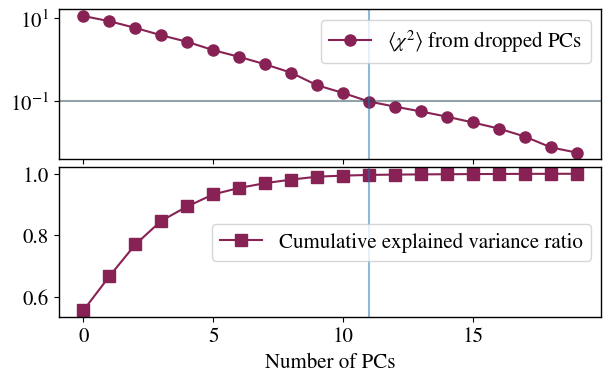

In [47]:
plt.figure()
from matplotlib.lines import Line2D

U_vecs = fisher_results["U"] # eigenvectors

fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, sharey=False,figsize=(7, 4),
                        gridspec_kw={'wspace':0.0, 'hspace':0.05})

maskers = ['s','*','o','*']
many=20
ms=8
colors=['#E69F00',"#1b5f6f","#882255","#56B4E9"]

ss_central_diff = fisher_outs('0.0001','central_diff',weights=True)["ss"]
ss_stencil_3pt = fisher_outs('0.0001','stencil_3pt',weights=True)["ss"]
ss_stencil_5pt = fisher_outs('1.000000e-03','stencil_5pt',weights=True)["ss"]

x_range = np.arange(1, len(ss_stencil_5pt)+1)[:many]
x_range1 = np.arange(0, len(ss_stencil_5pt))[:many]

chi2_from_dropped_pcs = np.sum(ss_stencil_5pt)-np.cumsum(ss_stencil_5pt)[:many]
cumulative_explained_variance_ratio = np.cumsum(ss_stencil_5pt)[:many]/np.sum(ss_stencil_5pt)

axes[0].plot(x_range1,chi2_from_dropped_pcs,marker=maskers[2],markersize=ms,color=colors[2],ls='-',label=r"$\langle\chi^2\rangle$ from dropped PCs") 
axes[1].plot(x_range1,cumulative_explained_variance_ratio,marker=maskers[0],markersize=ms,color=colors[2],ls='-',label="Cumulative explained variance ratio") 

thr=0.1
pt=11
axes[0].axhline(thr,  color = '#264653', alpha = 0.5)
axes[1].axvline(pt,  color = 'C0', alpha = 0.5)
axes[0].axvline(pt,  color = 'C0', alpha = 0.5)
print("---"*20)
print(f"cumulative_explained_variance_ratio[{pt}]:",cumulative_explained_variance_ratio[pt])
print("---"*20)

plt.xlabel("Number of PCs")
axes[0].legend(loc="upper right")
axes[1].legend(loc="center right")
axes[0].set_yscale("log")
# plt.savefig("npcs_vs_retained_dropped_explained_chi2.pdf")

<Figure size 350x250 with 0 Axes>

<Figure size 350x250 with 0 Axes>

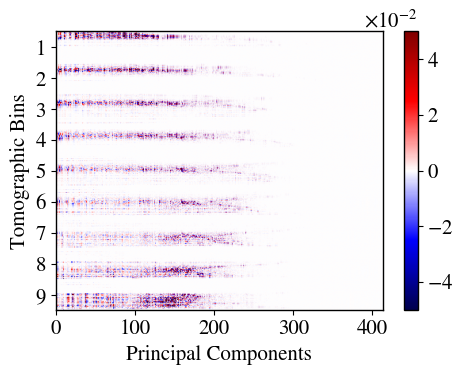

In [78]:
# PLOT PCs, encoding E, decoding D and linear operator X=DE
plt.figure()
possible_scenarios = ['sc1bd4','sc1bd5','sc1bd6','sc1bd7','sc2bd4','sc2bd5','sc2bd6','sc2bd7','sc3bd4','sc3bd5','sc3bd7']

sc = 'sc2bd4'
D = np.genfromtxt(f"{cocoa_path}/jacobian_outs/stencil_5pt_{sc}/D_{sc}_weights1.txt")

plt.figure()
fig, ax = plt.subplots(figsize=(5, 4))
vmax = np.max([abs(np.min(D)),abs(np.max(D))])
im = plt.imshow(D, cmap='seismic',vmin=-.05,vmax=.05,aspect='auto')

# Add colorbar with scientific notation
cbar = fig.colorbar(im, ax=ax, shrink=1)  # adjusted shrink for visibility
cbar.formatter = ScalarFormatter(useMathText=True)
cbar.formatter.set_powerlimits((-2, 2))
cbar.update_ticks()

# Define bin info
n_bins = 9
z_points_per_bin = 46
bin_centers = [i * z_points_per_bin + z_points_per_bin // 2 for i in range(n_bins)]
bin_labels = [f'{i+1}' for i in range(n_bins)]

# Set yticks and labels
plt.yticks(bin_centers, bin_labels)

# Optional: set axis labels
plt.xlabel('Principal Components')
plt.ylabel('Tomographic Bins')
# plt.title(r'Decoding Matrix')
plt.tight_layout()
# plt.savefig('D_r991213.pdf')

/tmp/ipykernel_2938023/1843682173.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


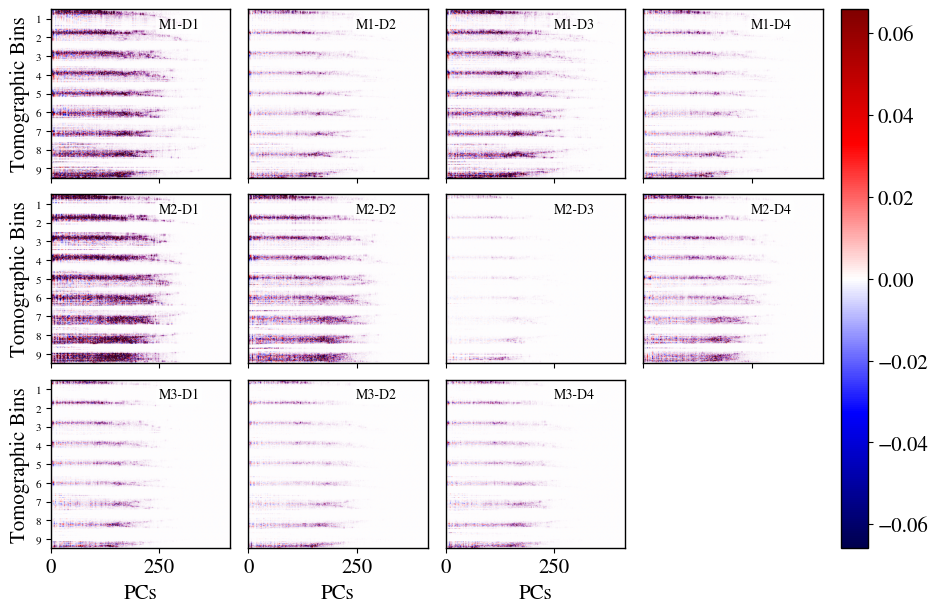

In [106]:
import numpy as np
import matplotlib.pyplot as plt

possible_scenarios = {
    'sc1bd4':'M1-D1','sc1bd5':'M1-D2','sc1bd6':'M1-D3','sc1bd7':'M1-D4',
    'sc2bd4':'M2-D1'  ,'sc2bd5':'M2-D2'  ,'sc2bd6':'M2-D3'  ,'sc2bd7':'M2-D4',
    'sc3bd4':'M3-D1'  ,'sc3bd5':'M3-D2'  ,'sc3bd7':'M3-D4'}

# Setup figure with 3x4 subplots
fig, axes = plt.subplots(
    nrows=3, ncols=4, figsize=(12, 7),
    sharex=True, sharey=False,
    gridspec_kw={'wspace':0.10, 'hspace':0.10}
)

# Flatten axes for easier iteration
axes = axes.flatten()

n_bins = 9
z_points_per_bin = 46
bin_centers = [i * z_points_per_bin + z_points_per_bin // 2 for i in range(n_bins)]
bin_labels = [f'{i+1}' for i in range(n_bins)]

for i, sc in enumerate(possible_scenarios.keys()):
    ax = axes[i]
    
    # Load decoding matrix
    D = np.genfromtxt(f"{cocoa_path}/jacobian_outs/stencil_5pt_{sc}/D_{sc}_weights1.txt")
    
    # Symmetric color scaling
    vmax = np.max([abs(np.min(D)), abs(np.max(D))])
    
    # Plot matrix
    im = ax.imshow(D, cmap='seismic', vmin=-vmax**3, vmax=vmax**3, aspect='auto')
    
    # y-axis ticks: only label leftmost column to avoid clutter
    if i % 4 == 0:
        ax.set_yticks(bin_centers)
        ax.set_yticklabels(bin_labels, fontsize=8)
        ax.set_ylabel("Tomographic Bins")
    else:
        ax.set_yticks([])
        # pass
    
    # x-axis ticks: only label bottom row
    if i // 4 == 2:
        ax.set_xlabel("PCs")
    else:
        # ax.set_xticks([])
        pass
    
    ax.text(
        0.6, 0.95, possible_scenarios[sc], transform=ax.transAxes,
        fontsize=10, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none")
    )

# Hide unused subplot (last one, since 12 slots but 11 scenarios)
if len(possible_scenarios.keys()) < len(axes):
    axes[-1].axis("off")

# Add a single colorbar for the whole figure
cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=1, pad=0.02)
# cbar.set_label("Decoding Matrix Value")

# fig.suptitle(r"Decoding Matrices ($\mathbf{U}$) across Roman scenarios", fontsize=12, y=0.94)

plt.tight_layout()
plt.savefig("decoding_matrices_across_roman_scenarios.pdf")

/tmp/ipykernel_3449279/1038041568.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', borderaxespad=.1)


(0.035, 2.2849999999999997)

<Figure size 350x250 with 0 Axes>

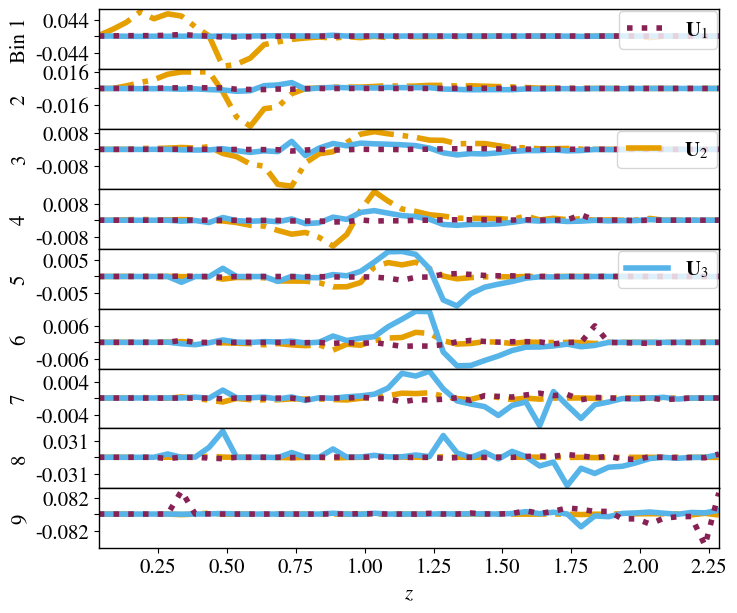

In [13]:
plt.figure()
nbar = f'{cocoa_path}/cocoa_photoz/n_nbar_ndiff_covndiff/nbar_sc1b_d4.nz'
z = np.genfromtxt(nbar)[:,0]

Nt=9
Nz=len(z)
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})

pcis = [0,1,2]

sc='sc1bd4'
D = np.genfromtxt(f"{cocoa_path}/jacobian_outs/stencil_5pt_{sc}/D_{sc}_weights1.txt")
# D = np.genfromtxt(f"{cocoa_path}/projects/roman_real/data/{sc}/D_{sc}_weights1.txt")

colors=['#882255',"#E69F00","#56B4E9","#1b5f6f"]

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
formatter.set_scientific(True)
tick_label_formatter = FuncFormatter(lambda y, _: f"{y:.0f}") 

for k, ax in enumerate(axes):  # k = tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    e1 = D[start:end, pcis[0]]
    e2 = D[start:end, pcis[1]]
    e3 = D[start:end, pcis[2]]

    max_y = np.max([np.max(e1), np.max(e2), np.max(e3)])
    min_y = np.min([np.min(e1), np.min(e2), np.min(e3)])
    d_y = (max_y - min_y) / 3.3
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_visible(k == 0)

    def format_ticks(y, _):
        if np.isclose(y, 0.0):
            return ''
        else:
            return f'{y:.3f}'
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))

    ks = [0, 2, 4]
    # ax.plot(z, e2, c=colors[1], lw=4, ls='-.', label=r'$\mathbf{e}$'+rf'$_{{{pcis[1]+1}}}$' if k==ks[1] else None)
    # ax.plot(z, e3, c=colors[2], lw=4, ls='-', label=r'$\mathbf{e}$'+rf'$_{{{pcis[2]+1}}}$' if k==ks[2] else None)
    # ax.plot(z, e1, c=colors[0], lw=4, ls=':', label=r'$\mathbf{e}$'+rf'$_{{{pcis[0]+1}}}$' if k==ks[0] else None)
    ax.plot(z, e2, c=colors1[1], lw=4, ls='-.', label=r'$\mathbf{U}$'+rf'$_{{{pcis[1]+1}}}$' if k==ks[1] else None)
    ax.plot(z, e3, c=colors1[2], lw=4, ls='-', label=r'$\mathbf{U}$'+rf'$_{{{pcis[2]+1}}}$' if k==ks[2] else None)
    ax.plot(z, e1, c=colors1[3], lw=4, ls=':', label=r'$\mathbf{U}$'+rf'$_{{{pcis[0]+1}}}$' if k==ks[0] else None)

    ax.set_ylabel(f'Bin {k+1}' if k == 0 else f'{k+1}')
    ax.legend(loc='upper right', borderaxespad=.1)

unused_legs = [x for x in range(9) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
# fig.suptitle(rf"Roman Scenario DRM-D1", y=0.92);
# plt.savefig("PCs123_DRMD1_weighted.pdf")

/tmp/ipykernel_1101001/2236383895.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', borderaxespad=.1, fontsize=13)
/tmp/ipykernel_1101001/2236383895.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


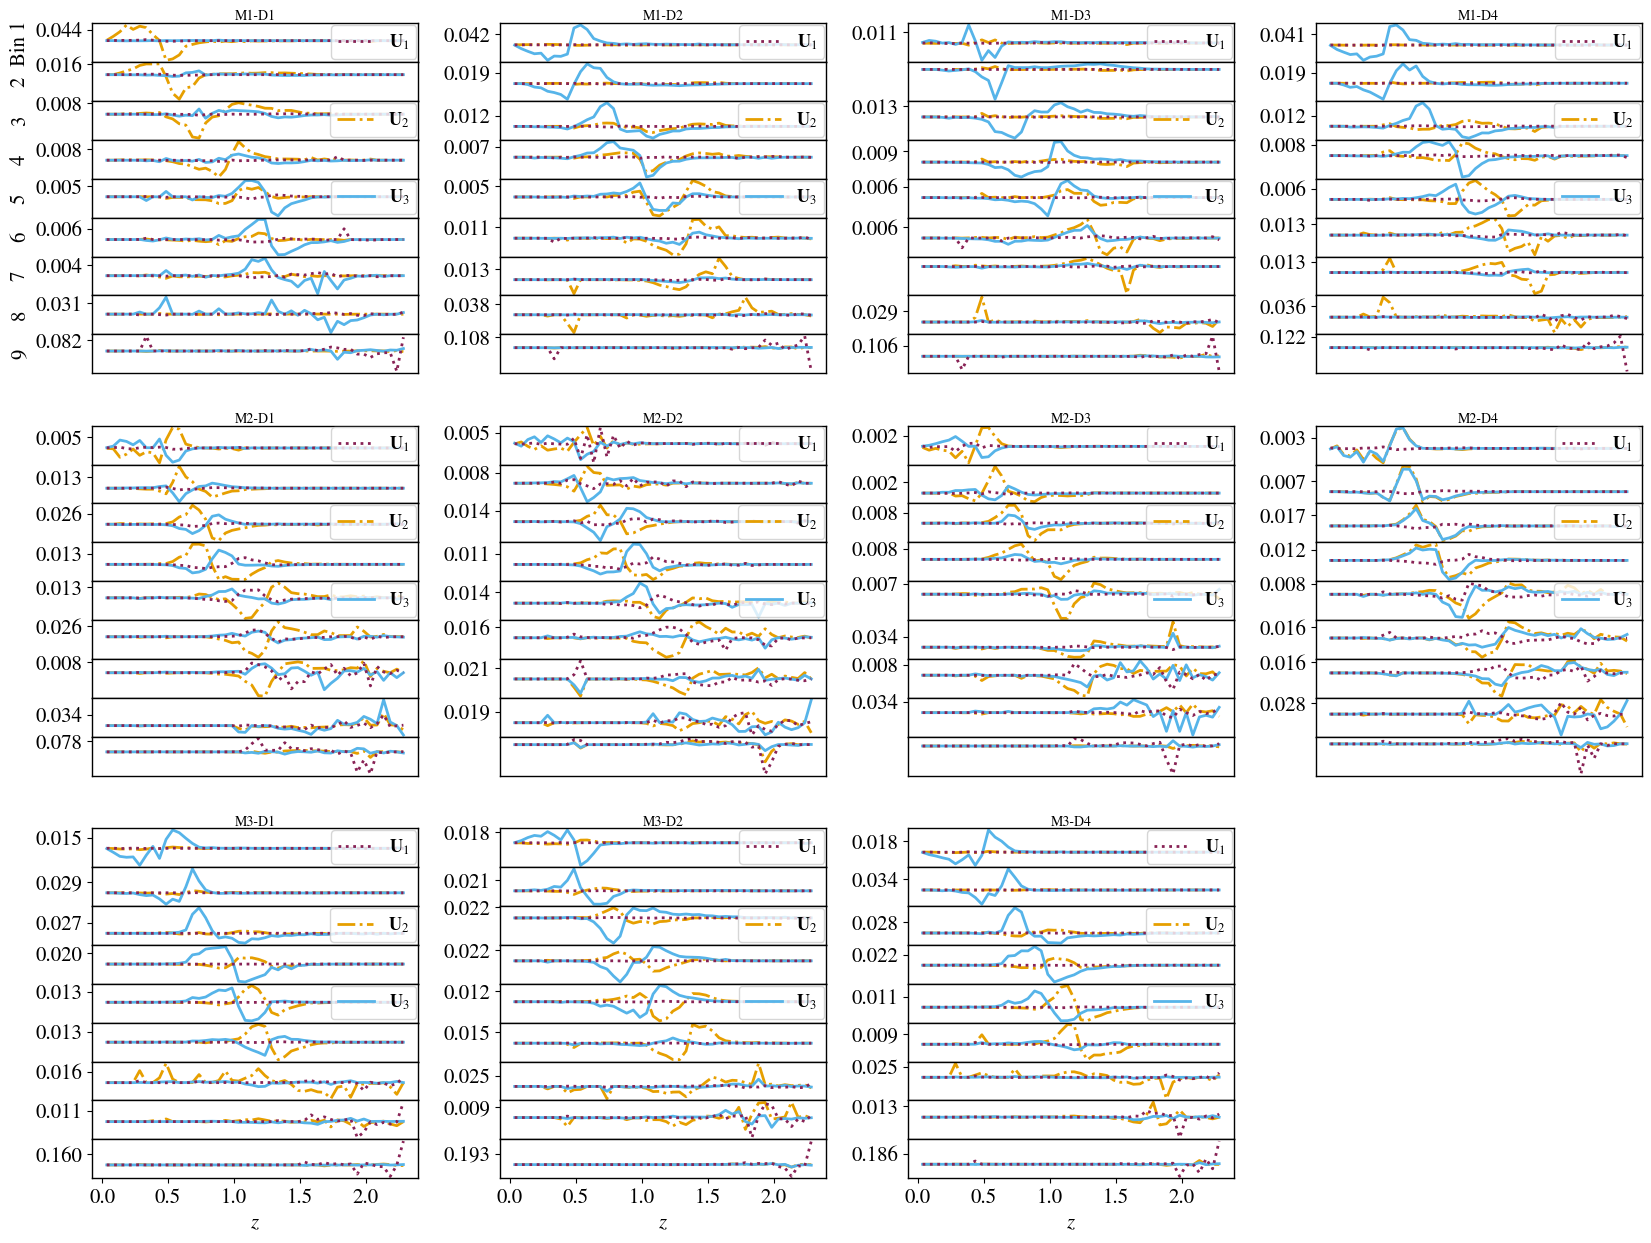

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter
import matplotlib.gridspec as gridspec

cocoa_path = os.getcwd()
nbar_path  = f'{cocoa_path}/projects/roman_real/data/sc1bd4/nbar_sc1bd4.nz'
nbar       = np.genfromtxt(nbar_path)
z = nbar[:,0]
Nz = len(z)

possible_scenarios = {
    'sc1bd4':'M1-D1','sc1bd5':'M1-D2','sc1bd6':'M1-D3','sc1bd7':'M1-D4',
    'sc2bd4':'M2-D1'  ,'sc2bd5':'M2-D2'  ,'sc2bd6':'M2-D3'  ,'sc2bd7':'M2-D4',
    'sc3bd4':'M3-D1'  ,'sc3bd5':'M3-D2'  ,'sc3bd7':'M3-D4'
}

Nt = 9
pcis = [0,1,2]
colors=['#882255',"#E69F00","#56B4E9","#1b5f6f"]

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
formatter.set_scientific(True)

# Outer figure (3x4 grid of scenarios)
fig = plt.figure(figsize=(20, 15))
outer = gridspec.GridSpec(3, 4, wspace=0.25, hspace=0.15)

for i, (sc, label) in enumerate(possible_scenarios.items()):
    row, col = divmod(i, 4)
    inner = gridspec.GridSpecFromSubplotSpec(
        Nt, 1, subplot_spec=outer[row, col], hspace=0.0
    )

    # Load z
    nbar_path = f"{cocoa_path}/projects/roman_real/data/{sc}/nbar_{sc}.nz"
    nbar = np.genfromtxt(nbar_path)
    z = nbar[:,0]
    Nz = len(z)

    # Load PCs
    D = np.genfromtxt(f"{cocoa_path}/jacobian_outs/stencil_5pt_{sc}/D_{sc}_weights1.txt")

    ks = [0, 2, 4]  # bins with legends
    axes = []
    for k in range(Nt):
        ax = plt.Subplot(fig, inner[k])
        fig.add_subplot(ax)
        axes.append(ax)
        if k > 0:
            ax.sharex(axes[0])  # share x with first axi

        start, end = Nz*k, Nz*(k+1)
        e1 = D[start:end, pcis[0]]
        e2 = D[start:end, pcis[1]]
        e3 = D[start:end, pcis[2]]

        # scale ticks
        max_y = np.max([np.max(e1), np.max(e2), np.max(e3)])
        min_y = np.min([np.min(e1), np.min(e2), np.min(e3)])
        d_y = (max_y - min_y) / 3.3
        # ax.set_yticks([-d_y, 0, +d_y])
        ax.set_yticks([+d_y])
        ax.yaxis.set_major_formatter(FuncFormatter(
            lambda y,_: '' if np.isclose(y,0.0) else f'{y:.3f}'
        ))

        # plot PCs
        ax.plot(z, e2, c=colors[1], lw=2, ls='-.',
                label=r'$\mathbf{U}$'+rf'$_{{{pcis[1]+1}}}$' if k==ks[1] else None)
        ax.plot(z, e3, c=colors[2], lw=2, ls='-',
                label=r'$\mathbf{U}$'+rf'$_{{{pcis[2]+1}}}$' if k==ks[2] else None)
        ax.plot(z, e1, c=colors[0], lw=2, ls=':',
                label=r'$\mathbf{U}$'+rf'$_{{{pcis[0]+1}}}$' if k==ks[0] else None)

        if k==0 and sc=='sc1bd4':
            ax.set_ylabel(f'Bin {k+1}')
        elif sc=='sc1bd4':
            ax.set_ylabel(f'{k+1}')
        if k==0:
            ax.set_title(label, fontsize=10, pad=2)
        # if k==Nt-1 and (sc=='sc3bd4' or sc=='sc3bd5' or sc=='sc3bd7'):
        #     ax.set_xlabel(r'$z$')
        if k != Nt-1:
            ax.tick_params(labelbottom=False)   
        #     ax.set_xticklabels([])
        if row == 2 and col in [0, 1, 2]:  # bottom row, last three subplots
            ax.set_xlabel(r'$z$')
        else:
            ax.set_xticks([])  # remove x-ticks and numbers        

        ax.legend(loc='upper right', borderaxespad=.1, fontsize=13)

    # remove unused legends
    unused_legs = [x for x in range(Nt) if x not in ks]
    for j in unused_legs:
        axes[j].get_legend().remove()

plt.tight_layout()
# plt.savefig("PCs123_all_roman_scenarios.pdf")

28.0 9.799999999999999
28.0 9.799999999999999
28.0 9.799999999999999


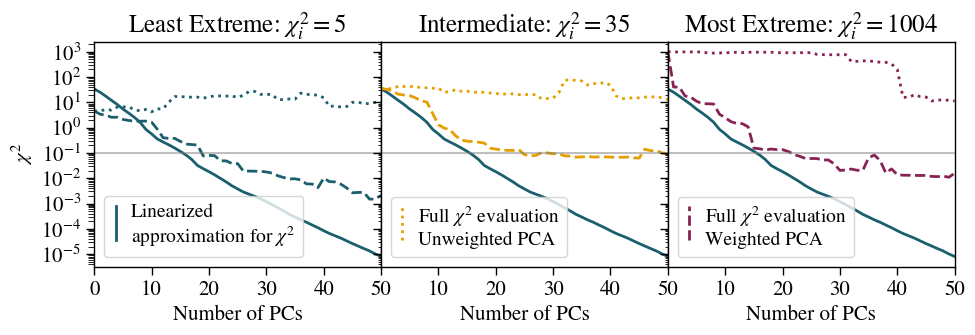

In [ ]:
# χ² versus # of PCs
# Linearized approaximation for χ² versus full χ² evaluation    
import matplotlib.ticker as mticker

possible_scenarios = ['sc1bd4','sc1bd5','sc1bd6','sc1bd7','sc2bd4','sc2bd5','sc2bd6','sc2bd7','sc3bd4','sc3bd5','sc3bd7']
sc = possible_scenarios[0]
ss_rev = np.genfromtxt(f"{cocoa_path}/jacobian_outs/stencil_5pt_{sc}/ssrev_{sc}_weights1.txt")

# le = least extreme
chi2_w1_le = np.genfromtxt(f"{cocoa_path}/chi2_vs_npcs_weighted/chi2_vs_npcs_Model_sc1bd4_Fiducial_sc1bd4r3233_weights1_first_50PCs.txt",delimiter=',')
chi2_w0_le = np.genfromtxt(f"{cocoa_path}/chi2_vs_npcs_weighted/chi2_vs_npcs_Model_sc1bd4_Fiducial_sc1bd4r3233_weights0_first_50PCs.txt",delimiter=',')

# in = intermediate
chi2_w1_in = np.genfromtxt(f"{cocoa_path}/chi2_vs_npcs_weighted/chi2_vs_npcs_Model_sc1bd4_Fiducial_sc1bd4r0_weights1_first_50PCs.txt",delimiter=',')
chi2_w0_in = np.genfromtxt(f"{cocoa_path}/chi2_vs_npcs_weighted/chi2_vs_npcs_Model_sc1bd4_Fiducial_sc1bd4r0_weights0_first_50PCs.txt",delimiter=',')

# me = most extreme
chi2_w1_me = np.genfromtxt(f"{cocoa_path}/chi2_vs_npcs_weighted/chi2_vs_npcs_Model_sc1bd4_Fiducial_sc1bd4r869_weights1_first_50PCs.txt",delimiter=',')
chi2_w0_me = np.genfromtxt(f"{cocoa_path}/chi2_vs_npcs_weighted/chi2_vs_npcs_Model_sc1bd4_Fiducial_sc1bd4r869_weights0_first_50PCs.txt",delimiter=',')

fig, ax = plt.subplots(nrows=1, ncols=3, sharex=False, sharey=True,figsize=(10, 3.6),
                        gridspec_kw={'wspace':0, 'hspace':0})

ax[0].plot(chi2_w1_le[:,0], ss_rev[:51],     color='#1b5f6f', ls='-',  lw=2, label='Linearized\n' + r'approximation for $\chi^2$')
ax[0].plot(chi2_w1_le[:,0], chi2_w0_le[:,1], color='#1b5f6f', ls=':', lw=2)
ax[0].plot(chi2_w1_le[:,0], chi2_w1_le[:,1], color='#1b5f6f', ls='--', lw=2)

ax[1].plot(chi2_w1_le[:,0], ss_rev[:51],     c='#1b5f6f', ls='-',  lw=2)
ax[1].plot(chi2_w1_le[:,0], chi2_w0_in[:,1], c='#E69F00', ls=':',  lw=2, label=r'Full $\chi^2$ evaluation' + '\nUnweighted PCA')
ax[1].plot(chi2_w1_le[:,0], chi2_w1_in[:,1], c='#E69F00', ls='--', lw=2)

ax[2].plot(chi2_w1_le[:,0], ss_rev[:51],      c='#1b5f6f', ls='-',  lw=2)
ax[2].plot(chi2_w1_le[:,0], chi2_w0_me[:,1], c='#882255', ls=':',  lw=2)
ax[2].plot(chi2_w1_le[:,0], chi2_w1_me[:,1], c='#882255', ls='--', lw=2, label=r'Full $\chi^2$ evaluation' + '\nWeighted PCA')

ax[0].set_yscale('log')
ax[1].set_yscale('log')

ax[0].yaxis.set_major_locator(mticker.LogLocator(base=10.0, subs=[1.0], numticks=10))
ax[0].yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10.0, labelOnlyBase=False))
ax[0].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2,10), numticks=12))
ax[0].tick_params(which='major', length=7)
ax[0].tick_params(which='minor', length=4)

xticks = [0,10,20,30,40,50]
ax[0].set_xticks([0,10,20,30,40,50]);
ax[1].set_xticks([10,20,30,40,50]);
ax[2].set_xticks([10,20,30,40,50]);

for a in ax:
    a.tick_params(axis='x', length=6, width=1) 
    a.tick_params(axis='y', length=6, width=1)

ax[0].set_title(r'Least Extreme: $\chi_i^2=5$')
ax[1].set_title(r'Intermediate: $\chi_i^2=35$')
ax[2].set_title(r'Most Extreme: $\chi_i^2=1004$')

from matplotlib.legend_handler import HandlerLine2D
class HandlerVerticalLine(HandlerLine2D):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        line = plt.Line2D([width/10, width/10], [-5, height*2],
                          color=orig_handle.get_color(),
                          linestyle=orig_handle.get_linestyle(),
                          linewidth=orig_handle.get_linewidth(),
                          transform=trans)
        print(width,height)
        return [line]

# ax[0].legend(loc='lower left',fontsize=12)
# ax[1].legend(loc='lower left',fontsize=12)
# ax[2].legend(loc='lower left',fontsize=12)
ax[0].legend(handler_map={plt.Line2D: HandlerVerticalLine()},
            handletextpad=-1,
            fontsize=14, loc='lower left')
ax[1].legend(handler_map={plt.Line2D: HandlerVerticalLine()},
            handletextpad=-1,
            fontsize=14, loc='lower left')
ax[2].legend(handler_map={plt.Line2D: HandlerVerticalLine()},
            handletextpad=-1,
            fontsize=14, loc='lower left')

ax[0].set_xlabel('Number of PCs')
ax[1].set_xlabel('Number of PCs')
ax[2].set_xlabel('Number of PCs')
ax[0].set_ylabel(r'$\chi^2$')
ax[0].hlines(y=.1,xmin=0,xmax=50,color='gray',alpha=.5)
ax[1].hlines(y=.1,xmin=0,xmax=50,color='gray',alpha=.5)
ax[2].hlines(y=.1,xmin=0,xmax=50,color='gray',alpha=.5)
ax[0].set_xlim(0,50)
ax[1].set_xlim(0,50)
ax[2].set_xlim(0,50)
plt.tight_layout()
# plt.savefig("comparison_least_intermediate_most_extreme.pdf")

least extreme, chi2_i: 12.142506749941921
intermediate, chi2_i: 19.426074295190816
most extreme, chi2_i: 1020.6846481286101
mean, chi2_i: 13.608583665001033


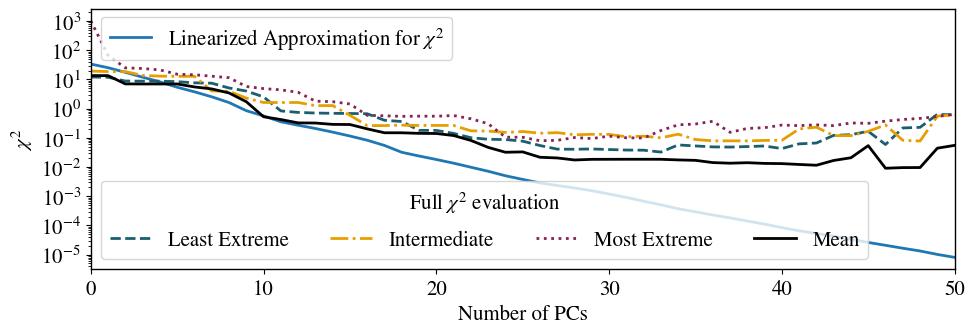

In [15]:
plt.figure(figsize=(10, 3.6))

chi2_r3233 = np.genfromtxt(f"{cocoa_path}/chi2_vs_npcs_weighted/chi2_vs_npcs_Model_sc1bd5_Fiducial_sc1bd4r3233_weights1_first_50PCs.txt",delimiter=',')
chi2_r0    = np.genfromtxt(f"{cocoa_path}/chi2_vs_npcs_weighted/chi2_vs_npcs_Model_sc1bd5_Fiducial_sc1bd4r0_weights1_first_50PCs.txt"   ,delimiter=',')
chi2_r869  = np.genfromtxt(f"{cocoa_path}/chi2_vs_npcs_weighted/chi2_vs_npcs_Model_sc1bd5_Fiducial_sc1bd4r869_weights1_first_50PCs.txt" ,delimiter=',')
chi2_rmean = np.genfromtxt(f"{cocoa_path}/chi2_vs_npcs_weighted/chi2_vs_npcs_Model_sc1bd5_Fiducial_sc1bd4rNone_weights1_first_50PCs.txt",delimiter=',')

ss_rev = np.genfromtxt(f"{cocoa_path}/jacobian_outs/stencil_5pt_sc1bd4/ssrev_sc1bd4_weights1.txt")

print("least extreme, chi2_i:",chi2_r3233[:,1][0])
print("intermediate, chi2_i:",chi2_r0[:,1][0])
print("most extreme, chi2_i:",chi2_r869[:,1][0])
print("mean, chi2_i:",chi2_rmean[:,1][0])

plt.semilogy(list(range(len(chi2_r3233))),ss_rev[:51]    ,color="C0",lw=2,ls="-" ,label=r'Linearized Approximation for $\chi^2$')
plt.semilogy(list(range(len(chi2_r3233))),chi2_r3233[:,1],color="#1b5f6f",lw=2,ls="--",label='Least Extreme')
plt.semilogy(list(range(len(chi2_r3233))),chi2_r0[:,1]   ,color="#E69F00",lw=2,ls="-.",label='Intermediate')
plt.semilogy(list(range(len(chi2_r3233))),chi2_r869[:,1] ,color="#882255",lw=2,ls=":" ,label='Most Extreme')
plt.semilogy(list(range(len(chi2_r3233))),chi2_rmean[:,1],color="black"  ,lw=2,ls="-" ,label='Mean')

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

# Separate handles: first is linearized, rest are full χ²
handles_bottom = [handles[0]]
labels_bottom = [labels[0]]
handles_top = handles[1:]
labels_top = labels[1:]

# ---- Top legend ----
leg1 = ax.legend(handles_top, labels_top,
                 loc='lower left',
                 ncol=4,
                 title=r'Full $\chi^2$ evaluation',
                 frameon=True,
                 bbox_to_anchor=(0, .0))  # slightly above the plot

# ---- Bottom legend ----
leg2 = ax.legend(handles_bottom, labels_bottom,
                 loc='upper left',
                 bbox_to_anchor=(0, 1.01),
                 frameon=True)

import matplotlib.ticker as mticker
# Proper log tick formatting
ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0, subs=[1.0], numticks=10))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10.0, labelOnlyBase=False))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2,10), numticks=12))

# Add the top legend back manually so both appear
ax.add_artist(leg1)
plt.xlim(0,50)
plt.xlabel("Number of PCs")
plt.ylabel(r"$\chi^2$")
# plt.title(r"Decode: M1-D2, Datavector: M1-D1")
plt.tight_layout()
plt.savefig("comparison_least_intermediate_most_extreme_mix.pdf")

## DES case

### Test 1 - Fix one PC (e.g. PC_1) and plot its slices across the tomographic bins:  
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The principal components are the same, except for a possible sign flip.  
$\text{PC}^1 = \Big[[\text{PC}^1_{1},\text{PC}^1_{2},\cdots,\text{PC}^1_{299}],[\text{PC}^1_{300},\text{PC}^1_{301},\cdots,\text{PC}^1_{598}],1\times[\cdots],[\text{PC}^1_{412},\text{PC}^1_{898},\cdots,\text{PC}^1_{1196}]\Big]$

In [177]:
des_obj = SURVEY('des')
Nz,Nt = des_obj.nz_params()
z,nz = des_obj.get_nzs()

Cn, ndiff = des_obj.cov_of_ndiff() # must call before pcs

eig_vecs, eig_vals = des_obj.pcs('eig')
eih_vecs, eigh_vals = des_obj.pcs('eigh')
svd_vecs, svd_vals = des_obj.pcs('svd')
skl_vecs, skl_vals,\
explained_variance, explained_variance_ratio = des_obj.pcs('sklearn')

<Figure size 350x250 with 0 Axes>

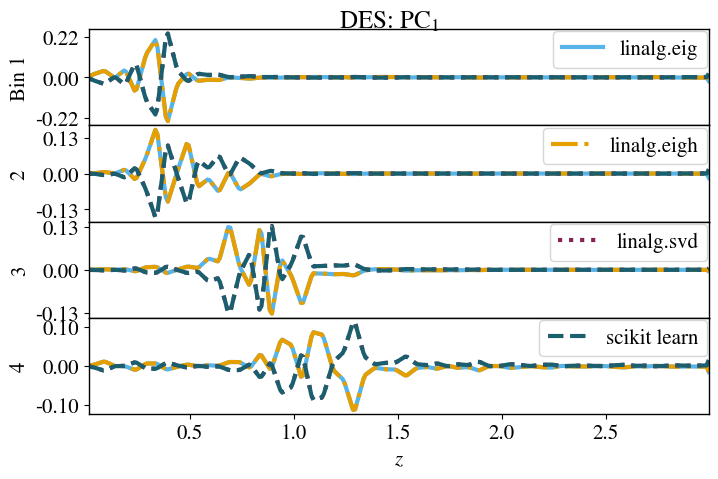

In [178]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 5),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0

colors=['#56B4E9',"#E69F00","#882255","#1b5f6f"]

for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.plot(z, eig_vecs[start:end, pci],c=colors[0],lw=3, ls='-' , label='linalg.eig' if k==0 else None)
    ax.plot(z, eih_vecs[start:end, pci],c=colors[1],lw=3, ls='-.', label='linalg.eigh' if k==1 else None)
    ax.plot(z, svd_vecs[start:end, pci],c=colors[2],lw=3, ls=':', label='linalg.svd' if k==2 else None)
    ax.plot(z, skl_vecs[start:end, pci],c=colors[3],lw=3, ls='--' , label='scikit learn' if k==3 else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"DES: PC$_{{{pci+1}}}$", y=0.92);

### Test 2 - Pick up the first three PCs and plot their slices across the tomographic bins

/tmp/ipykernel_2007691/3076853019.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

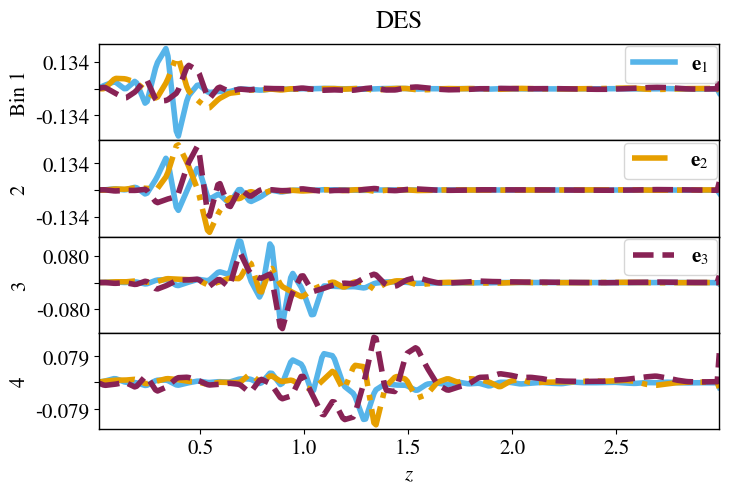

In [179]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 5),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})

pcis = [0,1,2]

colors=['#56B4E9',"#E69F00","#882255","#1b5f6f"]

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
formatter.set_scientific(True)
tick_label_formatter = FuncFormatter(lambda y, _: f"{y:.0f}") 

for k, ax in enumerate(axes):  # k = tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    e1 = eig_vecs[start:end, pcis[0]]
    e2 = eig_vecs[start:end, pcis[1]]
    e3 = eig_vecs[start:end, pcis[2]]

    max_y = np.max([np.max(e1), np.max(e2), np.max(e3)])
    min_y = np.min([np.min(e1), np.min(e2), np.min(e3)])
    d_y = (max_y - min_y) / 3.3
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_visible(k == 0)

    def format_ticks(y, _):
        if np.isclose(y, 0.0):
            return ''
        else:
            return f'{y:.3f}'
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))

    ks = [0, 1, 2]
    ax.plot(z, e1, c=colors[0], lw=4, ls='-', label=r'$\mathbf{e}$'+rf'$_{{{pcis[0]+1}}}$' if k==ks[0] else None)
    ax.plot(z, e2, c=colors[1], lw=4, ls='-.', label=r'$\mathbf{e}$'+rf'$_{{{pcis[1]+1}}}$' if k==ks[1] else None)
    ax.plot(z, e3, c=colors[2], lw=4, ls='--', label=r'$\mathbf{e}$'+rf'$_{{{pcis[2]+1}}}$' if k==ks[2] else None)

    ax.set_ylabel(f'Bin {k+1}' if k == 0 else f'{k+1}')
    ax.legend(loc='upper right', borderaxespad=.1)

unused_legs = [x for x in range(Nt) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"DES", y=0.95);

### Test 3 - Plot the eigenvalues
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The eigenvalues/singular values are the same.

Text(0.5, 0.98, 'DES')

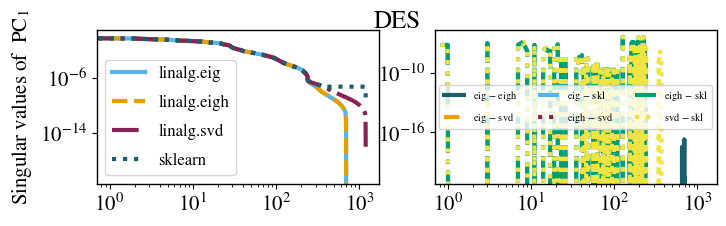

In [180]:
Ms = list(range(Nz*Nt))

fig, axes = plt.subplots(1, 2, figsize=(8, 2), sharex=True)

axes[0].plot(Ms,eig_vals ,c=colors[0],lw=3, ls='-' ,label='linalg.eig')
axes[0].plot(Ms,eigh_vals,c=colors[1],lw=3, ls='--',label='linalg.eigh')
axes[0].plot(Ms,svd_vals ,c=colors[2],lw=3, ls='-.',label='linalg.svd')
axes[0].plot(Ms,skl_vals ,c=colors[3],lw=3, ls=':' ,label='sklearn')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_ylabel(rf'Singular values of  PC$_1$')
axes[0].legend(loc='best',fontsize=12)

axes[1].loglog(Ms,eig_vals-eigh_vals,c=colors1[0],lw=3, ls='-' ,label=r'eig $-$ eigh')
axes[1].loglog(Ms,eig_vals-svd_vals, c=colors1[1],lw=3, ls='--',label=r'eig $-$ svd')
axes[1].loglog(Ms,eig_vals-skl_vals, c=colors1[2],lw=3, ls='-.',label=r'eig $-$ skl')

axes[1].loglog(Ms,eigh_vals-svd_vals,c=colors1[3],lw=3, ls=':' ,label=r'eigh $-$ svd')
axes[1].loglog(Ms,eigh_vals-skl_vals,c=colors1[4],lw=3, ls='-.',label=r'eigh $-$ skl')

axes[1].loglog(Ms,svd_vals-skl_vals, c=colors1[5],lw=3, ls=':',label=r'svd $-$ skl')
axes[1].legend(loc='center',fontsize=7.5,ncol=3)
fig.suptitle('DES')

### Test 4 - Comparing methods to get the PCs: `pcs` vs `getModes`  
The method `pcs` compute the PCs with the standard unweighted PCA. The method `getModes` compute the PCs weighted by the Fisher matrix (see 2506.00758).  
However, if we force $F=I$, then both methods possoes the same eigenvalue, while the eigenvector differ by a factor $\Lambda_n^{1/2}P_M$. Here we show how:  
1. The eigenvalues are the same:  
In Eq. 15 of 2506.00758, if $F=I$, then $G = \Lambda_n = V_G\Lambda_G V_G^T$. However, $\Lambda_n=\text{diag}[\lambda_1^n,\cdots,\lambda_N^n]$ thus $\Lambda_G=\Lambda_n$ and $V_G = I$.
2. The eigenvectors differ by a scaling factor of $\Lambda_n^{1/2}$:  
The decoding matrix (eq 19/20 in 2506.00758) is $D = V_n^T\Lambda_n^{1/2}V_GP_M$. We have $V_G = I$, then $D = V_n^T\Lambda_n^{1/2}P_M$. In particular, if $M=N$, then $P_M = I$ and $D = V_n^T\Lambda_n^{1/2}$.

In [162]:
D = np.identity(Cn.shape[0])

if not des_obj.isPD(D):
    print('fixing cov')
    D=des_obj.nearestPD(D)

X, U, ss, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M = des_obj.getModes(D,Cn,chisq_threshold=0);

/tmp/ipykernel_2007691/3776551322.py:225: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)


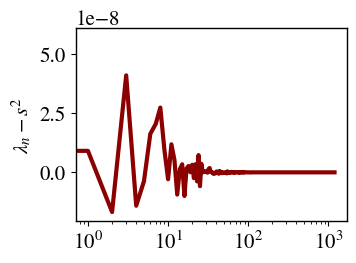

In [163]:
plt.plot(range(len(eig_vals)), eig_vals-ss,ls='-',c='darkred',lw=3)
plt.xscale('log')
plt.ylabel(r'$\lambda_n-s^2$');

/tmp/ipykernel_2007691/1309737692.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right',borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

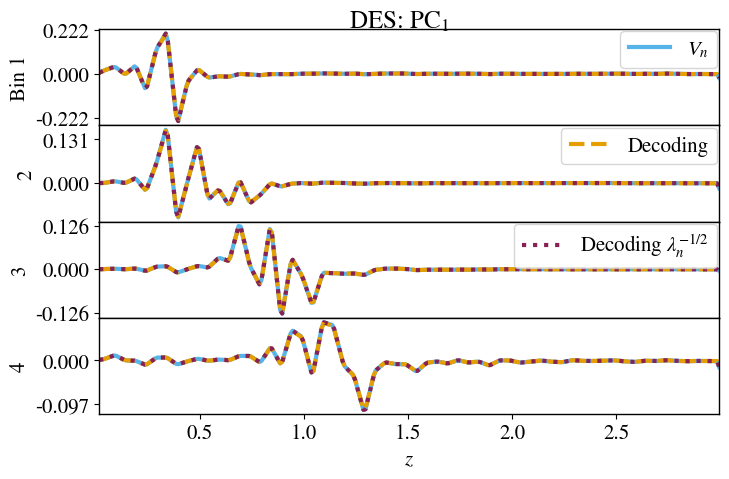

In [164]:
idx = np.argsort(Cnval)[::-1]
decoding_matrix  = Cnvec[:,idx] @ np.diag(Cnval[idx]) # Eq 19/20 in 2506.00758 when M = N and Fisher = Identity
decoding_matrix2 = Cnvec[:,idx] # @ np.diag(Cnval[idx])

plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 5),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0

ks = [0,1,2]

for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    ax.plot(z, eih_vecs[start:end, pci],c='#56B4E9',lw=3, ls='-' , label=r'$V_n$' if k==ks[0] else None)
    ax.plot(z, decoding_matrix[start:end, pci],c='#E69F00',lw=3, ls='--', label='Decoding' if k==ks[1] else None)
    ax.plot(z, decoding_matrix2[start:end, pci],c='#882255',lw=3, ls=':', label=r'Decoding $\lambda_n^{-1/2}$' if k==ks[2] else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

unused_legs = [x for x in range(Nt) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"DES: PC$_1$", y=0.92);

### Test 5 - PCs amplitudes distribution  
The amplitudes $\alpha_i$'s are the projection of the original basis onto PCs: $\alpha_i^{r} =\langle\mathbf{\Delta}^{r},\mathbf{U}_i\rangle = \sum_{t=1}^{N_\text{tomo}}\sum_{k=1}^{N_z}\mathbf{\Delta}^{r}_t(z_k)\cdot \mathbf{U}_i^t(z_k)$  
OBS: Sometimes we use U to denote the PCs. $r$ is the nz realization, i.e., $r=1,\cdots,10^6$.

In [26]:
alphas = ndiff @ eih_vecs

alphas.shape
nEig = np.shape(alphas)[1]
print('nEig: ', nEig)

names = ["alpha%s" %i for i in range(nEig)]
labels = [rf"\alpha_{{{i}}}" for i in range(nEig)]

chains = MCSamples(samples=alphas,names=names,labels=labels)

nEig:  1196


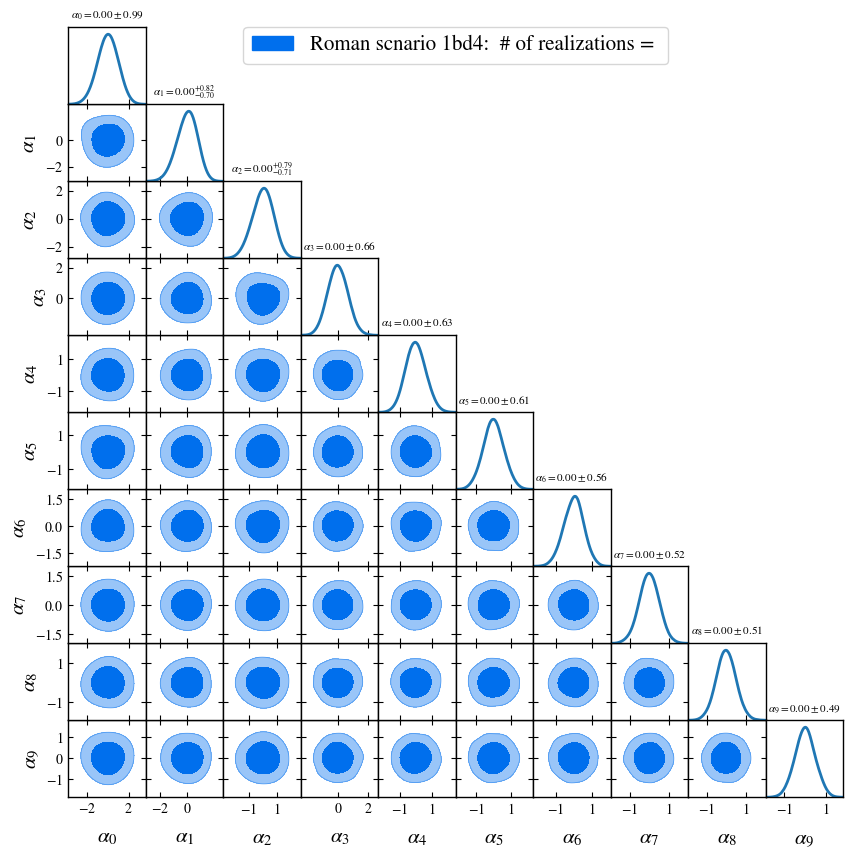

In [27]:
g = plots.get_subplot_plotter(subplot_size=1)
g.settings.title_limit_fontsize = 13
g.settings.legend_fontsize = 20
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 15
g.triangle_plot(chains,
                ["alpha%s" %i for i in range(10)],
                legend_labels=[f"Roman scnario 1bd4:  # of realizations = "],
                filled=True,title_limit=1,
                line_args=[{"ls": "-", "color": "C0",'lw':2}])

# Lets check the function that forward the PCA model of $n(z)$ to CoCoA  
More specifically, to _cosmolike_prototype_interface.py.  
CoCoA needs nz in the form [z, nz_tomo_1, nz_tomo_2, ..., nz_tomo_n] where nz_tomo_i is the nz in the ith tomographic bin.  
The PCs, by construction, are obtained from the concatenation across the tomographic bins of the array nz-nbar    
The PCs are saved in a table with shape (len(PC), # PCs) = (len(z) * Ntomo, len(z) * Ntomo)  
The model: $n(z) = \bar{n}(z)+\alpha_1\cdot\mathbf{PC}_1+\alpha_2\cdot\mathbf{PC}_2+\cdots+\alpha_n\cdot\mathbf{PC}_n$  

In [28]:
nbar_fake = np.array([[1,2,3,4],  [5,6,7,8],   [9,10,11,12]]).T  # 3 tomo bins, 4 redshift bins as provided to cocoa
pcs_fake = np.array([[1,2,3,4,     5,6,7,8,     9,10,11,12],     # PC_1
                     [13,14,15,16, 17,18,19,20, 21,22,23,24]]).T # PC_2

npcs = 2 
U = pcs_fake
params_values = {"fake_alpha_1":2,"fake_alpha_2":1} # fake params from cobaya
alphas = np.array([params_values.get("fake_alpha_"+str(i+1)) for i in range(npcs)])

print(f"{'PC_1':>5} {'PC_2':>5} {'':>1} {'<nz>_1':>7}{'<nz>_2':>7}{'<nz>_3':>7}")

# Max rows needed: max(12 for PCs, 4 for nbar_fake)
max_rows = max(len(pcs_fake), nbar_fake.shape[0])

for i in range(max_rows):
    pc1 = pcs_fake[i,0] if i < len(pcs_fake) else ''
    pc2 = pcs_fake[i,1] if i < len(pcs_fake) else ''
    nz1 = nbar_fake[i,0] if i < nbar_fake.shape[0] else ''
    nz2 = nbar_fake[i,1] if i < nbar_fake.shape[0] else ''
    nz3 = nbar_fake[i,2] if i < nbar_fake.shape[0] else ''
    print(f"{pc1:5} {pc2:5} {nz1:6} {nz2:6} {nz3:6}")

 PC_1  PC_2    <nz>_1 <nz>_2 <nz>_3
    1    13      1      5      9
    2    14      2      6     10
    3    15      3      7     11
    4    16      4      8     12
    5    17                     
    6    18                     
    7    19                     
    8    20                     
    9    21                     
   10    22                     
   11    23                     
   12    24                     


In [29]:
alphas_x_U = (alphas * U)
correction = (alphas * U).sum(axis=1)

print(f"{'α1·PC1':>5} {'α2·PC2':>5}  {'':>2} {'α1·PC1 + α2·PC2':>9}")

for i in range(len(alphas_x_U)):
    α1_x_pc1 = alphas_x_U[i,0] 
    α2_x_pc2 = alphas_x_U[i,1] 
    corr = correction[i] 
    print(f"{α1_x_pc1:5} {α2_x_pc2:5} {corr:15}")

α1·PC1 α2·PC2     α1·PC1 + α2·PC2
    2    13              15
    4    14              18
    6    15              21
    8    16              24
   10    17              27
   12    18              30
   14    19              33
   16    20              36
   18    21              39
   20    22              42
   22    23              45
   24    24              48


In [30]:
s = nbar_fake[:,:].shape # in the code we do self.nbar[:,1:].shape to not cout the redshift column, here isn't necessary
print(s)

(4, 3)


In [31]:
nz_model = nbar_fake[:,:].T.flatten() + correction # in the code we do self.nbar[:,1:].T.flatten() to not count the redshift column, here isn't necessary
nz_model_2 = nz_model.reshape(s[::-1]).T
print('STEP 1: <nbar>:\n',nbar_fake,'\n')
print('STEP 2: <nbar> flattened:',nbar_fake[:,:].T.flatten(),'\n')
print('STEP 3: correction:', correction,'\n')
print('STEP 4: <nbar> flattened + correction:',nz_model,'\n')
print('STEP 5: restore nz in CoCoA table-like format:\n',nz_model_2)

STEP 1: <nbar>:
 [[ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]
 [ 4  8 12]] 

STEP 2: <nbar> flattened: [ 1  2  3  4  5  6  7  8  9 10 11 12] 

STEP 3: correction: [15 18 21 24 27 30 33 36 39 42 45 48] 

STEP 4: <nbar> flattened + correction: [16 20 24 28 32 36 40 44 48 52 56 60] 

STEP 5: restore nz in CoCoA table-like format:
 [[16 32 48]
 [20 36 52]
 [24 40 56]
 [28 44 60]]


# Working in progress - ignore codes from this point

In [ ]:
n_pcs = 2
n_bins = 3
n_z = 4

pcs_reshaped = pcs_fake.reshape(n_pcs, n_bins, n_z)
pcs_reshaped = pcs_reshaped.transpose(0,2,1)  # (n_pcs, n_z, n_bins)
print(pcs_fake)
print(pcs_reshaped)
alphas = np.array([params_values.get(f"fake_alpha_{i+1}") for i in range(n_pcs)])
print(alphas)
pc_sum = np.sum([alpha * pcs_reshaped[i] for i, alpha in enumerate(alphas)], axis=0)
nz_modified = nbar_fake + pc_sum
print(nz_modified)
print(nz_model_2)

In [13]:
def forward_pca(nz_fid,params_values,survey,photoz_pc_file,npc):
    
    if npc == 0:
        return nz_fid

    elif npc > 0:
        U = photoz_pc_file[:,:npc] # Here is not a file, but in CoCoA is. We keep the notation.
        alphas_vals = np.array([params_values.get(survey+"_alpha_"+str(i+1)) for i in range(npc)])
        
        correction = (alphas_vals * U).sum(axis=1)

        s = nz_fid[:,1:].shape # (46,9)
        z = nz_fid[:,0]

        nz_model = nz_fid[:,1:].T.flatten() + correction # |nz_model| ~ 1 for npc << 414 and |alpha| ~< 1.
        nz_model = nz_model.reshape(s[::-1]).T
        nz_model = np.column_stack((z,nz_model))

        return nz_model

# def pca(self, params_values):
#     if self.npcs_nz > 0:
#         #TODO: optimization: if U.shape = nz.shpae, reshape nz will not be necessary
#         alphas = np.array([params_values.get("roman_alpha_"+str(i+1)) for i in range(self.npcs_nz)])
#         correction = (alphas * self.U).sum(axis=1)

#         s = self.nbar[:,1:].shape
#         z = self.nbar[:,0]

#         nz_model = self.nbar[:,1:].T.flatten() + correction
#         nz_model = nz_model.reshape(s[::-1]).T
#         np.savetxt("nz_model_1.nz",nz_model)
#         nz_model = np.column_stack((z,nz_model))
#         return nz_model
#     else:
#         return None

In [ ]:
# Lets assume the amplitudes are drawn a normal distribution
seed = 40 # If the seed is turned off, the plot below will be different.
rng = np.random.default_rng(seed)
dist = norm(loc=0, scale=1)
alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)

alphas_r_dict = {f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)}

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) #(46,9) -> (46,10)

plt.figure()
nrows, ncols = 1, 4
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True,figsize=(12, 2.4),
                        gridspec_kw={'wspace':0.01, 'hspace':0.0})

for npc in range(ncols):
    for k in range(Nt):
        nz_mod = forward_pca(nz_fid,alphas_r_dict,'roman',eih_vecs,npc) # Must provide nz in the shape (46,1+9)
        axes[npc].plot(z,nz_fid[:,k+1],'C0', label='nz_fid' if npc==0 and k==0 else None)
        axes[npc].plot(z,nz_mod[:,k+1],ls=':',c='k', label='nz_mod' if npc==1 and k==0 else None)
        if npc == 0:
            axes[npc].set_title(f'No PC')
        else:    
            axes[npc].set_title(rf'{npc} PC, $\alpha_{{{npc}}}$: {alphas_r_dict[f"roman_alpha_{npc+1}"]:.2f}')
        axes[npc].set_xlabel(r'$z$')
        axes[0].set_ylabel(r'$n(z)$')
        axes[npc].legend(loc='best')

$\hat{\mathbf{n}}(z)=\bar{\mathbf{n}}(z) +\sum_{i=1}^M\alpha_i\mathbf{e}_i(z)$

In [15]:
alphas_r_dict2 = []
for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

In [16]:
seeds, alphas_r_dict, dist = range(r), [], norm(loc=0, scale=1) # 1 seed for each realization r
alphas_r_dict2 = []

for seed in seeds:
    rng = np.random.default_rng(seed)
    alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)
    alphas_r_dict.append({f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)})
alphas_r_dict = np.stack(alphas_r_dict) # (r,)

for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) # (46,9) -> (46,10)
npc = 3
nzr_mod = []
for ri in range(r):
    x = forward_pca(nz_fid,alphas_r_dict2[ri],'roman',eih_vecs,npc) # Must provide nz in the shape (46,1+9)
    nzr_mod.append(x[:,1:])
nzr_mod = np.stack(nzr_mod) # (r, 46, 10)
nzr_mod_new = nzr_mod[:,:,:1].transpose(0, 2, 1) #(r, 1, 46)

In [ ]:
def distribution_violinplot():
    plt.figure(figsize=(10, 4))
    
    nzs = f'{path}roman_nz_realizations/sc1b_d4/nz_samples_LHC0_pointZ_1e6_Roman_sc1b_d4.h5'
    nzs = h5py.File(nzs,'r') 
    zbins = np.array(nzs['zbinsc'])
    row=[]
    for j in range(r):
        normalized = nz[f'bin0'][j] / np.trapz(y=nz[f'bin0'][j], x=z)
        row.append(normalized)
    nzs = np.stack(row)
    nzs = np.expand_dims(nzs, axis=1)
    # nzs = np.stack([nzs[f'bin0'][:100,:]], axis=1) #(r, 1, 46)
    v1=plt.violinplot(nzs[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v1['bodies']:
        body.set_facecolor('#FDB863')
        body.set_alpha(0.8)

    v2=plt.violinplot(nzr_mod_new[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v2['bodies']:
        body.set_facecolor('C0')
        body.set_alpha(0.5)
    plt.xlabel(r'$\mathrm{z}$')
    plt.ylabel(r'$\text{Distribution of } n(z)$')
    plt.title('Tomographic bin: 1')
    plt.tight_layout()
    return None
distribution_violinplot()

## Weighted PCA

In [51]:
# Process all bins, independently
nz_mean_lens = []
nz_lens = []
nzhat_lens = []
u_lens = []
U_lens = []
dchisq_lens = []

path='/gpfs/scratch/pit-roman-hlis/Diogo/cocoapy310/Cocoa/cocoa_photoz/'
sc = 'sc1b_d6'
ff = h5py.File(f'{path}/roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5','r')

def dchisq_func(method='A'):
    for bin in range(6):
        chisq_threshold = 0.00
        nSamp = 5000

        nz = np.array(ff['bin'+str(bin)][::nSamp])
        z = np.array(ff['zbinsc'])
        
        nz = nz / np.trapz(nz,x=z,axis=1)[:,np.newaxis]
        # print('sum_nz:', np.sum(nz[0]))

        nz_mean = np.mean(nz,axis=0)
        nz = nz - nz_mean
        Cn = np.einsum('ij,ik->jk',nz,nz) / (nz.shape[0]-1)
        
        if method == 'A':
            U, S, VT = np.linalg.svd(Cn)
            eigvecs, eigvals = U,S
        elif method == 'B':
            D_lens = np.genfromtxt(f'{path}/results/fisher_matrix/roman_sc1bd4/fisher.txt')
            # print(D.shape,Cn.shape)
            D = D_lens[bin*Nz:(bin+1)*Nz, bin*Nz:(bin+1)*Nz].copy()
            X,U,dchisq,resids = getModes(D, Cn, chisq_threshold=chisq_threshold)
        S=dchisq
        # Sort SV's and throw away unwanted ones
        s = S.copy()
        order = np.argsort(s*s)  # increasing order
        kill = np.count_nonzero(np.cumsum(s[order]**2) < chisq_threshold)
     
        resid = np.sum((s[order[:kill]]**2))

        keep = np.flip(order[kill:])  # Decreasing influence order
        dchisq = s[keep]
        dchisq_lens.append(dchisq.copy())
    return dchisq_lens

In [ ]:
# Plot Chisq shifts
dchisq_lens = dchisq_func(method='B')

fig,ax = plt.subplots(3,2,figsize=(8,6), sharex=True)
for bin in range(6):
    ix = bin//3
    iy = bin%3
    # h1 = ax[iy,ix].plot(dchisq_lens[bin],label='dz=0.01')
    h1 = ax[iy,ix].plot(dchisq_lens[bin])

    ax[iy,ix].text(0.95,0.95,'Bin {:d}'.format(bin+1),transform=ax[iy,ix].transAxes,ha='right',va='top')
    ax[iy,ix].set_yscale('log')
    if iy==2:
        ax[iy,ix].set_xlabel(r'$N_{\rm modes}$')
    if ix==0:
        ax[iy,ix].set_ylabel(r'$ \chi^2$')
ax[0,1].legend()
#fig.suptitle(r'Histograms of $\Delta \chi^2$ for SOMPZ+WZ samples')
plt.tight_layout()